In [1]:
import EOSutils as meos

import numpy as np
import matplotlib.pyplot as plt

import matplotlib.style
import matplotlib as mpl
import matplotlib.colors as colors
import matplotlib.cm as cmx
from mpl_toolkits.axes_grid1 import make_axes_locatable

mpl.style.use('classic')

from astropy.table import Table
from astropy import units as u
from astropy.constants import G

from decimal import Decimal

import mesa_helper as mh
import os
import shutil
import copy
import time
import warnings

from scipy import ndimage, interpolate, optimize
from scipy.integrate import quad
import pickle

%matplotlib inline
%load_ext autoreload
%autoreload 2

# calculate MESA columns

## functions for fermi-dirac integral calculation (for degeneracy parameter, aka final column of mesa table)

In [2]:
def quad_fdk(k, eta):
    r = quad(lambda x: (x)**(k)/(1.+np.exp(x-eta)),
            0, np.inf,epsabs=1e-300,epsrel=1e-8,limit=100)
    return r[0], r[1]

def quad_gfdk(k, eta, theta):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        def func(x):
            return (x)**(k)*np.sqrt(1+theta*x/2.)/(1.+np.exp(x-eta))
        # first derivative of the above. note: this only holds if k>0 (true in our case, k=0.5)
        # see Fukushima 2015 "Precise and fast computation of Fermi-Dirac integral of
        #  integer and half integer order by piecewise minimax rational approximation"
        def dfunc(x):
            return k*(x)**(k-1)*np.sqrt(1+theta*x/2.)/(1.+np.exp(x-eta))
    r = quad(func, 0, np.inf,epsabs=1e-300,epsrel=1e-8,limit=100)
    dr = quad(dfunc, 0, np.inf,epsabs=1e-300,epsrel=1e-8,limit=100)
    return r[0], dr[0]


h = 6.62607015e-27 # erg/s
m_e = 9.1093837015e-28 #g
c = 2.99792458e10 #cm/s
kB = 1.380649e-16 #erg/K
m_p = 1.6605e-24 #g/amu

def fdint_abs_diff(eta_test, theta, fdint_to_match):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fdint_test, dfdint_test = quad_gfdk(0.5, eta_test, theta)
    return np.abs(fdint_to_match - fdint_test) #, dfdint_test

def solve_fdint(rhs, theta, eta0 = -0.01):
    #opt = optimize.minimize(fdint_abs_diff, x0=eta0, args=(theta,rhs), jac=True, bounds=[(-1000.,1000.)],tol=1.e-10)
    opt = optimize.minimize(fdint_abs_diff, x0=eta0, args=(theta,rhs), bounds=[(-1000.,1000.)],tol=1.e-10)
    opt_eta = opt.x[0]
    #print(opt.success)
    #print(opt.message)
    return opt_eta

# other columns

In [3]:
# load SCVH tables, which have H2 vs. H, He vs. He+ fraction informaton for mu, mu_e calcs
infile = open("./SCVH_H_rhoT_with_Hfractions.pkl","rb")
scvh_H_rhoT = pickle.load(infile)
infile.close()

infile = open("./SCVH_He_rhoT_with_Hefractions.pkl","rb")
scvh_He_rhoT = pickle.load(infile)
infile.close()

In [4]:
def MESA_cols_6to16(table, X=1, Y=0, mu_Z=None, calc_eta=False):
    """
    this assumes that the following attributes are already defined:
    table.log10Tgrid
    table.log10rhogrid
    table.log10Pgrid
    table.log10Egrid
    table.log10Sgrid
    table.chiRho
    table.dlS_dlrho_T
    table.chiT
    table.dlS_dlT_rho

    and that the remainder of the MESA columns already exist in the table object, they just currently equal None.
    """
    S = 10**table.log10Sgrid #erg g^-1 K^-1
    rho = 10**table.log10rhogrid # g cm^-3
    E = 10**table.log10Egrid # erg g^-1
    T = 10**table.log10Tgrid # K

    dlrho_dlT_P = -1. * table.chiT/table.chiRho
    dlrho_dlP_T = 1./table.chiRho 

    dlS_dlT_P = table.dlS_dlT_rho - (table.dlS_dlrho_T * (table.chiT/table.chiRho))
    dlS_dlP_T = table.dlS_dlrho_T/table.chiRho

    # prevent negative chiRho, chiT, Cp, Cv, gamma1, grad_ad values by eliminating wrong-signed finite difference quantities ahead of time
    # chiRho, chiT must be positive
    # dlS_dlT_P, dlS_dlT_rho must be positive
    # dlS_dlP_T, dlS_dlrho_T must be negative

    # set wrong-signed values to nan
    table.chiRho[table.chiRho <= 0] = np.nan
    table.chiT[table.chiT <= 0] = np.nan
    dlS_dlT_P[dlS_dlT_P <= 0] = np.nan
    table.dlS_dlT_rho[table.dlS_dlT_rho <= 0] = np.nan
    dlS_dlP_T[dlS_dlP_T >= 0] = np.nan
    table.dlS_dlrho_T[table.dlS_dlrho_T >= 0] = np.nan

    # fill in by interpolation    
    table.chiRho = meos.fill_in_nans(table.chiRho, table)
    table.chiT = meos.fill_in_nans(table.chiT, table)
    dlS_dlT_P = meos.fill_in_nans(dlS_dlT_P, table)
    table.dlS_dlT_rho = meos.fill_in_nans(table.dlS_dlT_rho, table)
    dlS_dlP_T = meos.fill_in_nans(dlS_dlP_T, table)
    table.dlS_dlrho_T = meos.fill_in_nans(table.dlS_dlrho_T, table)

    table.grad_ad = -1.* table.dlS_dlrho_T/((table.chiRho*table.dlS_dlT_rho) - (table.chiT*table.dlS_dlrho_T))
    
    table.Cp = S * dlS_dlT_P
    table.Cv = S * table.dlS_dlT_rho

    table.dE_drho_T = table.dlE_dlrho_T * (E/rho) #dE/drho = (dlE/dlrho) * (E/rho)
    table.dS_dT_rho = table.dlS_dlT_rho * (S/T) #dS/dT = (dlS/dlT) * (S/T)
    table.dS_drho_T = table.dlS_dlrho_T * (S/rho) #dS/drho = (dlS/dlrho) * (S/rho)

    # below assumes fully ionized material! wrong (see Helled+2025, SCVH paper)
    #table.mu = (4./(6*X + 4*Y + 2))*np.ones_like(table.log10Tgrid)
    #table.log_free_e = np.log10(0.5*(1+X))*np.ones_like(table.log10Tgrid) # = 1/mu_e 

    # correct proportions of molecular/atomic/ionized material extrapolated from SCVH
    f_H2 = scvh_H_rhoT.nm_grid
    f_H = scvh_H_rhoT.na_grid

    f_He = scvh_He_rhoT.nm_grid
    f_Heplus = scvh_He_rhoT.na_grid

    mu_H = 0.5 + 1.5*f_H2 + 0.5*f_H
    mu_He = (4./3.) + (8./3.)*f_He + (4./3.)*f_Heplus

    Z = 1. - X - Y

    if Z > 0:  
        mu_tot = 1./((X/mu_H) + (Y/mu_He) + (Z/mu_Z))
    else:
        mu_tot = 1./((X/mu_H) + (Y/mu_He))

    table.mu = mu_tot

    #for pure metal tables, mu_e = 0 and log_free_e = -inf
    if Z == 1.:
        table.log_free_e = -100.*np.ones_like(table.log10Tgrid)
    else:
        mu_e = 1./( X*((1.-f_H2-f_H)/(2*mu_H)) + Y*((2.-2*f_He-f_Heplus)/(3.*mu_He)) )
        table.log_free_e = np.log10(1./mu_e)

    table.gamma3 = (-1. * (table.dlS_dlrho_T/table.dlS_dlT_rho)) + 1.
    table.gamma1 = table.chiT*(table.gamma3 - 1.) + table.chiRho

    table.gamma1[table.gamma1 <= 0] = np.nan
    table.grad_ad[table.grad_ad <= 0] = np.nan
    table.gamma1 = meos.fill_in_nans(table.gamma1, table)
    table.grad_ad = meos.fill_in_nans(table.grad_ad, table)
    
    table.eta = np.zeros_like(table.log10Tgrid)

    if calc_eta is True:
        for i in range(np.shape(table.log10Tgrid)[1]):
            print(table.log10Tgrid[1][i])
            for j in range(np.shape(table.log10rhogrid)[0]):
                this_recip_mu_e = (10**table.log_free_e[j,i])
                this_n_e = 10**table.log10rhogrid[j,i] * this_recip_mu_e * (1/m_p) # g/cm^3 * e-/amu * amu/g = e-/cm^3
                this_T = 10**table.log10Tgrid[j,i]
                rhs = (this_n_e * h**3)/(4*np.pi*(2*m_e*kB*this_T)**(3./2.))
                theta = (kB*this_T)/(m_e*c**2)
    
                # if too few free e-, then just set eta to an arbitrary low value (same thing is done in MESA EoS code)
                if table.log_free_e[j,i]  <= -4:
                    opt_eta_ = -20
                else:
                    #print("")
                    #print(this_n_e)
                    #print(this_T)
                    #print(theta)
                    #print(rhs)
                    opt_eta_ = solve_fdint(rhs=rhs,theta=theta)
                table.eta[j,i] = opt_eta_
        

    return

# put table in MESA format and write file

## first: re-map from (log10rho, log10T) to (log10Q, log10T) and extrapolate to make rectangular

In [5]:
class log10Q_log10T_table(object):
    def __init__(self, units='cgs', **kwargs):
        if units == 'cms' or units == 'cgs' or units == 'CMS':
            self.units = units
        else: 
            print('units must be cgs or mks or CMS (T [K], P [GPa], rho [g/cm^3], U [MJ/kg], S [MJ/kg/K])')

        self.X = None
        self.Y = None
        
        self.atomic_number = None
        self.mass_number = None

        self.log10Qgrid_QT = None
        self.log10Tgrid_QT = None
        self.log10Pgrid_QT = None
        self.log10Egrid_QT = None
        self.log10Sgrid_QT = None

        self.chiRho_QT = None 
        self.chiT_QT = None 
        self.Cp_QT = None
        self.Cv_QT = None

        self.dE_drho_T_QT = None
        self.dS_dT_rho_QT = None
        self.dS_drho_T_QT = None
        self.mu_QT = None
        self.log_free_e_QT = None
        self.gamma1_QT = None
        self.gamma3_QT = None
        self.grad_ad_QT = None
        self.eta_QT = None
        

In [6]:
def extrapolate_to_wide_rho_grid(old_attrgrid, old_rhoarr, old_Tarr, new_rhogrid, new_Tgrid):
    """
    takes a grid defined on -8 <= log10rho <= 6 and linearly extrapolates it to -20 <= log10rho <= 9.4, which is wide enough to include the entire rectangular log10Q grid
    """

    interp_attr_given_log10rho_log10T = interpolate.RegularGridInterpolator(points=(old_rhoarr, old_Tarr), values=old_attrgrid, bounds_error=False, fill_value=None, method='linear')

    new_attrgrid = interp_attr_given_log10rho_log10T((new_rhogrid, new_Tgrid))

    return new_attrgrid

In [7]:
def cut_out_relevant_Q(new_attrgrid, new_rhogrid, new_Tgrid):

    Qgrid = new_rhogrid - 2*new_Tgrid + 12

    desired_Qarr = np.arange(-12.,5.45,0.05)
    desired_Tarr = new_Tgrid[0]
    existing_rhoarr = new_rhogrid[:,0]

    masked_attrgrid = np.zeros_like(new_attrgrid)
    masked_rhogrid = np.zeros_like(new_attrgrid)
    masked_Tgrid = np.zeros_like(new_attrgrid)

    for i,rho in enumerate(existing_rhoarr):
        for j,T in enumerate(desired_Tarr):
            q = rho - 2*T + 12
            if (q >= -12) and (q <= 5.4):
                masked_attrgrid[i, j] = new_attrgrid[i,j]
                masked_rhogrid[i, j] = new_rhogrid[i,j]
                masked_Tgrid[i, j] = new_Tgrid[i,j]
            else:
                masked_attrgrid[i, j] = np.nan
                masked_rhogrid[i, j] = np.nan
                masked_Tgrid[i, j] = np.nan
            
    return masked_attrgrid, masked_rhogrid, masked_Tgrid

In [8]:
def change_to_QT(widerho_attr_grid, widerho_grid, widerho_Tgrid):

    desired_Qarr = np.arange(-12.,5.45,0.05)
    desired_Tarr = widerho_Tgrid[0]

    current_Qgrid = widerho_grid - 2*widerho_Tgrid + 12
    #print(current_Qgrid)

    Qgrid, Tgrid = np.meshgrid(desired_Qarr, desired_Tarr)
    #print(Qgrid[:,0])

    attr_QTgrid = np.zeros_like(Qgrid)
    #print(Qgrid)
    
    for i, q in enumerate(desired_Qarr):

        thisQmask = (np.abs(current_Qgrid - q) < 0.01)
        #print(len(widerho_Tgrid[thisQmask]))
        attr_QTgrid[:,i] = widerho_attr_grid[thisQmask]
        
    
    return attr_QTgrid

In [9]:
def change_table_coordinates(table, extrapolation_row_idxs=None,extrapolation_col_idxs=None):
    """
    input table must already have all MESA columns defined
    """

    QT_table = log10Q_log10T_table()

    QT_table.X = table.X
    QT_table.Y = table.Y
    if hasattr(table, 'atomic_number'):
        QT_table.atomic_number = table.atomic_number
    if hasattr(table, 'mass_number'):
        QT_table.mass_number = table.mass_number

    Tarr = table.log10Tgrid[0]
    Qarr = np.unique(np.round(table.log10Qgrid[table.log10Qgrid <= 5.4],6))
    numlogQs = len(Qarr)
    logQmin = np.min(Qarr)
    logQmax = np.max(Qarr)
    dellogQ = Qarr[1] - Qarr[0]

    wide_Tgrid, wide_rhogrid = np.meshgrid(table.log10Tgrid[0], np.arange(-20.,9.45,0.05))

    wide_Pgrid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log10Pgrid, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)

    desired_Qarr = np.arange(-12.,5.45,0.05)
    desired_Tarr = wide_Tgrid[0]

    QT_table.log10Qgrid_QT, QT_table.log10Tgrid_QT = np.meshgrid(desired_Qarr, desired_Tarr)

    QT_table.log10Pgrid_QT = change_to_QT(wide_Pgrid, wide_rhogrid, wide_Tgrid)
    #print(QT_table.log10Pgrid_QT[np.isnan(QT_table.log10Pgrid_QT)])

    wide_Egrid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log10Egrid, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.log10Egrid_QT = change_to_QT(wide_Egrid, wide_rhogrid, wide_Tgrid)

    wide_Sgrid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log10Sgrid, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.log10Sgrid_QT = change_to_QT(wide_Sgrid, wide_rhogrid, wide_Tgrid)

    
    # chiT, chiRho, Cp returning nans in the first 3 rows (T = 2.0,2.05,2.1). Fix this by extrapolation
    wide_chiRho_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.chiRho, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.chiRho_QT = change_to_QT(wide_chiRho_grid, wide_rhogrid, wide_Tgrid)
    QT_table.chiRho_QT = meos.fill_in_nans_QT(QT_table.chiRho_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)
    
    wide_chiT_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.chiT, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.chiT_QT = change_to_QT(wide_chiT_grid, wide_rhogrid, wide_Tgrid)
    QT_table.chiT_QT = meos.fill_in_nans_QT(QT_table.chiT_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)
    
    wide_Cp_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.Cp, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.Cp_QT = change_to_QT(wide_Cp_grid, wide_rhogrid, wide_Tgrid)
    QT_table.Cp_QT = meos.fill_in_nans_QT(QT_table.Cp_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)
    
    wide_Cv_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.Cv, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.Cv_QT = change_to_QT(wide_Cv_grid, wide_rhogrid, wide_Tgrid)
    QT_table.Cv_QT = meos.fill_in_nans_QT(QT_table.Cv_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)
    
    wide_dE_drho_T_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.dE_drho_T, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.dE_drho_T_QT = change_to_QT(wide_dE_drho_T_grid, wide_rhogrid, wide_Tgrid)
    QT_table.dE_drho_T_QT = meos.fill_in_nans_QT(QT_table.dE_drho_T_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)
    
    wide_dS_dT_rho_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.dS_dT_rho, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.dS_dT_rho_QT = change_to_QT(wide_dS_dT_rho_grid, wide_rhogrid, wide_Tgrid)
    QT_table.dS_dT_rho_QT = meos.fill_in_nans_QT(QT_table.dS_dT_rho_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)
    
    wide_dS_drho_T_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.dS_drho_T, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.dS_drho_T_QT = change_to_QT(wide_dS_drho_T_grid, wide_rhogrid, wide_Tgrid)
    QT_table.dS_drho_T_QT = meos.fill_in_nans_QT(QT_table.dS_drho_T_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)
    
    wide_mu_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.mu, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.mu_QT = change_to_QT(wide_mu_grid, wide_rhogrid, wide_Tgrid)

    wide_log_free_e_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.log_free_e, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.log_free_e_QT = change_to_QT(wide_log_free_e_grid, wide_rhogrid, wide_Tgrid)

    table.gamma1[table.gamma1 <= 0] = np.nan
    table.grad_ad[table.grad_ad <= 0] = np.nan

    wide_gamma1_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.gamma1, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.gamma1_QT = change_to_QT(wide_gamma1_grid, wide_rhogrid, wide_Tgrid)
    QT_table.gamma1_QT = meos.fill_in_nans_QT(QT_table.gamma1_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)
    
    wide_gamma3_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.gamma3, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.gamma3_QT = change_to_QT(wide_gamma3_grid, wide_rhogrid, wide_Tgrid)
    QT_table.gamma3_QT = meos.fill_in_nans_QT(QT_table.gamma3_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)
    
    wide_grad_ad_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.grad_ad, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.grad_ad_QT = change_to_QT(wide_grad_ad_grid, wide_rhogrid, wide_Tgrid)
    QT_table.grad_ad_QT = meos.fill_in_nans_QT(QT_table.grad_ad_QT, QT_table, extrapolation_row_idxs=extrapolation_row_idxs,extrapolation_col_idxs=extrapolation_col_idxs)
    
    wide_eta_grid = extrapolate_to_wide_rho_grid(meos.fill_in_nans(table.eta, table), old_rhoarr=table.log10rhogrid[:,0], old_Tarr=table.log10Tgrid[0], new_rhogrid=wide_rhogrid,new_Tgrid=wide_Tgrid)
    QT_table.eta_QT = change_to_QT(wide_eta_grid, wide_rhogrid, wide_Tgrid)

    # deal with the (vanishingly small) number of table entries where grad_ad or gamma1 rounds to 0
    QT_table.gamma1_QT[QT_table.gamma1_QT <= 1.e-5] += 1.e-5
    QT_table.grad_ad_QT[QT_table.grad_ad_QT <= 1.e-5] += 1.e-5
    
    return QT_table

## write table to file

In [10]:
def write_MESA_table_QT(QTtable, outfilename, version=1, X=1.0, Z=0.0):
    """
    Convert a table in (Q,T) grid format into MESA's bizarre (T, Q) format and save to file.
    """
    Tarr = np.unique(QTtable.log10Tgrid_QT)
    numlogTs = len(Tarr)
    logTmin = np.min(Tarr)
    logTmax = np.max(Tarr)
    dellogT = Tarr[1] - Tarr[0]

    # only use Qs <= 5.4, because this is the value that corresponds to the boundary between physical and unphysical values in the CMS pure H table
    Qarr = np.round(np.unique(QTtable.log10Qgrid_QT), 2)

    numlogQs = len(Qarr)
    logQmin = np.min(Qarr)
    logQmax = np.max(Qarr)
    dellogQ = Qarr[1] - Qarr[0]
    
    header0keys = ['version','X','Z','num logTs','logT min','logT max','del logT','num logQs','logQ min','logQ max','del logQ']
    header0vals = [version,X,Z,numlogTs,logTmin,logTmax,dellogT,numlogQs,logQmin,logQmax,dellogQ]

    header0=""
    for k in header0keys:
        kstr = '{:>14}'.format(k)
        header0 = header0 + kstr

    header1=""
    for v in header0vals:
        vstr = '{:>14}'.format(str(np.round(v,6)))
        header1 = header1 + vstr

    header2keys =['logT','logPgas','logE','logS','chiRho','chiT','Cp','Cv','dE_dRho','dS_dT','dS_dRho','mu ','log_free_e','gamma1','gamma3','grad_ad','eta']

    with open(outfilename, 'w') as outfile:
        outfile.write(header0)
        outfile.write('\n')
        outfile.write(header1)
        outfile.write('\n')

        for i, logQ in enumerate(Qarr):
            outfile.write('\n')
            outfile.write('       logQ = logRho - 2*logT + 12')
            outfile.write('\n')
            logQstr = f"{np.round(logQ,6):#.4g}"
            logQstr = logQstr.split(".")[0] + '.' + logQstr.split(".")[1][0:2]
            outfile.write('{:>12}'.format(logQstr))
            outfile.write('\n')
            outfile.write('\n')
            header2=''
            for l, key in enumerate(header2keys):
                if l==0:
                    kstr = key
                elif l > 0 and l <= 3:
                    kstr = '{:>10}'.format(key)
                elif l > 3 and l <= 10:
                    kstr = '{:>14}'.format(key)
                else:
                    kstr = '{:>10}'.format(key)    
                header2 = header2 + kstr
            outfile.write(header2)
            outfile.write('\n')

            # write data here

            # get columns
            # attributes are named:
            # log10Qgrid, log10Tgrid, log10Pgrid, log10Egrid, log10Sgrid, chiRho, chiT, Cp, Cv, dE_drho_T, dS_dT_rho, dS_drho_T, mu, log_free_e, gamma1, gamma3, grad_ad, eta
            # every one of them is a (281, 121) array (281 rho values, 121 T values)

            thisQmask = (np.round(QTtable.log10Qgrid_QT,6) == logQ)

            for j in range(np.shape(QTtable.log10Qgrid_QT[thisQmask])[0]):
                rowList = [QTtable.log10Tgrid_QT[thisQmask][j], 
                           QTtable.log10Pgrid_QT[thisQmask][j],
                           QTtable.log10Egrid_QT[thisQmask][j],
                           QTtable.log10Sgrid_QT[thisQmask][j],
                           QTtable.chiRho_QT[thisQmask][j],
                           QTtable.chiT_QT[thisQmask][j],
                           QTtable.Cp_QT[thisQmask][j], 
                           QTtable.Cv_QT[thisQmask][j],
                           QTtable.dE_drho_T_QT[thisQmask][j],
                           QTtable.dS_dT_rho_QT[thisQmask][j],
                           QTtable.dS_drho_T_QT[thisQmask][j],
                           QTtable.mu_QT[thisQmask][j],
                           QTtable.log_free_e_QT[thisQmask][j], 
                           QTtable.gamma1_QT[thisQmask][j],
                           QTtable.gamma3_QT[thisQmask][j],
                           QTtable.grad_ad_QT[thisQmask][j],
                           QTtable.eta_QT[thisQmask][j],
                          ]
                           
                rowStr=""
                # from here: want different formatting for the different columns, actually 
                #logT   logPgas      logE      logS       chiRho         chiT           Cp           Cv      dE_dRho        dS_dT      dS_dRho      mu  log_free_e   gamma1    gamma3   grad_ad       eta
                #2.10  -4.28120   9.90528   9.17145  9.88041E-01  1.03588E+00  1.14092E+08  6.83968E+07 -1.90043E+22  5.43295E+05 -4.35851E+21  0.50000 -99.00000   1.64814   1.63724   0.38664  -20.00000

                for k, r in enumerate(rowList):
                    if k == 0:
                        rstr = "{:.2f}".format(r)
                    elif k > 0 and k <= 3:
                        rstr = ' ' + "{:.5f}".format(r)
                        rstr = '{:>10}'.format(rstr)
                    elif (k > 3 and k <= 10) or (k>=13 and k<=15):
                        try:
                            rstr = ' ' + meos.MESA_format_e(r)
                        except IndexError:
                            this_logrho = logQ + 2*rowList[0] - 12
                            if this_logrho < -8 or this_logrho > 6:
                                r = 0.
                                rstr = ' ' + "{:.5f}".format(r)

                            else:
                                print(k,header2keys[k],r,np.sign(r))

                                if k == 4:
                                    r = np.median(QTtable.chiRho_QT[np.isfinite(QTtable.chiRho_QT)])
                                elif k==5:
                                    r = np.median(QTtable.chiT_QT[np.isfinite(QTtable.chiT_QT)])
                                elif k==6:
                                    r = np.median(QTtable.Cp_QT[np.isfinite(QTtable.Cp_QT)])
                                elif k==7:
                                    r = np.median(QTtable.Cv_QT[np.isfinite(QTtable.Cv_QT)])
                                elif k==8:
                                    r = np.median(QTtable.dE_drho_T_QT[np.isfinite(QTtable.dE_drho_T_QT)])
                                elif k==9:
                                    r = np.median(QTtable.dS_dT_rho_QT[np.isfinite(QTtable.dS_dT_rho_QT)])
                                elif k==10:
                                    r = np.median(QTtable.dS_drho_T_QT[np.isfinite(QTtable.dS_drho_T_QT)])
                                
                                rstr = ' ' + "{:.5f}".format(r)
                                
                        rstr = '{:>14}'.format(rstr)
                    else:
                        rstr = ' ' + "{:.5f}".format(r)
                        rstr = '{:>10}'.format(rstr)
                    
                    rowStr = rowStr + rstr
                    
                outfile.write(rowStr)
                outfile.write('\n')

            
            outfile.write('\n')
            #outfile.write('\n')

    
    return

# Note: The CD21 tables are in (P,T) form, not (rho,T), so move reinterpolation function up here.

In [11]:
class reinterpolate_mixed_table_to_rhoT(object):
    '''
    For holding the re-interpolation of a (P,T) table into (rho,T) coordinates

    '''

    def __init__(self, PTtable, X, Y, desired_Tarr=np.arange(2.,8.04,0.05), desired_rhoarr=np.arange(-8.0,6.04, 0.05), reference_Pgrid=None, P_lowlim=1., units='cgs', **kwargs):
        if units == 'cms' or units == 'cgs' or units == 'CMS':
            self.units = units
        else: 
            print('units must be cgs or mks or CMS (T [K], P [GPa], rho [g/cm^3], U [MJ/kg], S [MJ/kg/K])')


        self.X = X
        self.Y = Y

        start_Tgrid = PTtable.log10Tgrid
        start_Pgrid = PTtable.log10Pgrid
        start_rhogrid = PTtable.log10rhogrid
        start_Sgrid = PTtable.log10Sgrid
        start_Egrid = PTtable.log10Egrid

        
        start_Tarr = np.arange(2.0, 8.04, 0.05)
        start_Parr = np.arange(P_lowlim,23.04,0.05)

        # re-interpolate to (rho, T) for plot comparison
        self.log10Tgrid, self.log10rhogrid = np.meshgrid(desired_Tarr, desired_rhoarr)
        self.log10Pgrid = None
        self.log10Sgrid = None
        self.log10Egrid = None

        # construct an interpolator to get rho as a function of (P, T)
        interp_log10rho_given_log10P_log10T_cubic = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_rhogrid, bounds_error=False, fill_value=None, method='cubic')
        interp_log10rho_given_log10P_log10T_slinear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_rhogrid, bounds_error=False, fill_value=None, method='slinear')
        interp_log10rho_given_log10P_log10T_linear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_rhogrid, bounds_error=False, fill_value=None, method='linear')

        def interp_log10rho(log10P, log10T, method='linear'):
            if method == 'cubic':
                return interp_log10rho_given_log10P_log10T_cubic((log10P,log10T))
            elif method == 'slinear':
                return interp_log10rho_given_log10P_log10T_slinear((log10P,log10T))
            elif method == 'linear':
                return interp_log10rho_given_log10P_log10T_linear((log10P,log10T))
        
        def log10rho_abs_diff(log10P, log10rho, log10T, method='linear'):
            return np.abs(log10rho - interp_log10rho(log10P,log10T,method))


        # construct interpolators to get S and U as functions of (P,T)
        interp_log10S_given_log10P_log10T_cubic = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Sgrid, bounds_error=False, fill_value=None, method='cubic')
        interp_log10S_given_log10P_log10T_slinear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Sgrid, bounds_error=False, fill_value=None, method='slinear')
        interp_log10S_given_log10P_log10T_linear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Sgrid, bounds_error=False, fill_value=None, method='linear')
        
        interp_log10U_given_log10P_log10T_cubic = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Egrid, bounds_error=False, fill_value=None, method='cubic')
        interp_log10U_given_log10P_log10T_slinear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Egrid, bounds_error=False, fill_value=None, method='slinear')
        interp_log10U_given_log10P_log10T_linear = interpolate.RegularGridInterpolator(points=(start_Parr, start_Tarr), values=start_Egrid, bounds_error=False, fill_value=None, method='linear')

        def reinterp_log10S(log10P, log10T, method='linear'):
            if method == 'cubic':
                return interp_log10S_given_log10P_log10T_cubic((log10P,log10T))
            elif method == 'slinear':
                return interp_log10S_given_log10P_log10T_slinear((log10P,log10T))
            elif method == 'linear':
                return interp_log10S_given_log10P_log10T_linear((log10P,log10T))
        
        def reinterp_log10U(log10P, log10T, method='linear'):
            if method == 'cubic':
                return interp_log10U_given_log10P_log10T_cubic((log10P,log10T))
            elif method == 'slinear':
                return interp_log10U_given_log10P_log10T_slinear((log10P,log10T))
            elif method == 'linear':
                return interp_log10U_given_log10P_log10T_linear((log10P,log10T))
        
        
        def solve_log10PSU(log10rho, log10T, log10P0=5., method='linear'):
            opt = optimize.minimize(log10rho_abs_diff, x0=log10P0, args=(log10rho,log10T,method),bounds=[(P_lowlim,24.0)], tol=1.e-10) 
            opt_log10P = opt.x[0]
        
            recorresponding_log10S = reinterp_log10S(opt_log10P, log10T, method)
            recorresponding_log10U = reinterp_log10U(opt_log10P, log10T, method)
            return opt_log10P, recorresponding_log10S, recorresponding_log10U


        # interpolate!
        log10Pgrid_reinterpolated = np.zeros_like(self.log10Tgrid)
        log10Sgrid_reinterpolated = np.zeros_like(self.log10Tgrid)
        log10Egrid_reinterpolated = np.zeros_like(self.log10Tgrid)
        
        for i in range(np.shape(self.log10Tgrid)[1]):
            this_log10T = self.log10Tgrid[0][i]
            for j in range(np.shape(self.log10rhogrid)[0]):
                this_log10rho = self.log10rhogrid[:,0][j]

                if reference_Pgrid is not None:
                     reinterpolated_log10P, reinterpolated_log10S, reinterpolated_log10U  = solve_log10PSU(log10rho=this_log10rho, log10T=this_log10T, log10P0=reference_Pgrid[j,i], method='linear')
                else:
                    if this_log10T < 4.5:
                        if this_log10rho < -6.5:
                            reinterpolated_log10P, reinterpolated_log10S, reinterpolated_log10U  = solve_log10PSU(log10rho=this_log10rho, log10T=this_log10T, log10P0=4.5, method='linear')
                        else:
                            reinterpolated_log10P, reinterpolated_log10S, reinterpolated_log10U  = solve_log10PSU(log10rho=this_log10rho, log10T=this_log10T, log10P0=5, method='linear')
                    else:
                        if this_log10rho < -5.5:
                            reinterpolated_log10P, reinterpolated_log10S, reinterpolated_log10U  = solve_log10PSU(log10rho=this_log10rho, log10T=this_log10T, log10P0=8, method='linear')
                        else:
                            reinterpolated_log10P, reinterpolated_log10S, reinterpolated_log10U  = solve_log10PSU(log10rho=this_log10rho, log10T=this_log10T, log10P0=10, method='linear')
            
                log10Pgrid_reinterpolated[j,i] = reinterpolated_log10P
                log10Sgrid_reinterpolated[j,i] = reinterpolated_log10S
                log10Egrid_reinterpolated[j,i] = reinterpolated_log10U

        self.log10Pgrid = log10Pgrid_reinterpolated
        self.log10Sgrid = log10Sgrid_reinterpolated
        self.log10Egrid = log10Egrid_reinterpolated
        '''
        # nans after change of basis to (P,T)?
        print("nans after change of basis back to (rho,T)?")
        print("P")
        print(self.log10Pgrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10Pgrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10Pgrid[~np.isfinite(self.log10rhogrid)])
        print(self.log10Pgrid[~np.isfinite(self.log10rhogrid)])
        print("T")
        print(self.log10Tgrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10Tgrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10Tgrid[~np.isfinite(self.log10rhogrid)])
        print(self.log10Tgrid[~np.isfinite(self.log10rhogrid)])
        print("rho")
        print(self.log10rhogrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10rhogrid[~np.isfinite(self.log10Pgrid)])
        print(self.log10rhogrid[~np.isfinite(self.log10rhogrid)])
        print(self.log10rhogrid[~np.isfinite(self.log10rhogrid)])
        '''
        
        self.chiRho = None # finite diff quantity 1, aka dlP_dlrho_T
        self.dlS_dlrho_T = None # finite diff quantity 3
        self.dlE_dlrho_T = None

        self.chiT = None # finite diff quantity 2, aka dlP_dlT_rho
        self.dlS_dlT_rho = None # finite diff quantity 4

        self.Cp = None
        self.Cv = None

        self.dE_drho_T = None
        self.dS_dT_rho = None
        self.dS_drho_T = None
        self.dE_drho_T_direct = None
        self.dS_dT_rho_direct = None
        self.dS_drho_T_direct = None
        self.mu = None
        self.log_free_e = None
        self.gamma1 = None
        self.gamma3 = None
        self.grad_ad = None
        self.eta = None
        self.log10Qgrid = self.log10rhogrid - 2.*self.log10Tgrid + 12

    def compute_atomic_number(self):
        self.atomic_number = self.X + 2*(1.-self.X)
        self.mass_number = self.X + 4*(1.-self.X)

    def compute_partials(self,species='H'):
        self.dP_drho, self.dS_drho, self.dE_drho, self.dP_dT, self.dS_dT, self.dE_dT = meos.finite_difference_PSE(self, 10**self.log10Pgrid, 10**self.log10Sgrid, 10**self.log10Egrid, species=species, maskUnphysicalRegion=False, plot=False, savename=None)
            
        self.chiRho = self.dP_drho * (10**self.log10rhogrid/10**self.log10Pgrid)
        self.dlS_dlrho_T = self.dS_drho * (10**self.log10rhogrid/10**self.log10Sgrid)
        self.dlE_dlrho_T = self.dE_drho * (10**self.log10rhogrid/10**self.log10Egrid)
    
        self.chiT = self.dP_dT * (10**self.log10Tgrid/10**self.log10Pgrid)
        self.dlS_dlT_rho = self.dS_dT * (10**self.log10Tgrid/10**self.log10Sgrid)

    def compute_F_table(self, F_smoothing_kernel=1, F_nan_fill_value='reflect'):
        
        self.dF_drho, self.dF_dT, self.F_Pgrid, self.F_Sgrid, self.F_Egrid = meos.compute_F(self, F_smoothing_kernel=F_smoothing_kernel, F_nan_fill_value=F_nan_fill_value)
        
        self.F_log10Pgrid = np.log10(self.F_Pgrid)
        self.F_log10Sgrid = np.log10(self.F_Sgrid)
        self.F_log10Egrid = np.log10(self.F_Egrid)



In [12]:
# load SCVH tables, which have H2 vs. H, He vs. He+ fraction informaton for mu, mu_e calcs
infile = open("./SCVH_H_PT_with_Hfractions.pkl","rb")
scvh_H_PT = pickle.load(infile)
infile.close()

infile = open("./SCVH_He_PT_with_Hefractions.pkl","rb")
scvh_He_PT = pickle.load(infile)
infile.close()

kB = 1.380649e-16 #erg/K
mH = 1.6605390689e-24 #g

def mix_tables(H_PTtable, He_PTtable, Z_PTtable=None, X=0.755, Y=0.245, mu_Z=18.015):
    """
    default to mean mol. weight of water = 18.015amu
    
    Assumes that all three input tables are evaluated on the same P, T grid, and that
    the grid coordinates are
    
    Tarr=np.arange(2.,8.04,0.05) 
    Parr=np.arange(1.0,23.04,0.05)

    1/rho_mix = X/rho_H + Y/rho_He + Z/rho_Z
    S_mix = X*S_H + Y*S_He + Z*S_Z
    E_mix = X*E_H + Y*E_He + Z*E_Z
    """

    Z = 1. - (X + Y)

    HHe_log10Tgrid = H_PTtable.log10Tgrid
    HHe_log10Pgrid = H_PTtable.log10Pgrid

    mixed_table = meos.simple_table()
    mixed_table.X = X
    mixed_table.Y = Y
    
    mixed_log10rhogrid = np.zeros_like(HHe_log10Tgrid)
    mixed_log10Sgrid = np.zeros_like(HHe_log10Tgrid)
    mixed_log10Egrid = np.zeros_like(HHe_log10Tgrid)

    Tarr = np.arange(2.,8.04,0.05)
    Parr = np.arange(1.0,23.04,0.05)

    nHHe_P = np.shape(mixed_log10rhogrid)[0]
    
    if Z_PTtable is not None and Z > 0: 
        Z_rho_trunc = Z_PTtable.log10rhogrid[-nHHe_P:]
        Z_S_trunc = Z_PTtable.log10Sgrid[-nHHe_P:]
        Z_E_trunc = Z_PTtable.log10Egrid[-nHHe_P:]

    for i, P in enumerate(Parr):
        Pround = np.round(P,2)
        
        for j, T in enumerate(Tarr):
            Tround = np.round(T,2)

            rho_H = 10**H_PTtable.log10rhogrid[i,j]
            rho_He = 10**He_PTtable.log10rhogrid[i,j]

            S_H = 10**H_PTtable.log10Sgrid[i,j]
            S_He = 10**He_PTtable.log10Sgrid[i,j]

            U_H = 10**H_PTtable.log10Egrid[i,j]
            U_He = 10**He_PTtable.log10Egrid[i,j]

            f_H2 = scvh_H_PT.nm_grid[i,j]
            f_H = scvh_H_PT.na_grid[i,j]

            f_He = scvh_He_PT.nm_grid[i,j]
            f_Heplus = scvh_He_PT.na_grid[i,j]
            
            mu_H = 0.5 + 1.5*f_H2 + 0.5*f_H
            mu_He = (4./3.) + (8./3.)*f_He + (4./3.)*f_Heplus

            if Z > 0.:
                mu_tot = 1./((X/mu_H) + (Y/mu_He) + (Z/mu_Z))
                f_X = X*(mu_tot/mu_H)
                f_Y = Y*(mu_tot/mu_He)
                f_Z = Z*(mu_tot/mu_Z)

                if X==0. and Y==0.:
                    S_id_mix_XYonly = 0.
                    S_id_mix_XYZ = 0.
                elif X==0. and Y > 0.:
                    S_id_mix_XYonly = 0.
                    S_id_mix_XYZ = -1.*kB*((f_Y*np.log(f_Y) + f_Z*np.log(f_Z))/(mH * (f_X + 4.*f_Y + mu_Z*f_Z)))
                elif X > 0. and Y == 0.:
                    S_id_mix_XYonly = 0.
                    S_id_mix_XYZ = -1.*kB*((f_H*np.log(f_X) + f_Z*np.log(f_Z))/(mH * (f_X + 4.*f_Y + mu_Z*f_Z)))
                else:
                    S_id_mix_XYonly = -1.*kB*((f_H*np.log(f_X) + f_Y*np.log(f_Y))/(mH * (f_X + 4.*f_Y)))
                    S_id_mix_XYZ = -1.*kB*((f_H*np.log(f_X) + f_Y*np.log(f_Y) + f_Z*np.log(f_Z))/(mH * (f_X + 4.*f_Y + mu_Z*f_Z)))
                
            else:
                mu_tot = 1./((X/mu_H) + (Y/mu_He))

                f_X = X*(mu_tot/mu_H)
                f_Y = Y*(mu_tot/mu_He)

                if X==0. or Y==0:
                    S_id_mix_XYonly = 0.
                else:
                    S_id_mix_XYonly = -1.*kB*((f_H*np.log(f_X) + f_Y*np.log(f_Y))/(mH * (f_X + 4.*f_Y)))
                        
            if Z_PTtable is None or Z==0:
                mixed_log10rhogrid[i,j] = np.log10(1./((X/rho_H) + (Y/rho_He) ))
                mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + S_id_mix_XYonly)
                mixed_log10Egrid[i,j] = np.log10(X*U_H + Y*U_He )

            else:
                rho_Z = 10**Z_rho_trunc[i,j]
                S_Z = 10**Z_S_trunc[i,j]
                U_Z = 10**Z_E_trunc[i,j]
                
                mixed_log10rhogrid[i,j] = np.log10(1./((X/rho_H) + (Y/rho_He) + (Z/rho_Z) ))
                mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + Z*S_Z + S_id_mix_XYZ)
                mixed_log10Egrid[i,j] = np.log10(X*U_H + Y*U_He + Z*U_Z)
    
    if Z_PTtable is not None and Z > 0:
        mixed_table.log10Tgrid = Z_PTtable.log10Tgrid
        mixed_table.log10Pgrid = Z_PTtable.log10Pgrid

        mixed_log10rhogrid_plusZ = copy.deepcopy(Z_PTtable.log10rhogrid)
        mixed_log10Sgrid_plusZ = copy.deepcopy(Z_PTtable.log10Sgrid)
        mixed_log10Egrid_plusZ = copy.deepcopy(Z_PTtable.log10Egrid)

        #print(np.shape(mixed_log10rhogrid))
        #print(np.shape(mixed_log10rhogrid_plusZ))
        
        print(mixed_table.log10Pgrid)
        print(mixed_table.log10Pgrid[-nHHe_P:])
        mixed_log10rhogrid_plusZ[-nHHe_P:] = mixed_log10rhogrid
        mixed_log10Sgrid_plusZ[-nHHe_P:] = mixed_log10Sgrid
        mixed_log10Egrid_plusZ[-nHHe_P:] = mixed_log10Egrid

        mixed_table.log10rhogrid = mixed_log10rhogrid_plusZ
        mixed_table.log10Sgrid = mixed_log10Sgrid_plusZ
        mixed_table.log10Egrid = mixed_log10Egrid_plusZ
        
    else:
        mixed_table.log10Tgrid = HHe_log10Tgrid
        mixed_table.log10Pgrid = HHe_log10Pgrid
        
        mixed_table.log10rhogrid = mixed_log10rhogrid
        mixed_table.log10Sgrid = mixed_log10Sgrid
        mixed_table.log10Egrid = mixed_log10Egrid
    
    return mixed_table
    


# load in H

In [13]:
infile = open("./cms19_mazevet2022_H_blend.pkl","rb")
bln_H = pickle.load(infile)
infile.close()

In [14]:
cd21_H_PT = meos.CMStable("./2021_chabrier+_tables/TABLE_H_TP_effective",units='cgs')
cd21_H = reinterpolate_mixed_table_to_rhoT(cd21_H_PT,reference_Pgrid=bln_H.log10Pgrid, X=1.0, Y=0.0)

/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1386: UserWarning: The following kwargs were not used by contour: 'shading'
  cs00 = axes[0].contourf(plot_rho, plot_T, np.log10(plot_P), shading='nearest', cmap='magma', levels=np.linspace(0,30,20))
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1391: UserWarning: The following kwargs were not used by contour: 'shading'
  cs01 = axes[1].contourf(plot_rho, plot_T, np.log10(plot_S), shading='nearest', cmap='magma',levels=np.linspace(6,10,20))
/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1396: UserWarning: The following kwargs were not used by contour: 'shading'
  cs02 = axes[2].contourf(plot_rho, plot_T, np.log10(plot_E), shading='nearest', cmap='magma',levels=np.linspace(9,20,20))


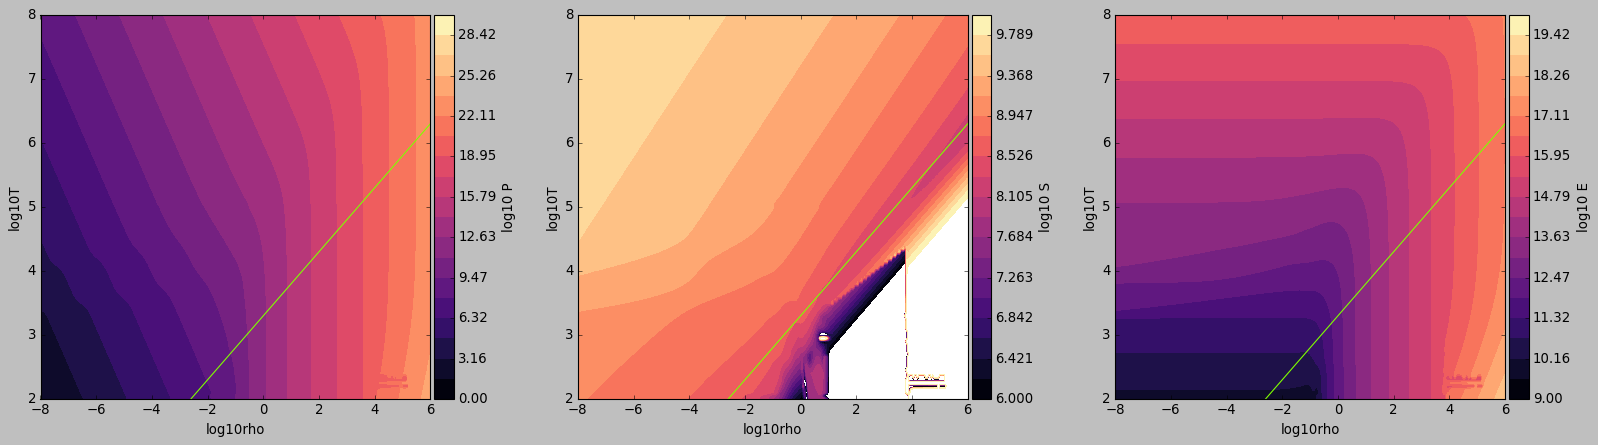

In [15]:
cd21_H.compute_atomic_number()

meos.plot_PSE(cd21_H,P=10**cd21_H.log10Pgrid,S=10**cd21_H.log10Sgrid,E=10**cd21_H.log10Egrid)


In [16]:
cd21_H.compute_partials(species='H')

MESA_cols_6to16(cd21_H,X=1.,Y=0.,calc_eta=False)

cd21_H.log10Qgrid = cd21_H.log10rhogrid - 2.*cd21_H.log10Tgrid + 12
cd21_H_QT = change_table_coordinates(cd21_H)

write_MESA_table_QT(cd21_H_QT, './meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z100x.data',version=1, X=1.0, Z=0.0)

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/71215774.py:84: RuntimeWarning: divide by zero encountered in divide
  mu_e = 1./( X*((1.-f_H2-f_H)/(2*mu_H)) + Y*((2.-2*f_He-f_Heplus)/(3.*mu_He)) )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/71215774.py:85: RuntimeWarning: divide by zero encountered in log10
  table.log_free_e = np.log10(1./mu_e)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/71215774.py:85: RuntimeWarning: invalid value encountered in log10
  table.log_free_e = np.log10(1./mu_e)


# load in He

In [17]:
infile = open("./cms19_He_interpolated_over_bad_columns.pkl","rb")
cms_He = pickle.load(infile)
infile.close()

In [18]:
cd21_He_PT = meos.CMStable("./2021_chabrier+_tables/TABLE_HE_TP_v1",units='cgs')
cd21_He = reinterpolate_mixed_table_to_rhoT(cd21_He_PT,reference_Pgrid=cms_He.log10Pgrid, X=0.0, Y=1.0)

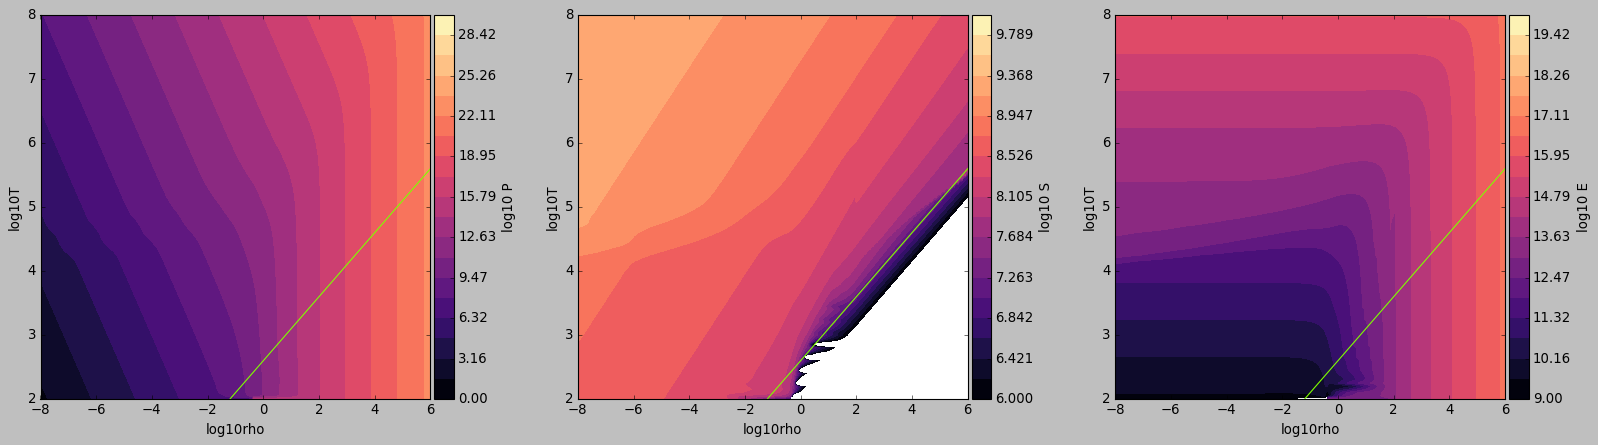

In [19]:
cd21_He.compute_atomic_number()
'''
# mask out bizarre interpolation artifacts
bad_mask = (((cd21_He.log10rhogrid < -7) & ((cd21_He.log10Tgrid > 4.3) & (cd21_He.log10Tgrid < 6.3))) | 
            ((cd21_He.log10rhogrid > 0) & ((cd21_He.log10Tgrid > 5) & (cd21_He.log10Tgrid < 7.7)))  | 
            ((cd21_He.log10rhogrid < -7.5) & (cd21_He.log10Tgrid < 3.5)))

cd21_He.log10Pgrid[bad_mask] = np.nan
cd21_He.log10Sgrid[bad_mask] = np.nan
cd21_He.log10Egrid[bad_mask] = np.nan

cd21_He.log10Pgrid = meos.fill_in_nans(cd21_He.log10Pgrid,cd21_He)
cd21_He.log10Sgrid = meos.fill_in_nans(cd21_He.log10Sgrid,cd21_He)
cd21_He.log10Egrid = meos.fill_in_nans(cd21_He.log10Egrid,cd21_He)

cd21_He.log10Ugrid = cd21_He.log10Egrid
'''
meos.plot_PSE(cd21_He,P=10**cd21_He.log10Pgrid,S=10**cd21_He.log10Sgrid,E=10**cd21_He.log10Egrid)


In [20]:
cd21_He.compute_partials(species='He')

MESA_cols_6to16(cd21_He,X=0.,Y=1.,calc_eta=False)

cd21_He.log10Qgrid = cd21_He.log10rhogrid - 2.*cd21_He.log10Tgrid + 12
cd21_He_QT = change_table_coordinates(cd21_He)

write_MESA_table_QT(cd21_He_QT, './meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z00x.data',version=1, X=0.0, Z=0.0)

# load in AQUA/SESAME blend

In [21]:
infile = open('./my_Ztables/blended_h2o.pkl','rb')
h2o = pickle.load(infile)
infile.close()

h2o.X = 0.
h2o.Y = 0.
h2o.log10Egrid = h2o.log10Ugrid

h2o.compute_atomic_number()
h2o.compute_partials(species='Z')

MESA_cols_6to16(h2o,X=0.,Y=0.,mu_Z=18.015)

h2o.log10Qgrid = h2o.log10rhogrid - 2.*h2o.log10Tgrid + 12

h2o_QT = change_table_coordinates(h2o,extrapolation_row_idxs=None)

write_MESA_table_QT(h2o_QT, './meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_100z00x.data',version=1, X=0.0, Z=1.0)

In [22]:
# interpolate to (P,T)
h2o_PT = meos.interpolated_PTtable(h2o,desired_Parr = np.arange(-13.0,23.04,0.05),rhobounds=(-8,6),mask_unphysical=False,extrapolate_below_T=2.89)

/Users/emily/Documents/astro/giant_planets/MESA_EoS/EOSutils/EOSutils/EOSutils.py:1558: UserWarning: The following kwargs were not used by contour: 'shading'
  cs = axes[i,j].contourf(xs[i*nCol + j], ys[i*nCol + j], zs[i*nCol + j], shading='nearest', cmap=cmap[i*nCol + j], levels=np.linspace(zlims[i*nCol+j][0],zlims[i*nCol+j][1],levels[i*nCol+j]))


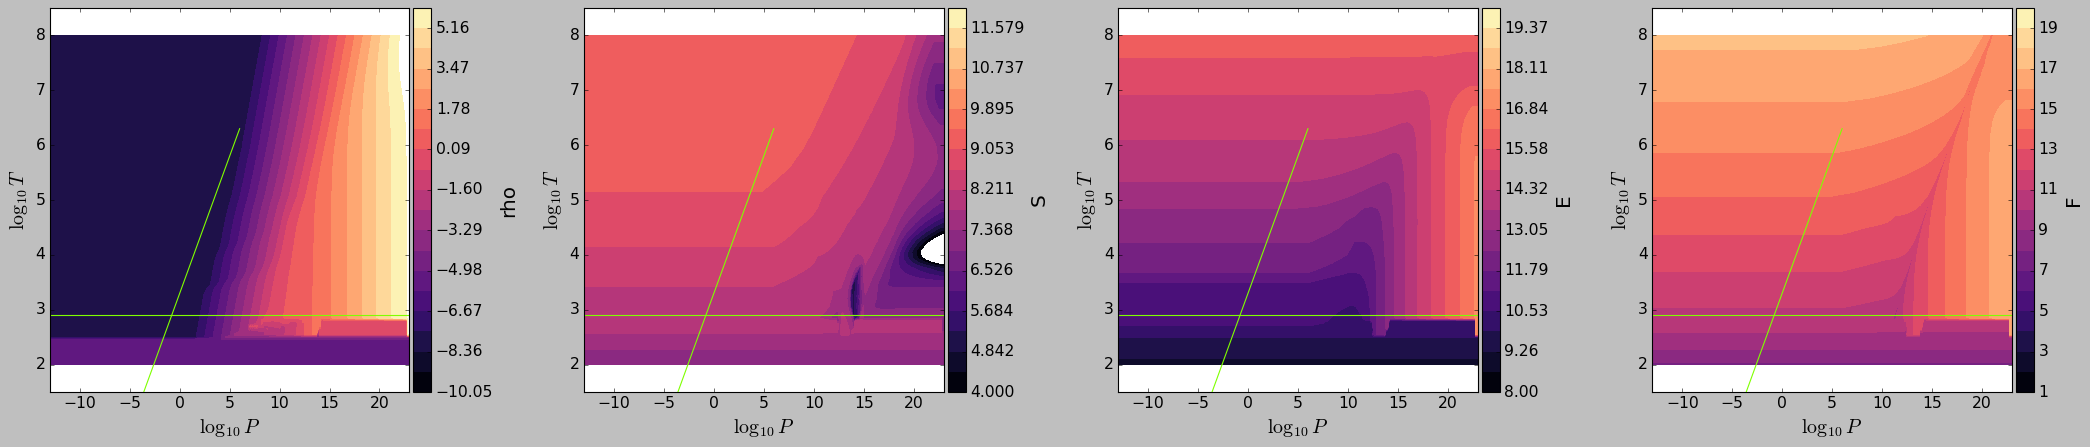

In [23]:
unphys_x = np.linspace(-8,6,50)
unphys_y = 3.3 + (1./2.)*np.linspace(-8,6,50) + np.log10(1) - (5./3)*np.log10(1)

meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=h2o_PT.log10Pgrid,
                                ys=h2o_PT.log10Tgrid,
                                zs=[h2o_PT.log10rhogrid,h2o_PT.log10Sgrid,h2o_PT.log10Egrid,np.log10(np.abs(10**h2o_PT.log10Egrid - ((10**h2o_PT.log10Tgrid) * (10**h2o_PT.log10Sgrid))))],
                                xlims=(-13,23),
                                ylims=(1.5,8.5),
                                zlims=[(-10.05,6),(4,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}P$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['rho','S','E','F'],
                                cmap='magma', vlines=None, hlines=[2.9], otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)
                
        

In [24]:
print(cd21_H_PT.log10Egrid[~np.isfinite(cd21_H_PT.log10Sgrid)])
print(cd21_He_PT.log10Egrid[~np.isfinite(cd21_He_PT.log10Sgrid)])
print(h2o_PT.log10Egrid[~np.isfinite(h2o_PT.log10Sgrid)])

[]
[]
[]


# XYZ mixture tables, CD21 + AQUA/SESAME

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z00x.data
0.0 1.0 0.0


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/1063687161.py:60: RuntimeWarning: overflow encountered in scalar power
  S_H = 10**H_PTtable.log10Sgrid[i,j]
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/1063687161.py:63: RuntimeWarning: overflow encountered in scalar power
  U_H = 10**H_PTtable.log10Egrid[i,j]
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/1063687161.py:107: RuntimeWarning: invalid value encountered in scalar multiply
  mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + S_id_mix_XYonly)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/1063687161.py:108: RuntimeWarning: invalid value encountered in scalar multiply
  mixed_log10Egrid[i,j] = np.log10(X*U_H + Y*U_He )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/1063687161.py:64: RuntimeWarning: overflow encountered in scalar power
  U_He = 10**He_PTtable.log10Egrid[i,j]
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/

0.9891200304031372


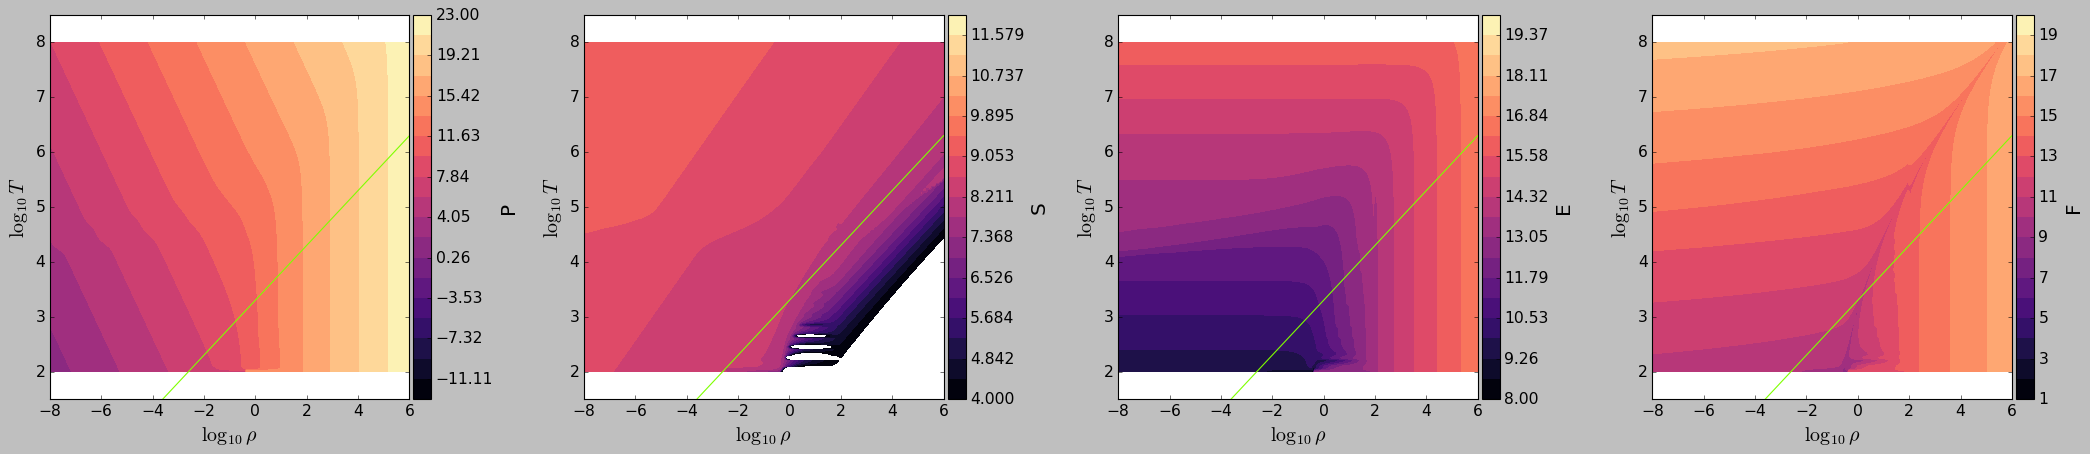

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_10z00x.data
0.0 0.9 0.1


/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/1063687161.py:116: RuntimeWarning: invalid value encountered in scalar multiply
  mixed_log10Sgrid[i,j] = np.log10(X*S_H + Y*S_He + Z*S_Z + S_id_mix_XYZ)
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/1063687161.py:117: RuntimeWarning: invalid value encountered in scalar multiply
  mixed_log10Egrid[i,j] = np.log10(X*U_H + Y*U_He + Z*U_Z)


[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.263768815994263


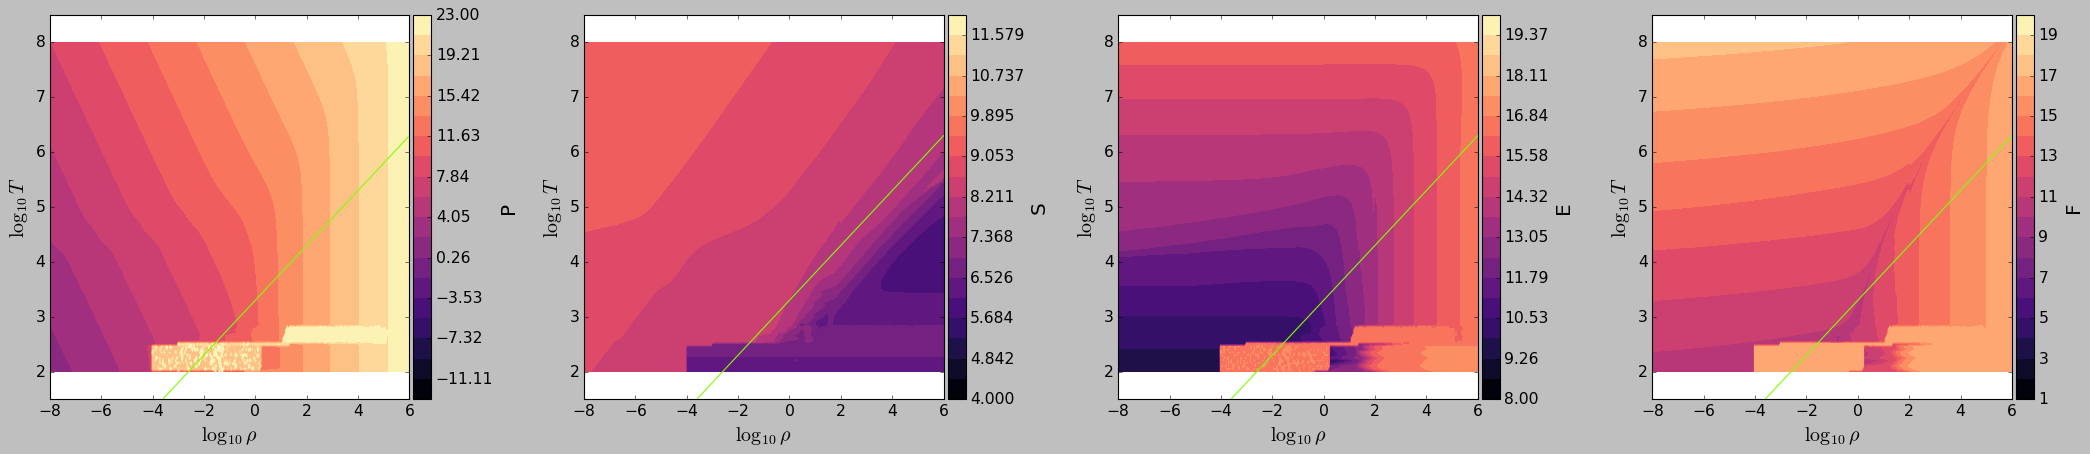

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_20z00x.data
0.0 0.8 0.2
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.5662454009056095


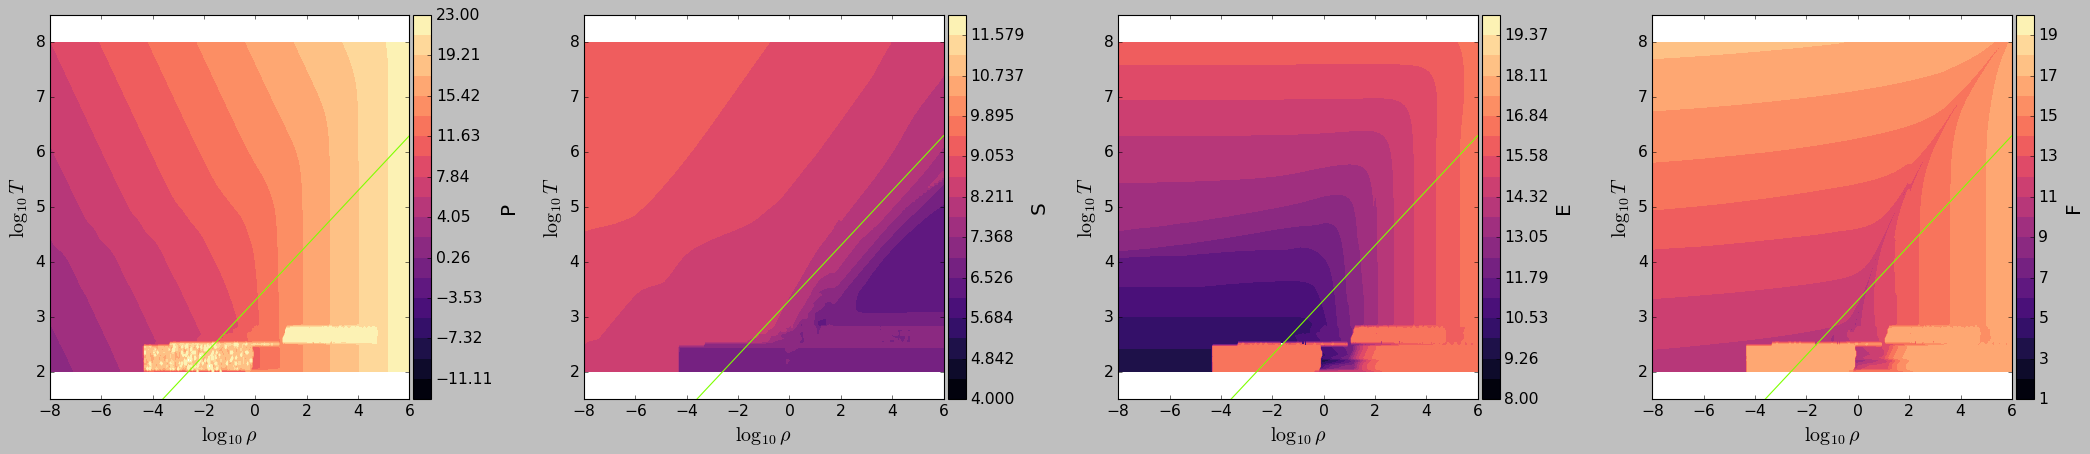

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_30z00x.data
0.0 0.7 0.30000000000000004
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
8.171245316664377


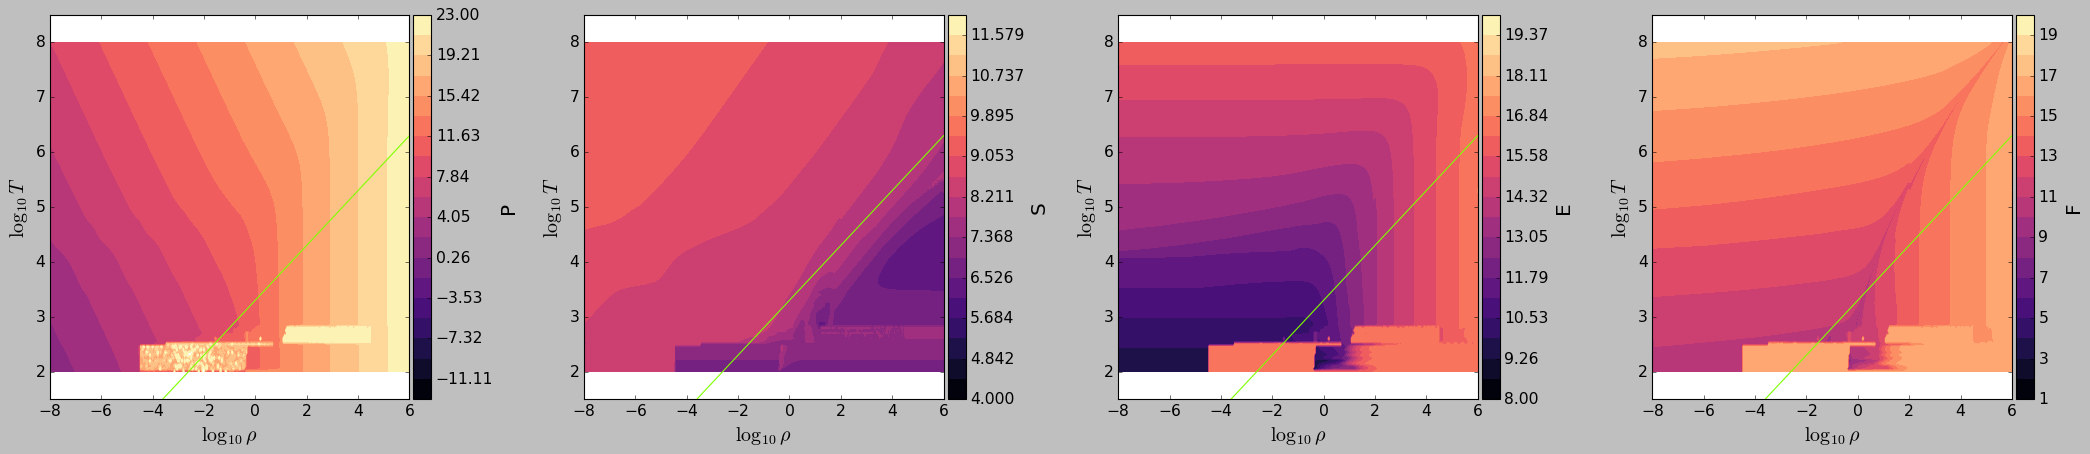

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_40z00x.data
0.0 0.6 0.4
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.9706385135650635


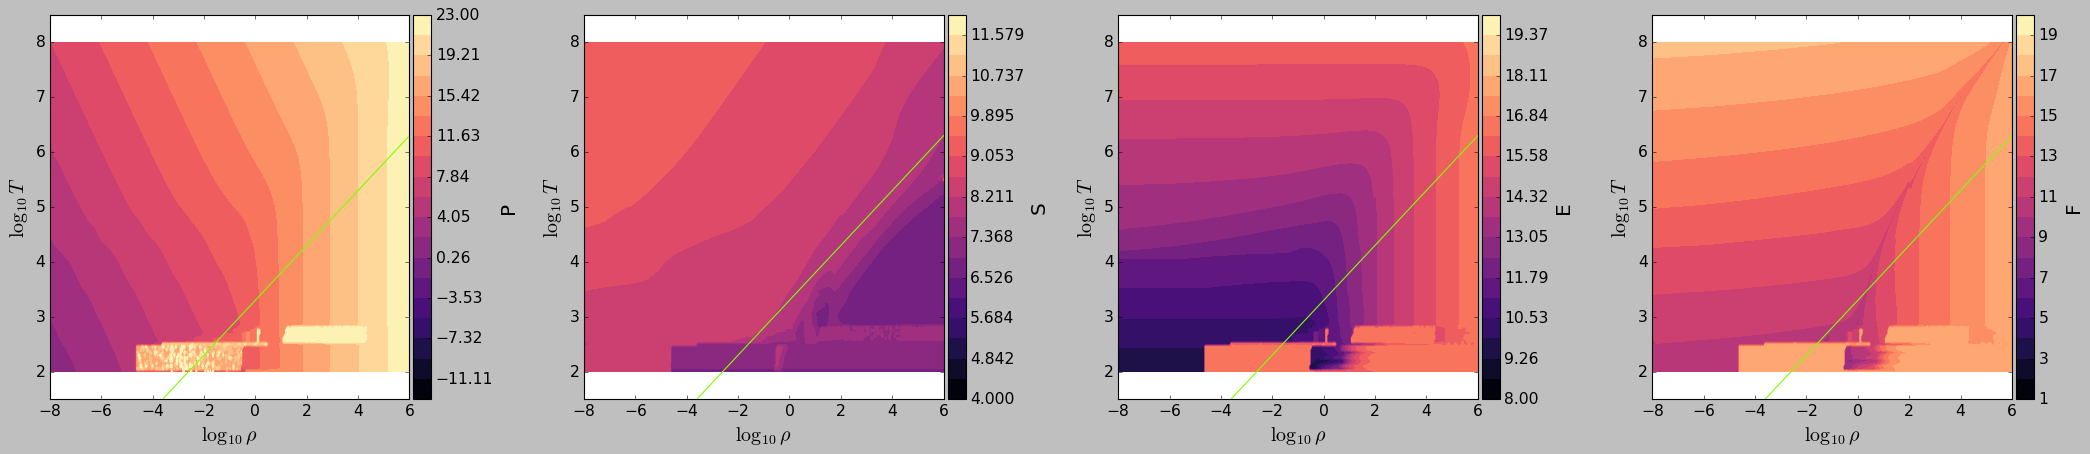

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_50z00x.data
0.0 0.5 0.5
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
8.561510880788168


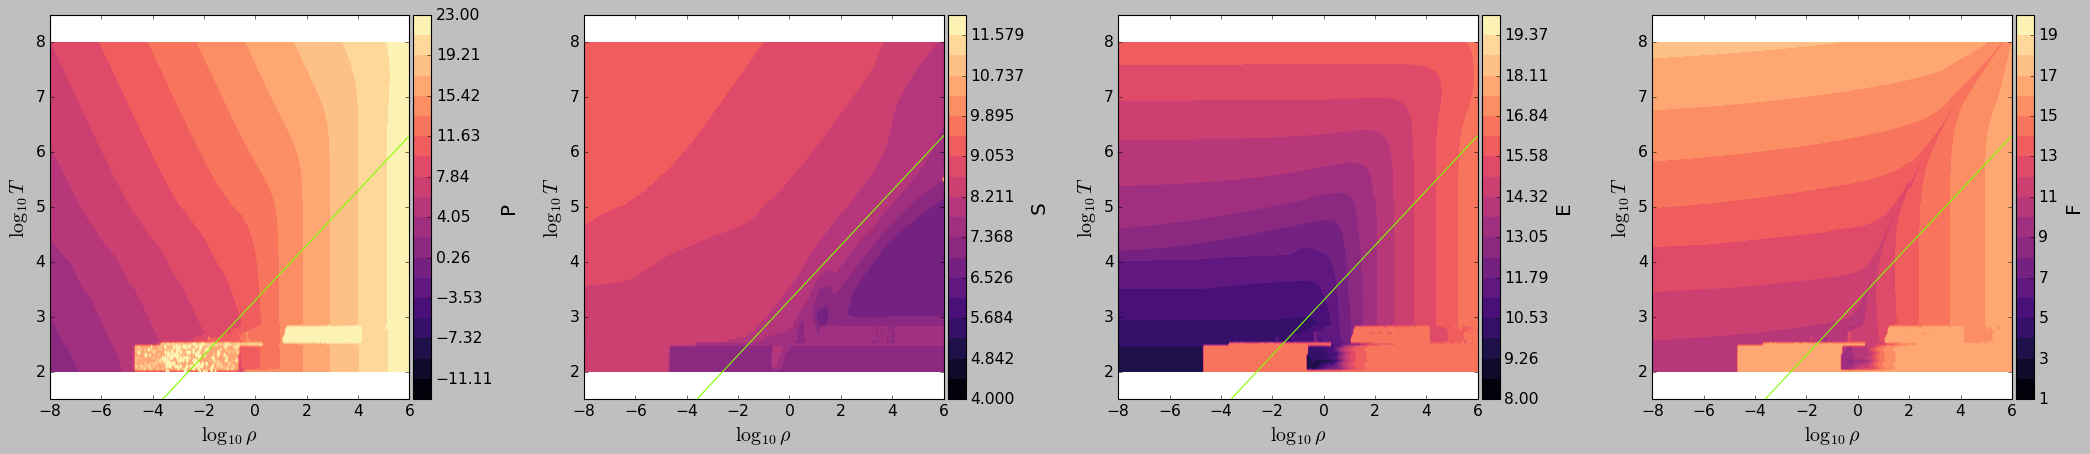

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_60z00x.data
0.0 0.3999999999999999 0.6000000000000001
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
8.43430726925532


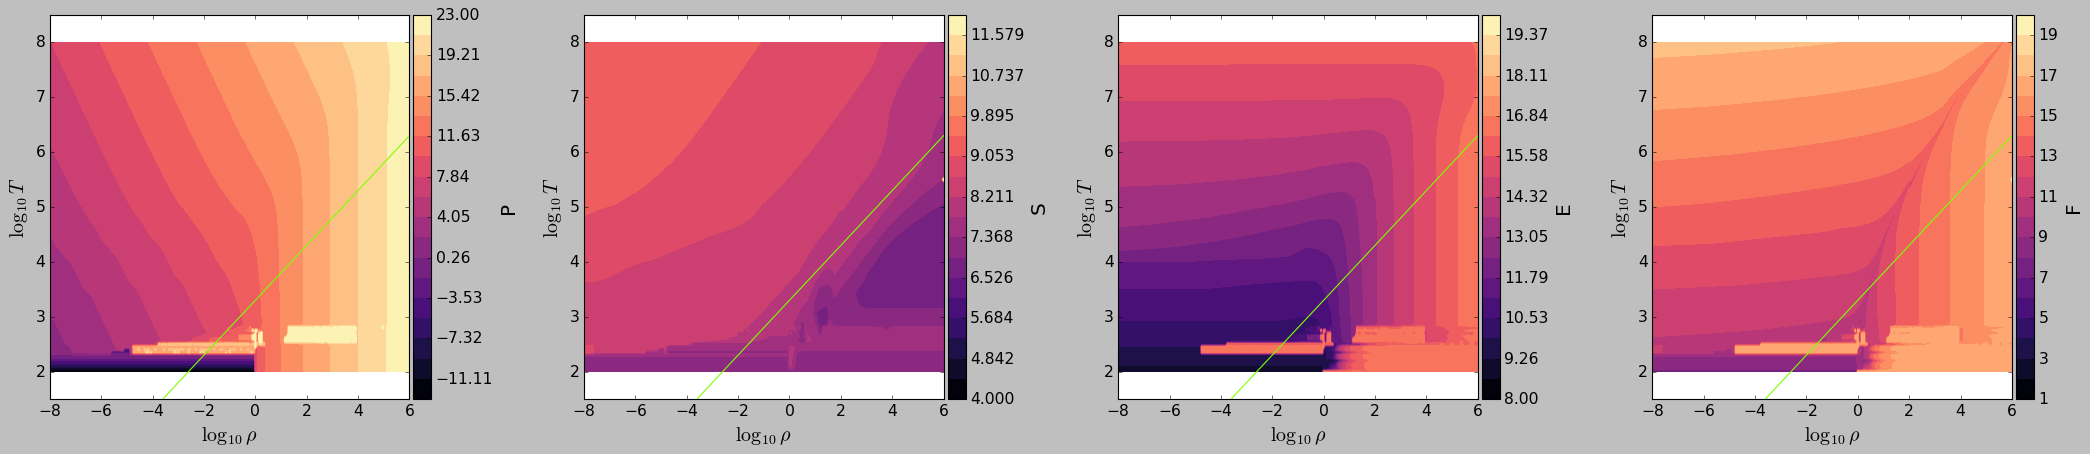

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_70z00x.data
0.0 0.29999999999999993 0.7000000000000001
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.95340435107549


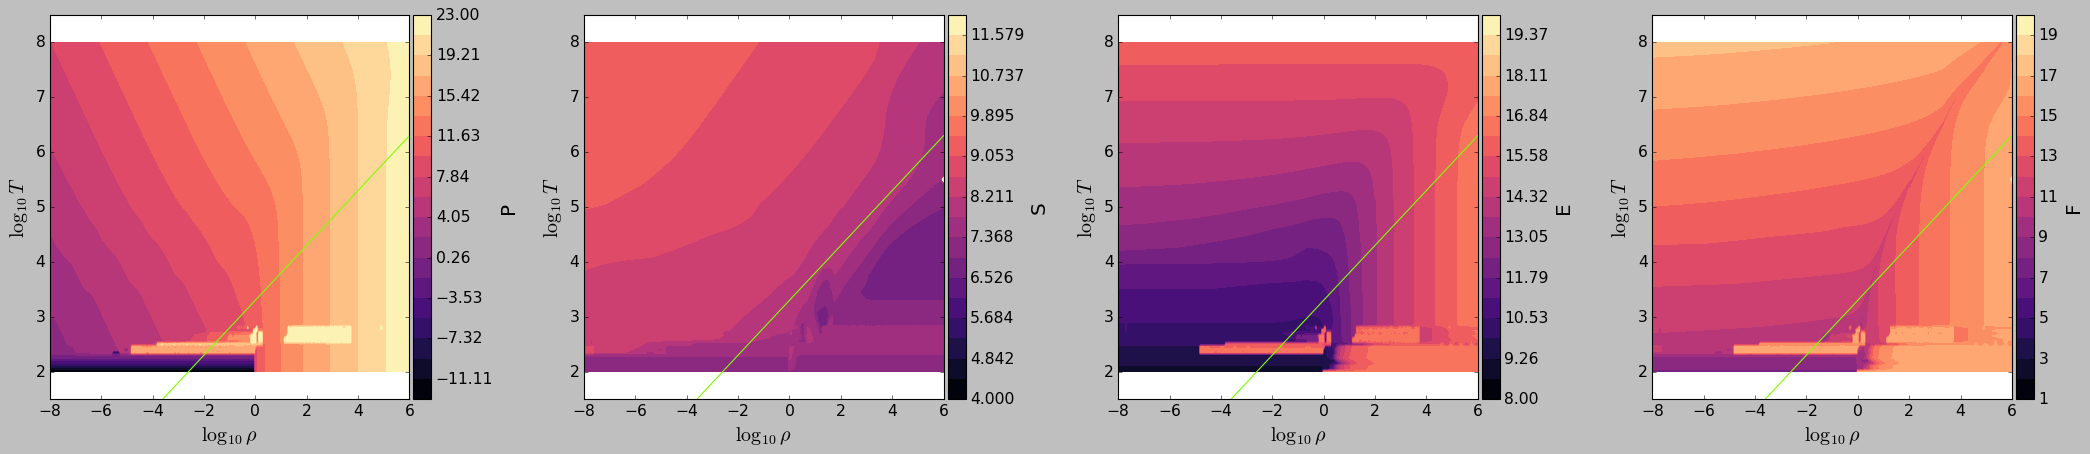

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_80z00x.data
0.0 0.19999999999999996 0.8
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.653380048274994


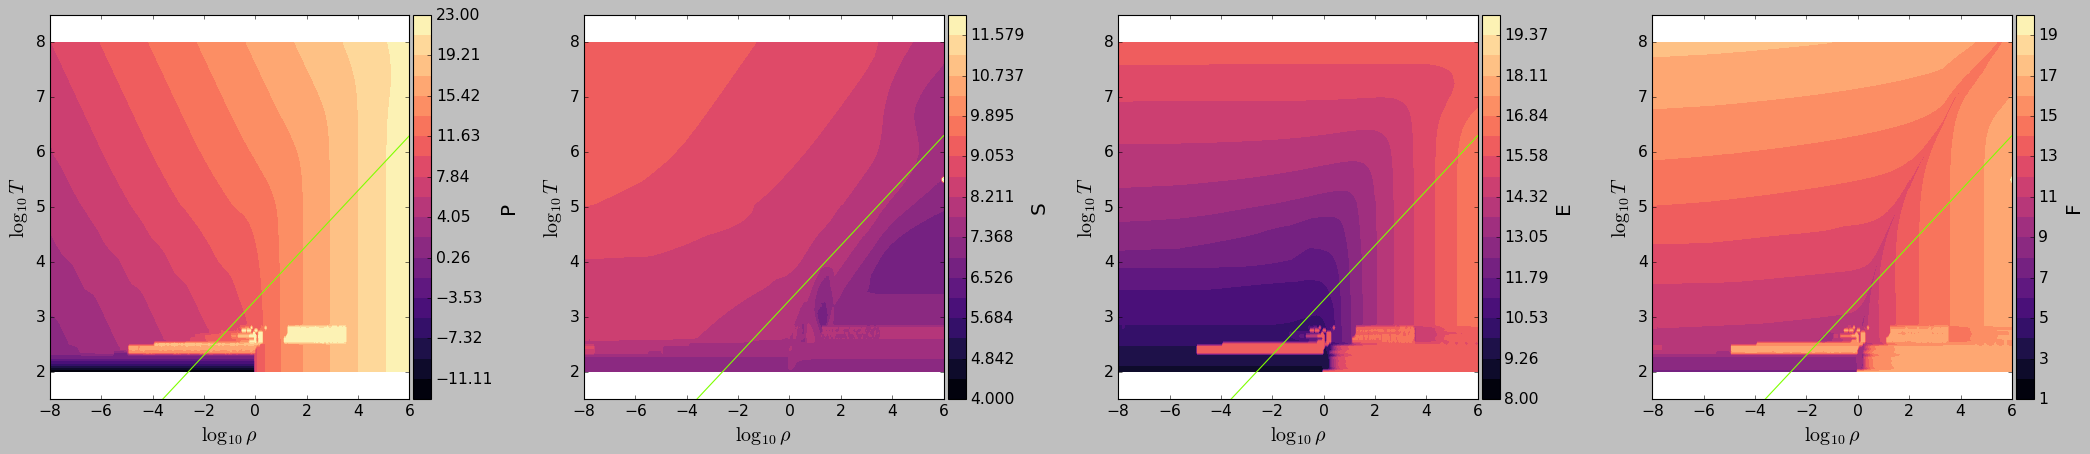

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_90z00x.data
0.0 0.09999999999999998 0.9
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
8.526195951302846


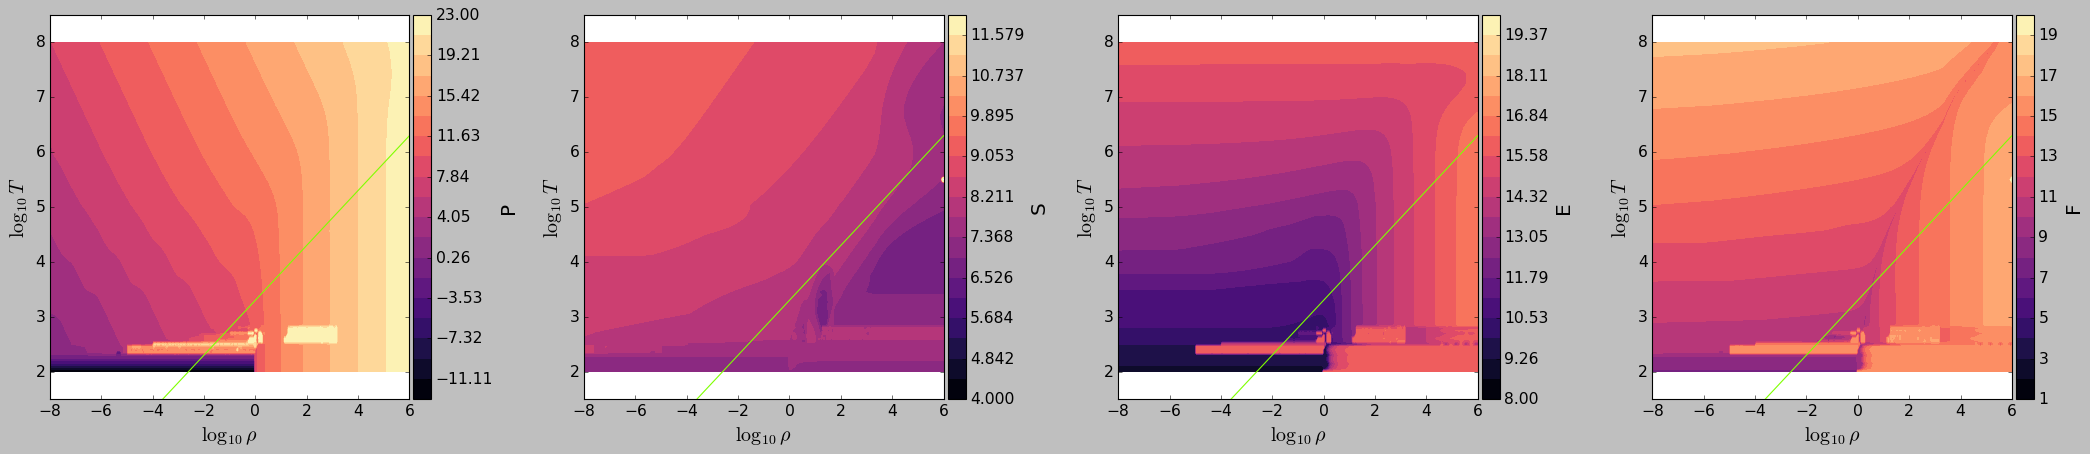

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z10x.data
0.1 0.9 0.0
5.482400699456533


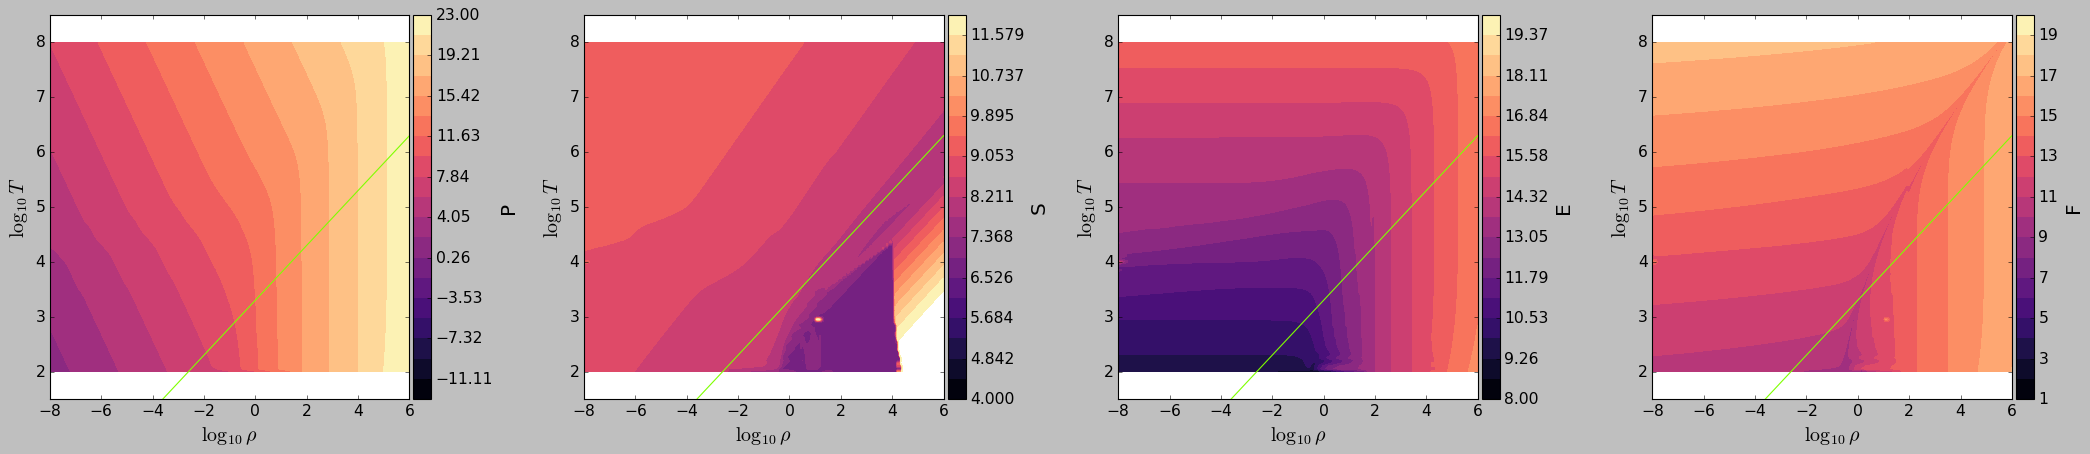

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_10z10x.data
0.1 0.8 0.1
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
11.11715435187022


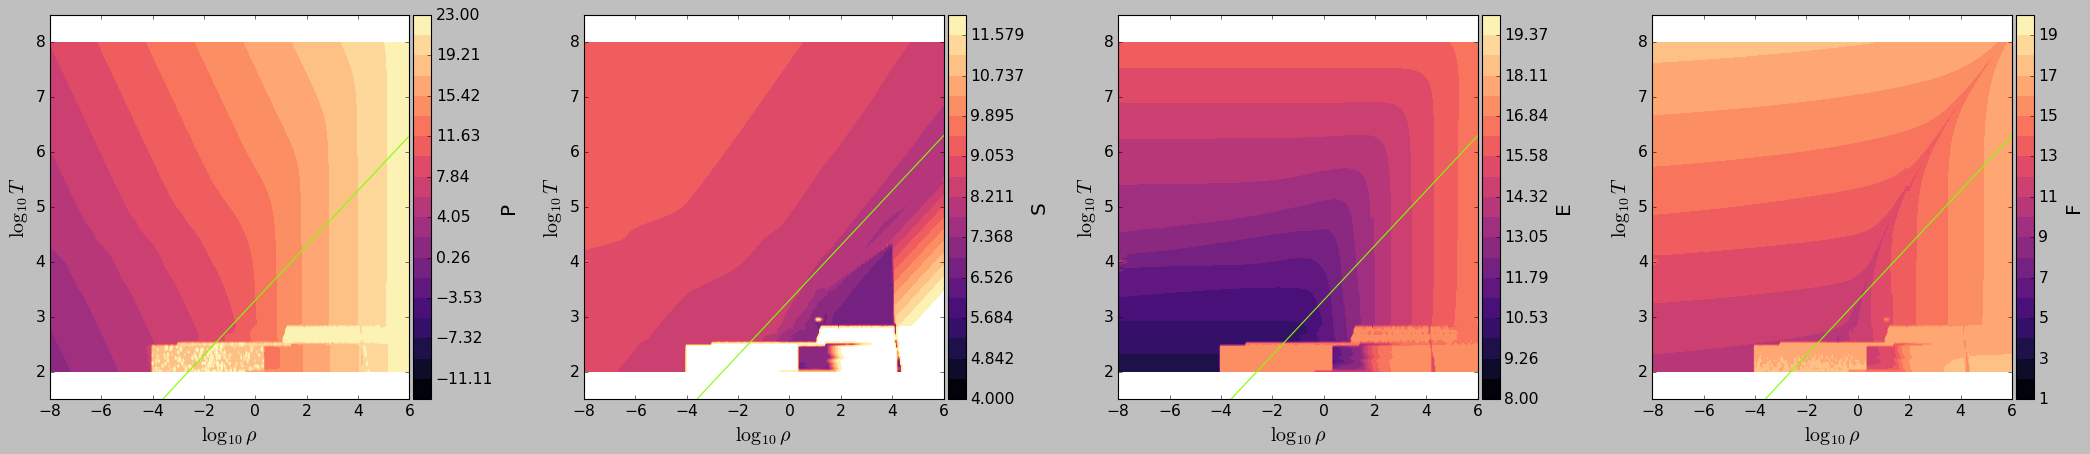

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_20z10x.data
0.1 0.7 0.2
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
8.114406478404998


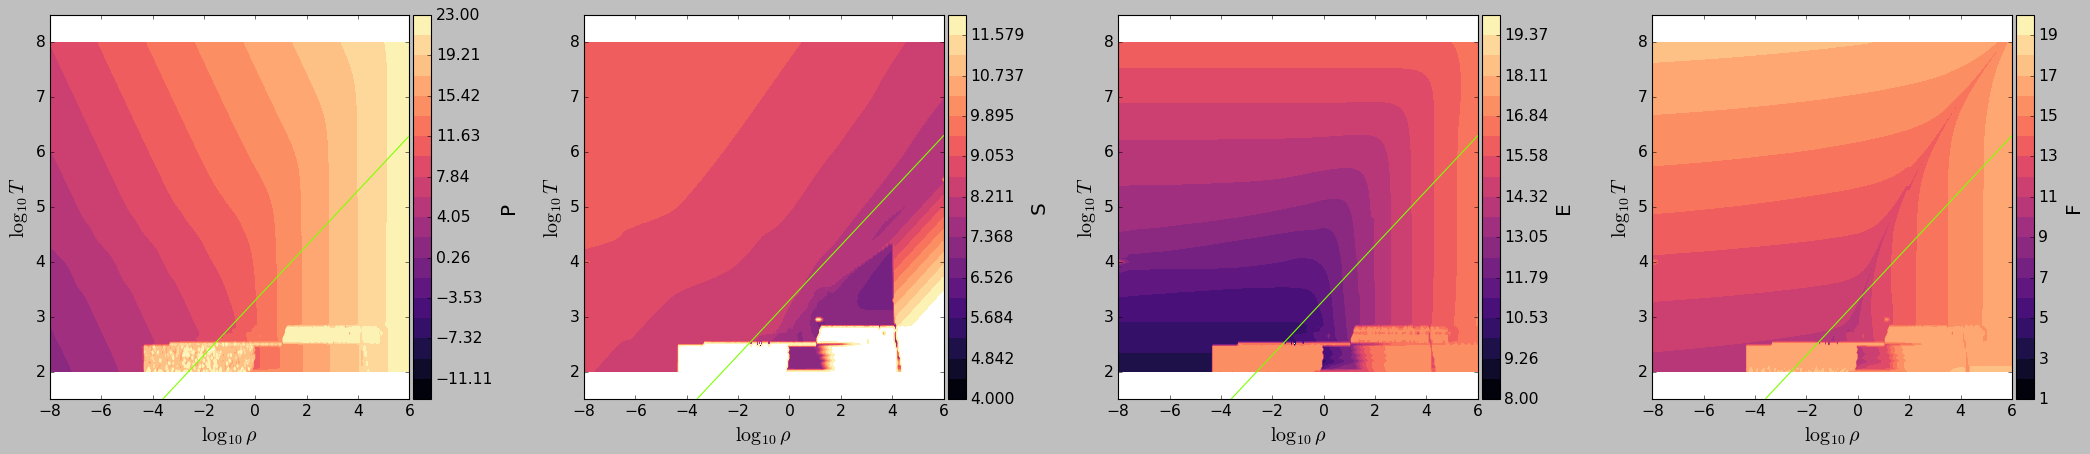

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_30z10x.data
0.1 0.6 0.30000000000000004
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
10.589914468924205


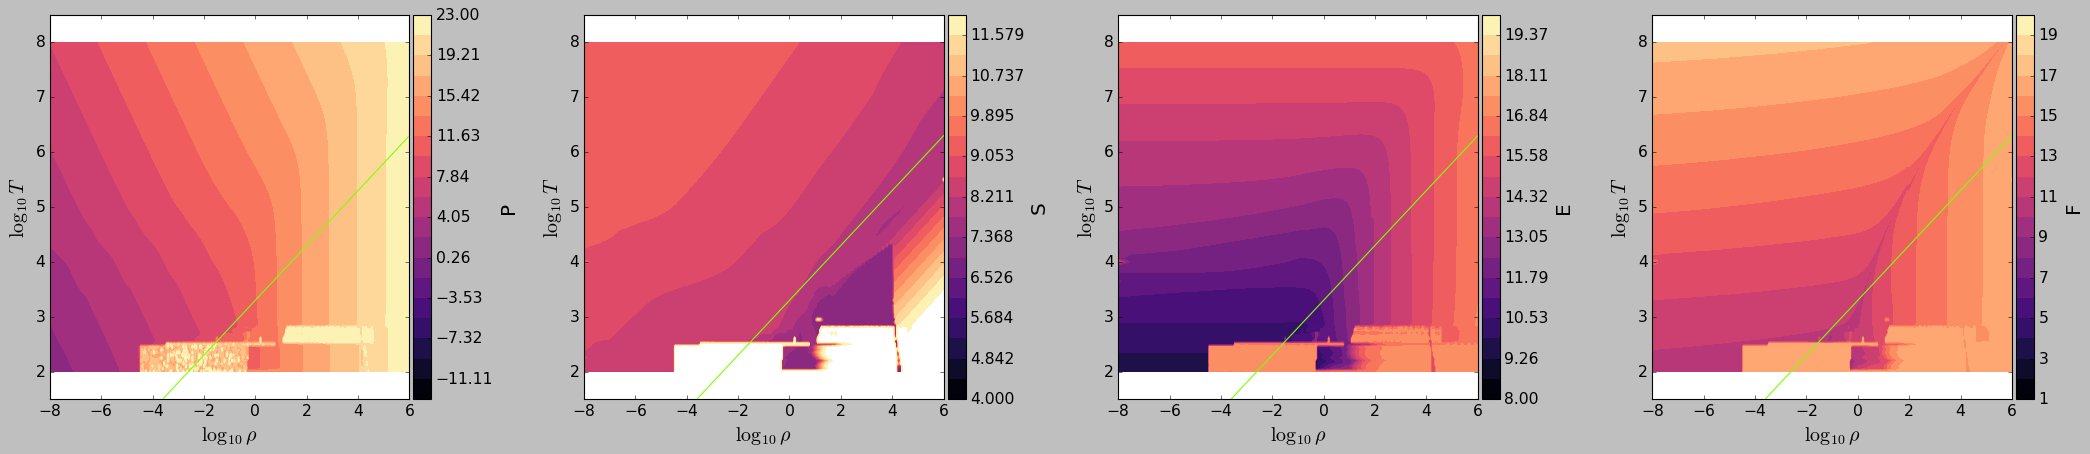

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_40z10x.data
0.1 0.5 0.4
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
8.413575696945191


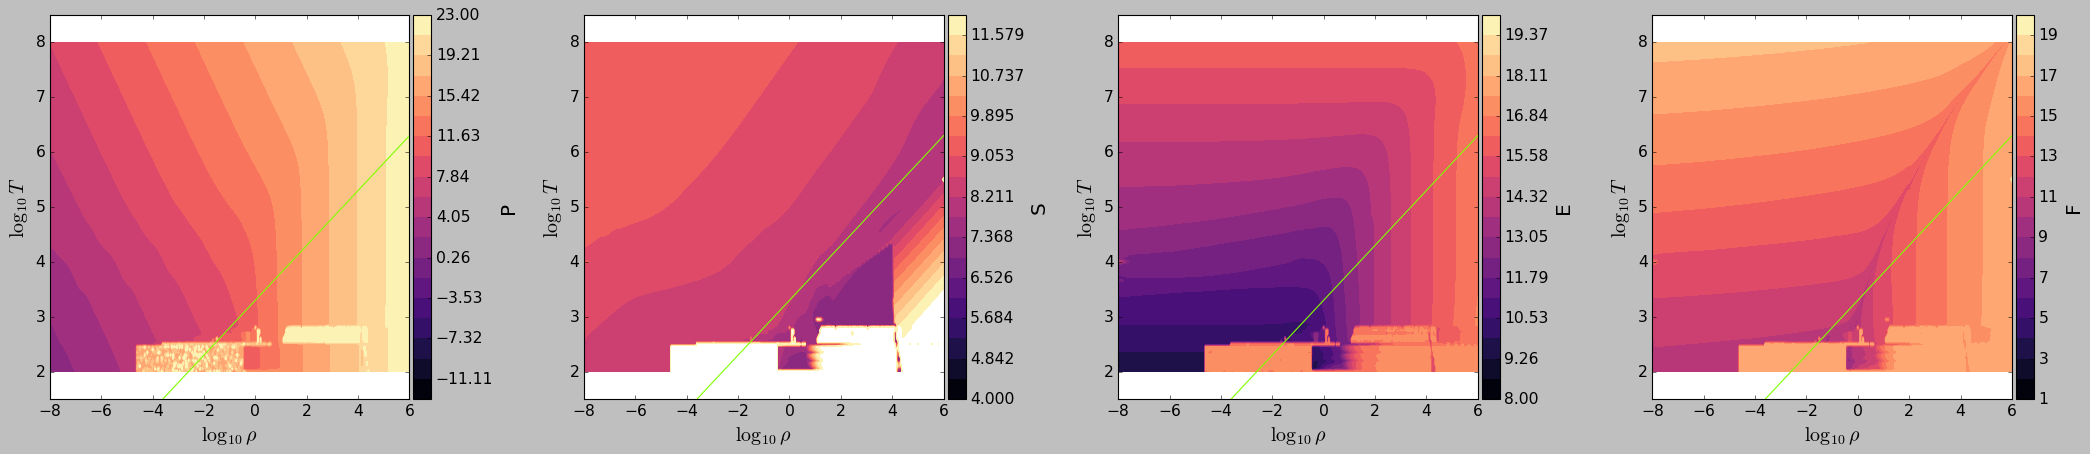

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_50z10x.data
0.1 0.4 0.5
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
9.222800584634145


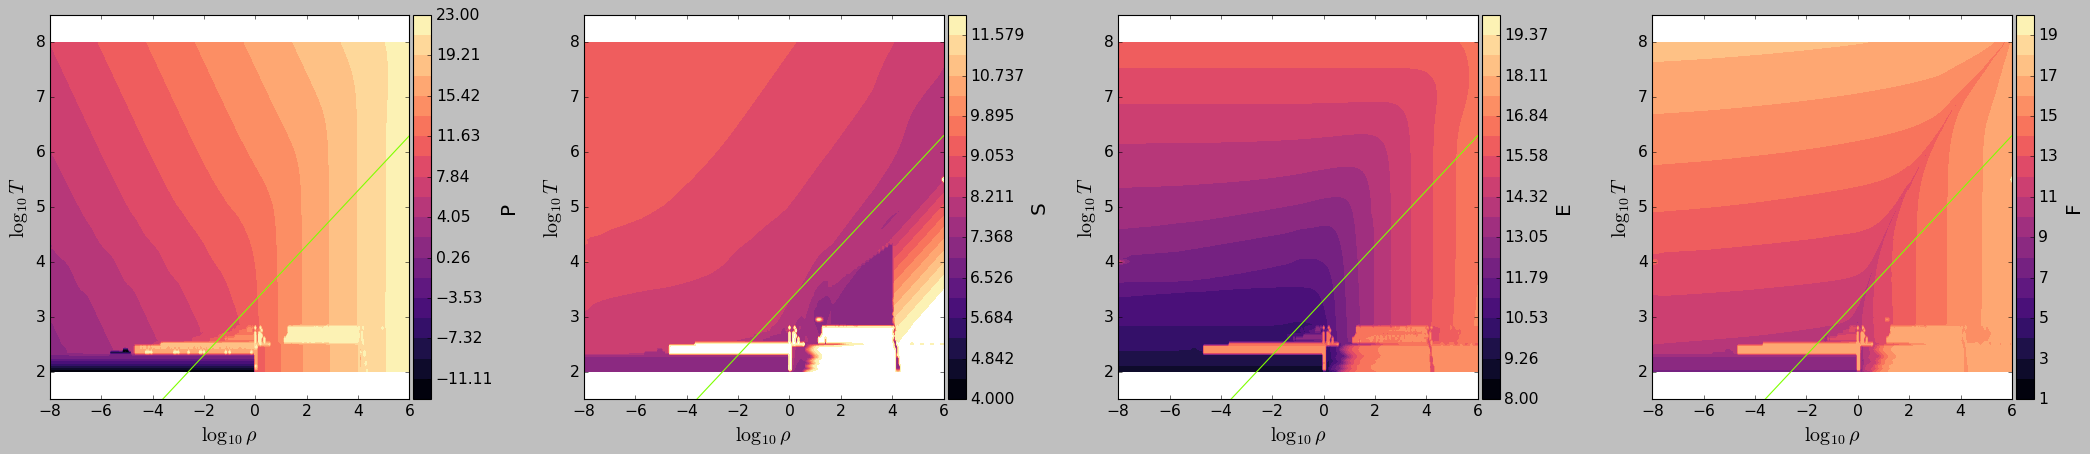

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_60z10x.data
0.1 0.29999999999999993 0.6000000000000001
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.232236667474111


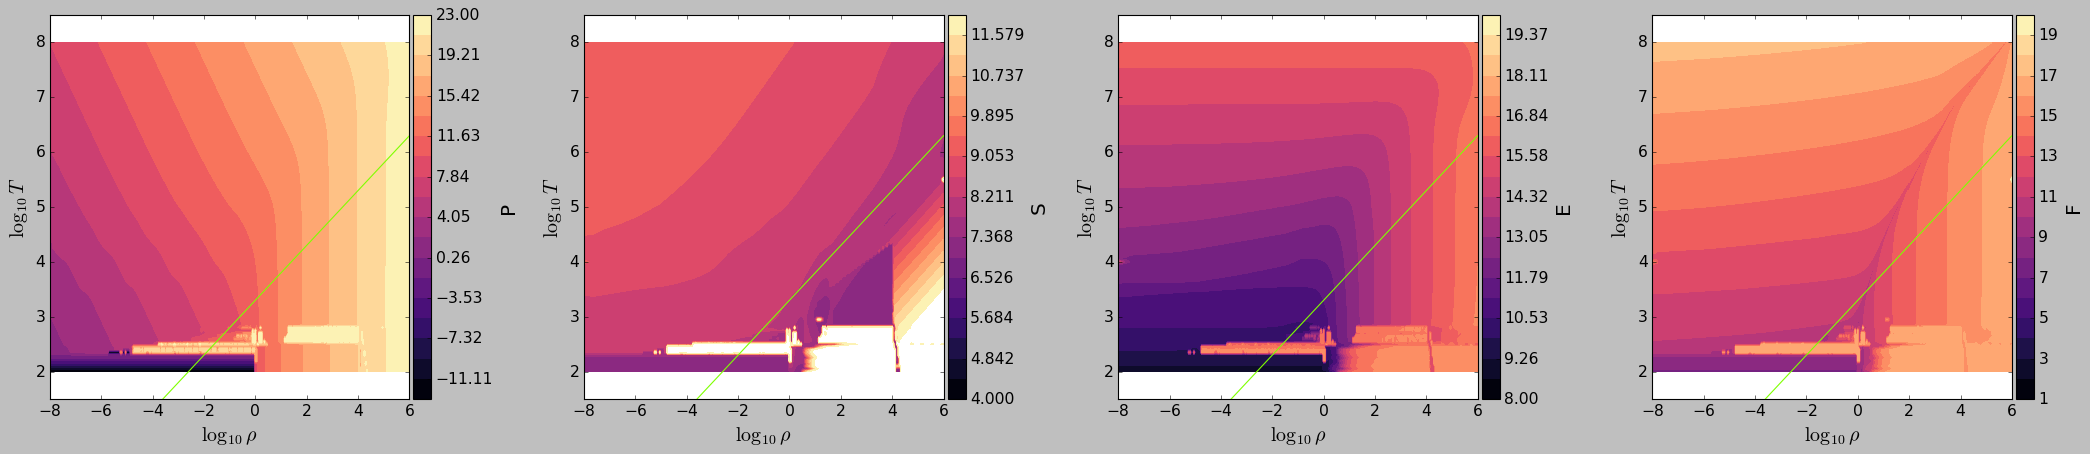

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_70z10x.data
0.1 0.19999999999999996 0.7000000000000001
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
9.311618236700694


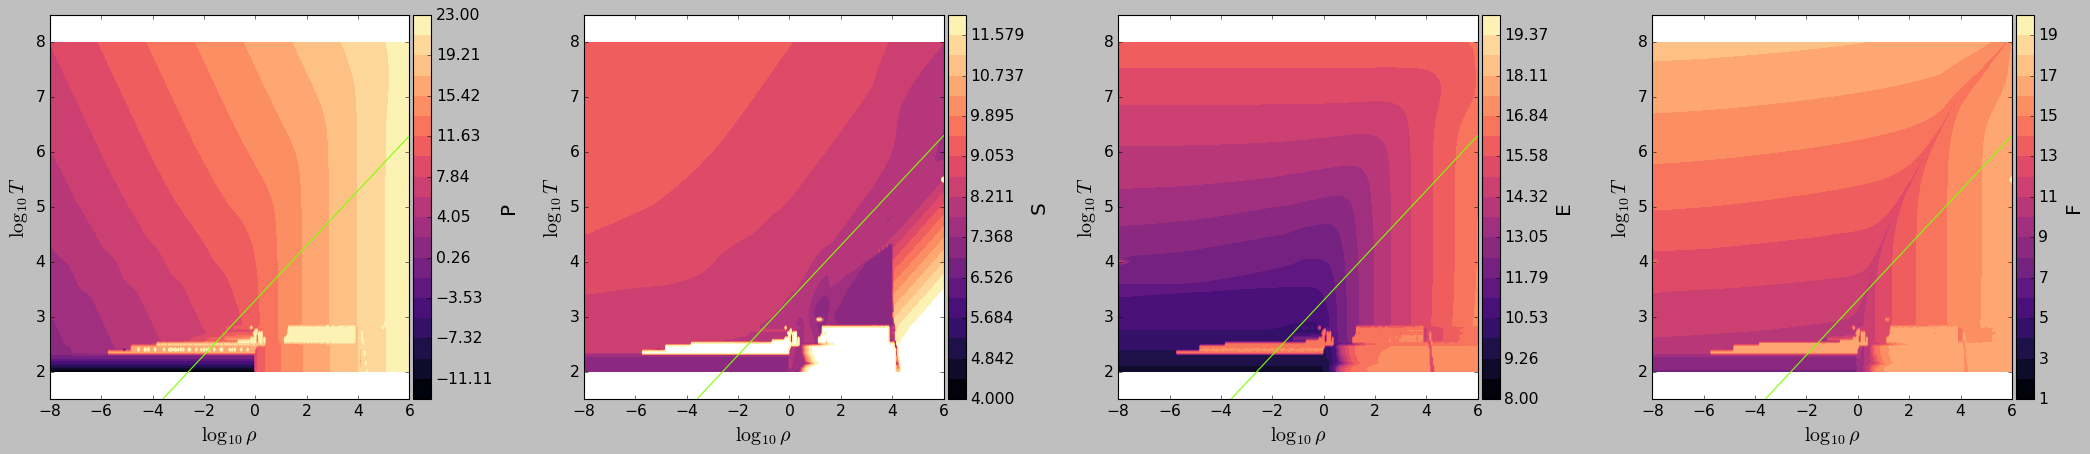

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_80z10x.data
0.1 0.09999999999999998 0.8
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
6.624838682015737


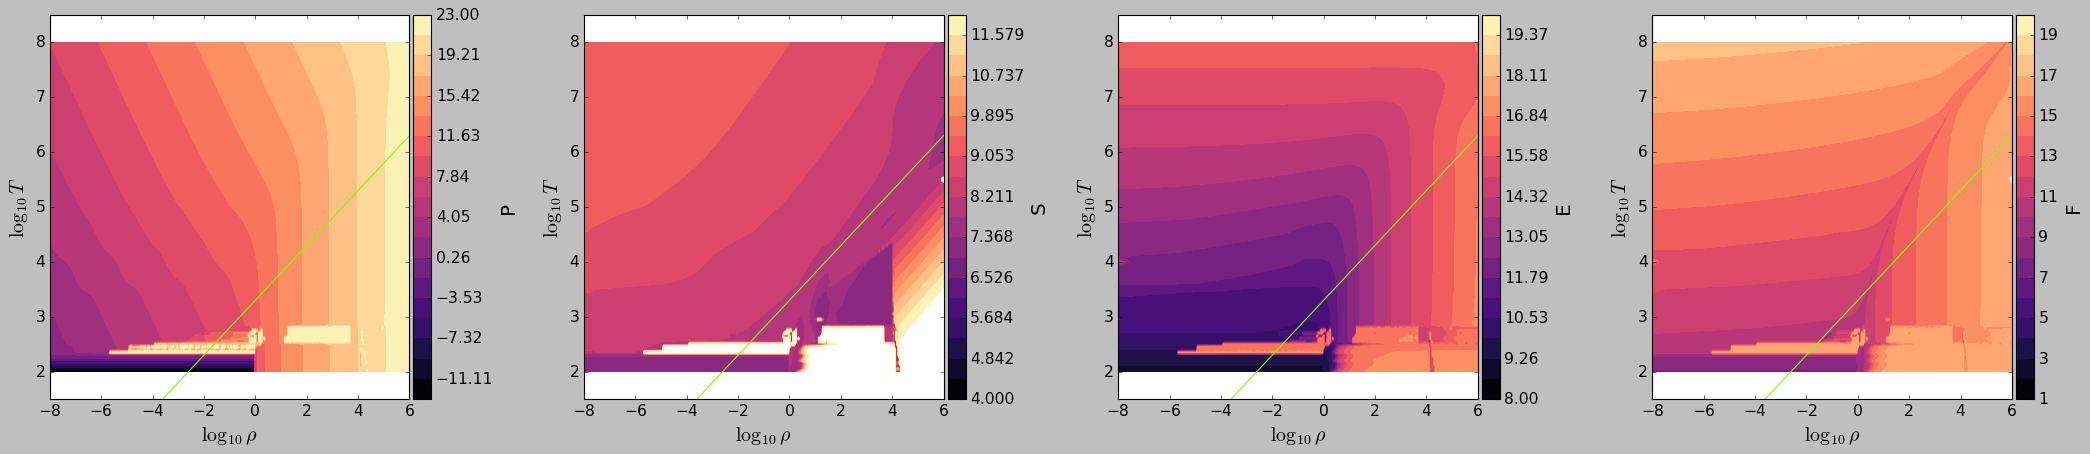

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_90z10x.data
0.1 0.0 0.9
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
10.120839019616445


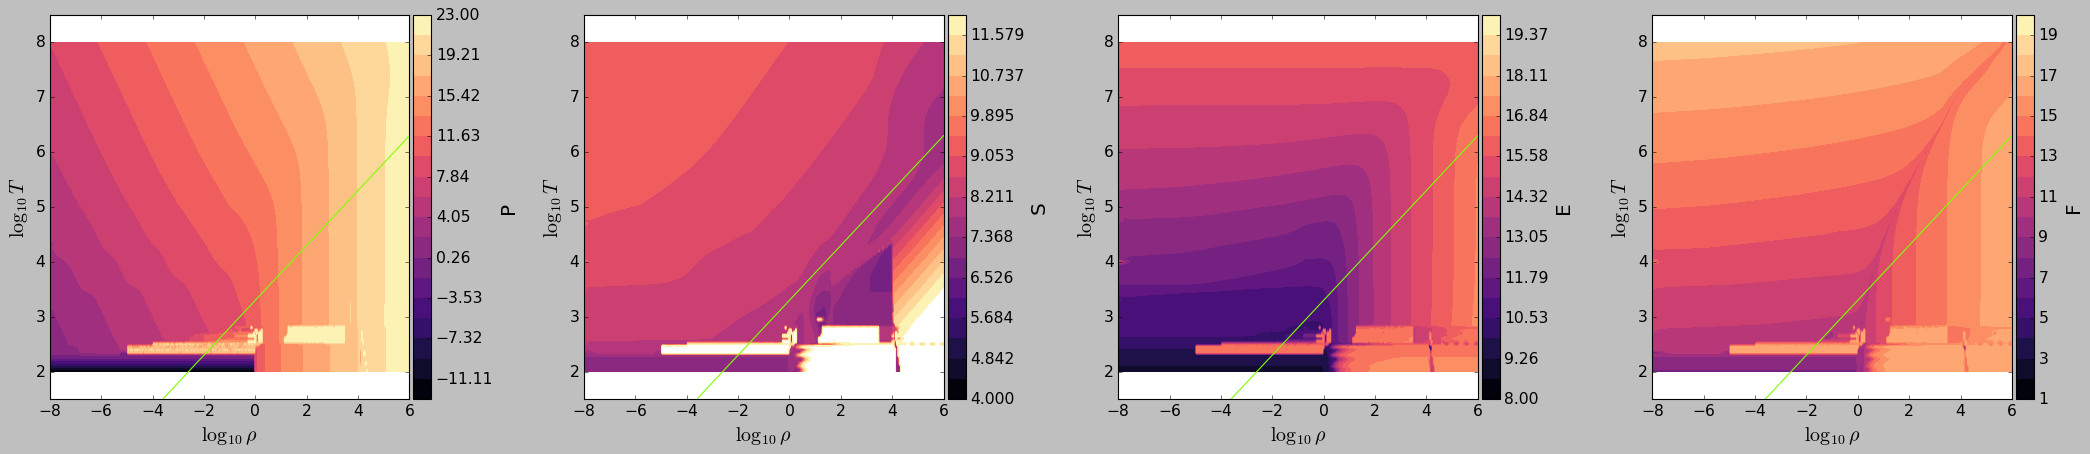

/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/71215774.py:21: RuntimeWarning: divide by zero encountered in divide
  dlrho_dlT_P = -1. * table.chiT/table.chiRho
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/71215774.py:22: RuntimeWarning: divide by zero encountered in divide
  dlrho_dlP_T = 1./table.chiRho
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/71215774.py:24: RuntimeWarning: divide by zero encountered in divide
  dlS_dlT_P = table.dlS_dlT_rho - (table.dlS_dlrho_T * (table.chiT/table.chiRho))
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/71215774.py:25: RuntimeWarning: divide by zero encountered in divide
  dlS_dlP_T = table.dlS_dlrho_T/table.chiRho
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000gn/T/ipykernel_11881/71215774.py:84: RuntimeWarning: divide by zero encountered in divide
  mu_e = 1./( X*((1.-f_H2-f_H)/(2*mu_H)) + Y*((2.-2*f_He-f_Heplus)/(3.*mu_He)) )
/var/folders/vr/5jyx18rn3vb6ccm0db12sp8w0000

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z20x.data
0.2 0.8 0.0
5.70909055074056


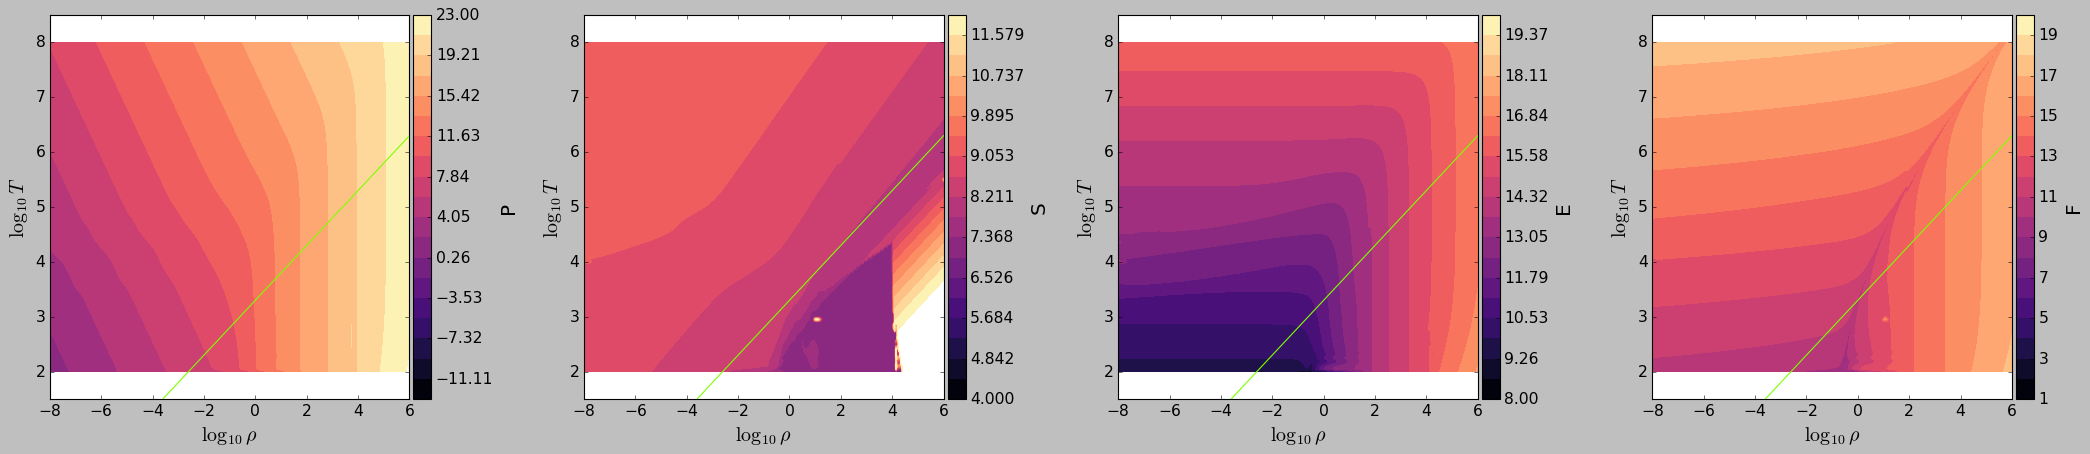

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_10z20x.data
0.2 0.7 0.1
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
11.631462816397349


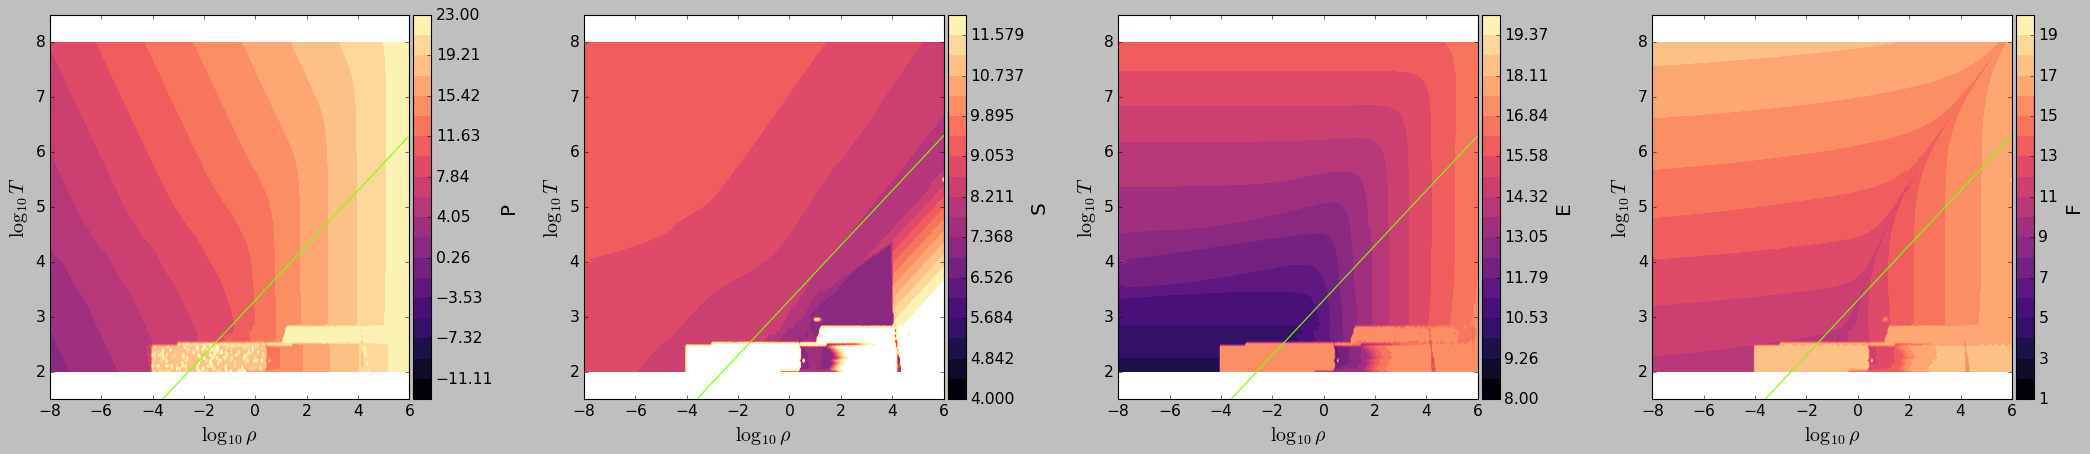

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_20z20x.data
0.2 0.6 0.2
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
8.818121949831644


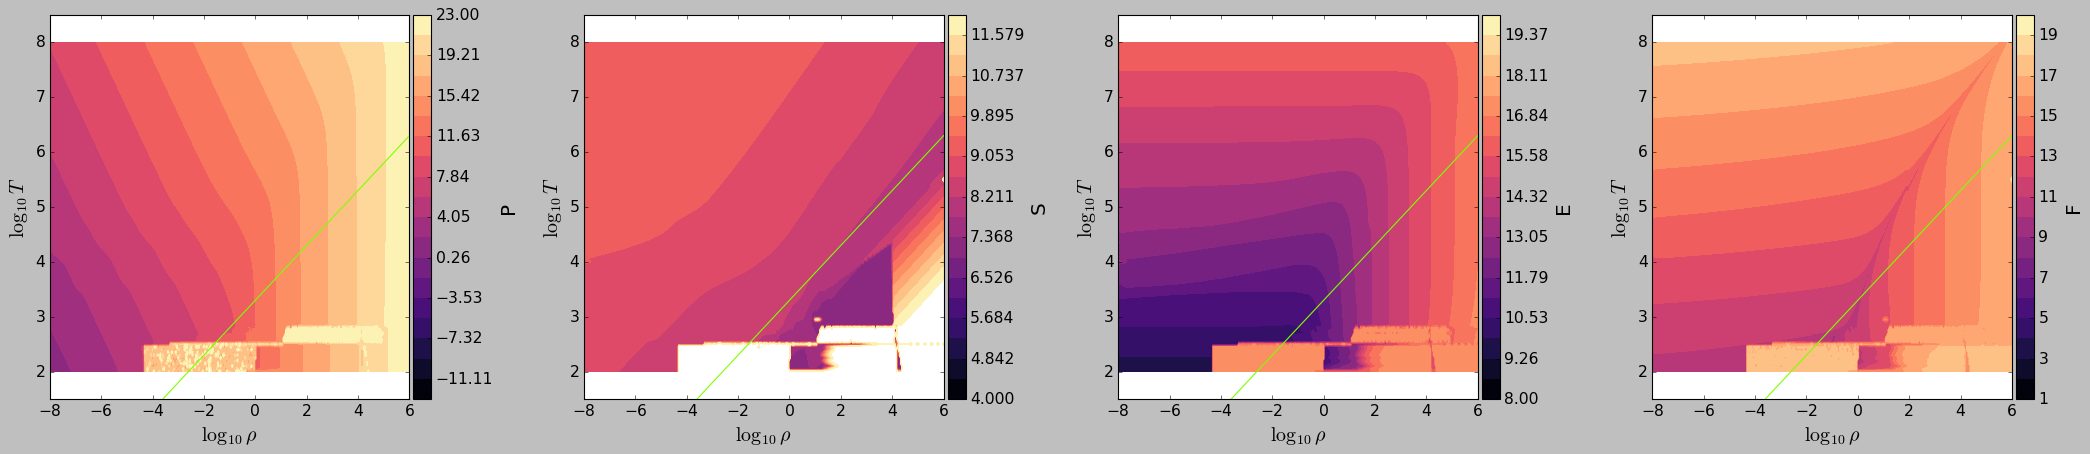

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_30z20x.data
0.2 0.5 0.30000000000000004
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
11.47385110060374


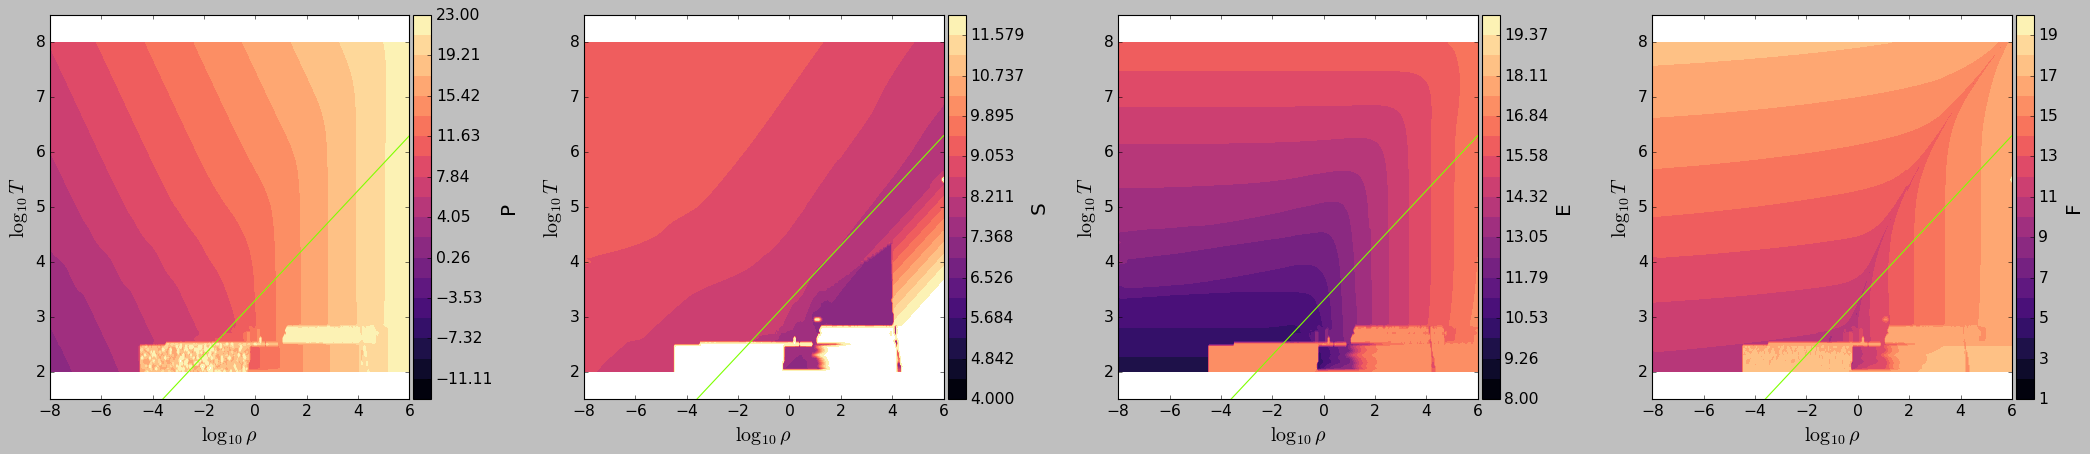

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_40z20x.data
0.2 0.3999999999999999 0.4
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.4238460501035055


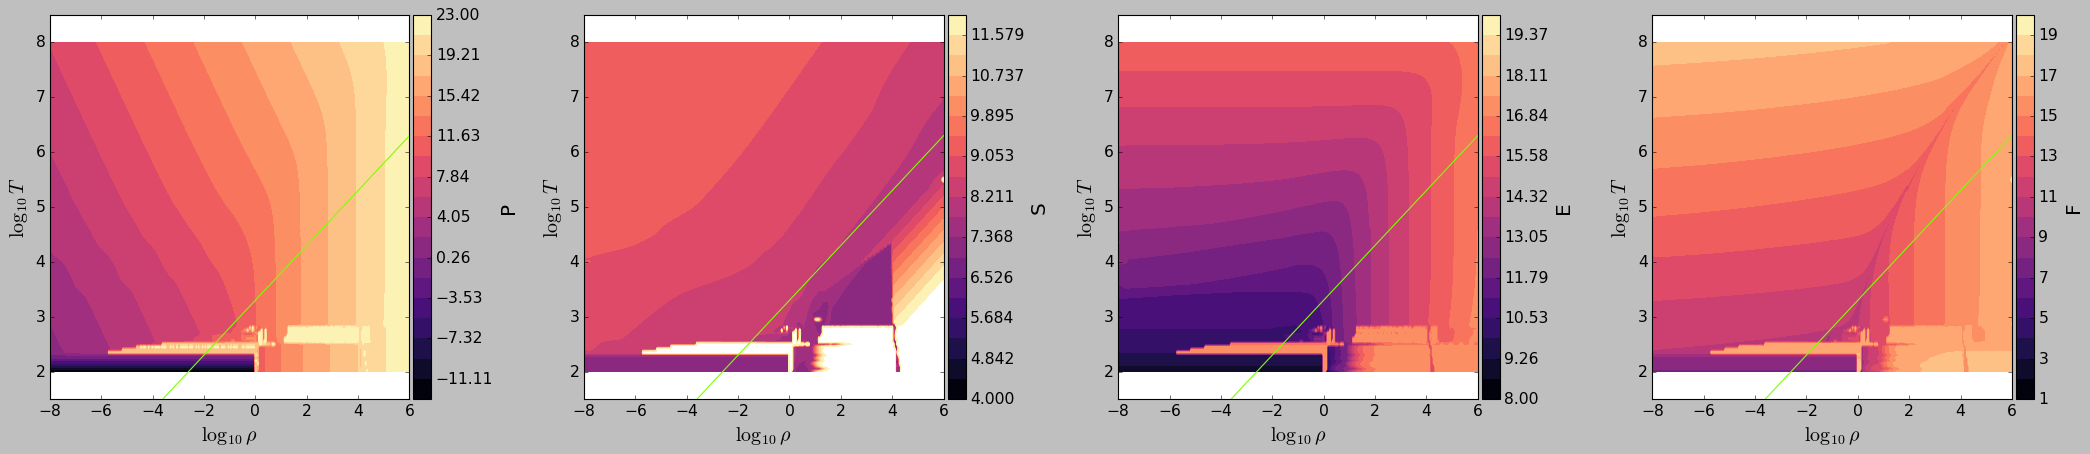

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_50z20x.data
0.2 0.30000000000000004 0.5
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
10.235807168483735


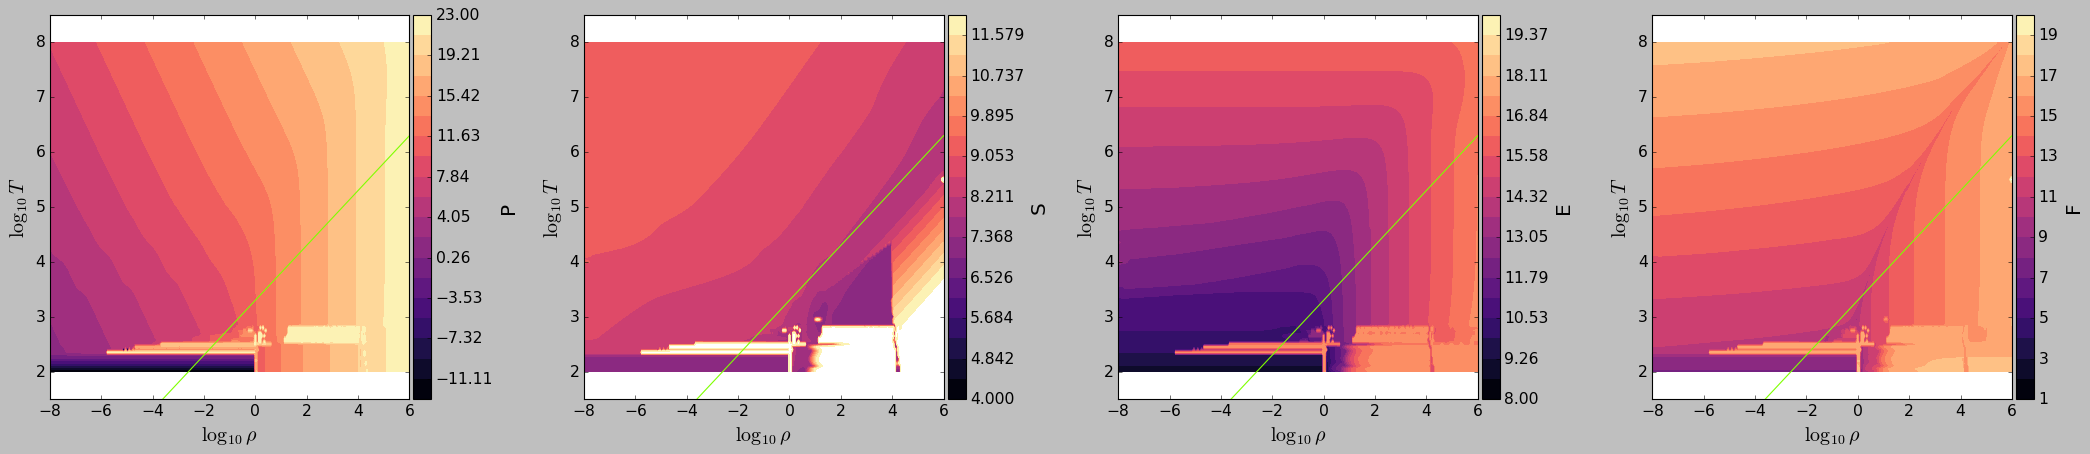

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_60z20x.data
0.2 0.19999999999999996 0.6000000000000001
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.397727449735005


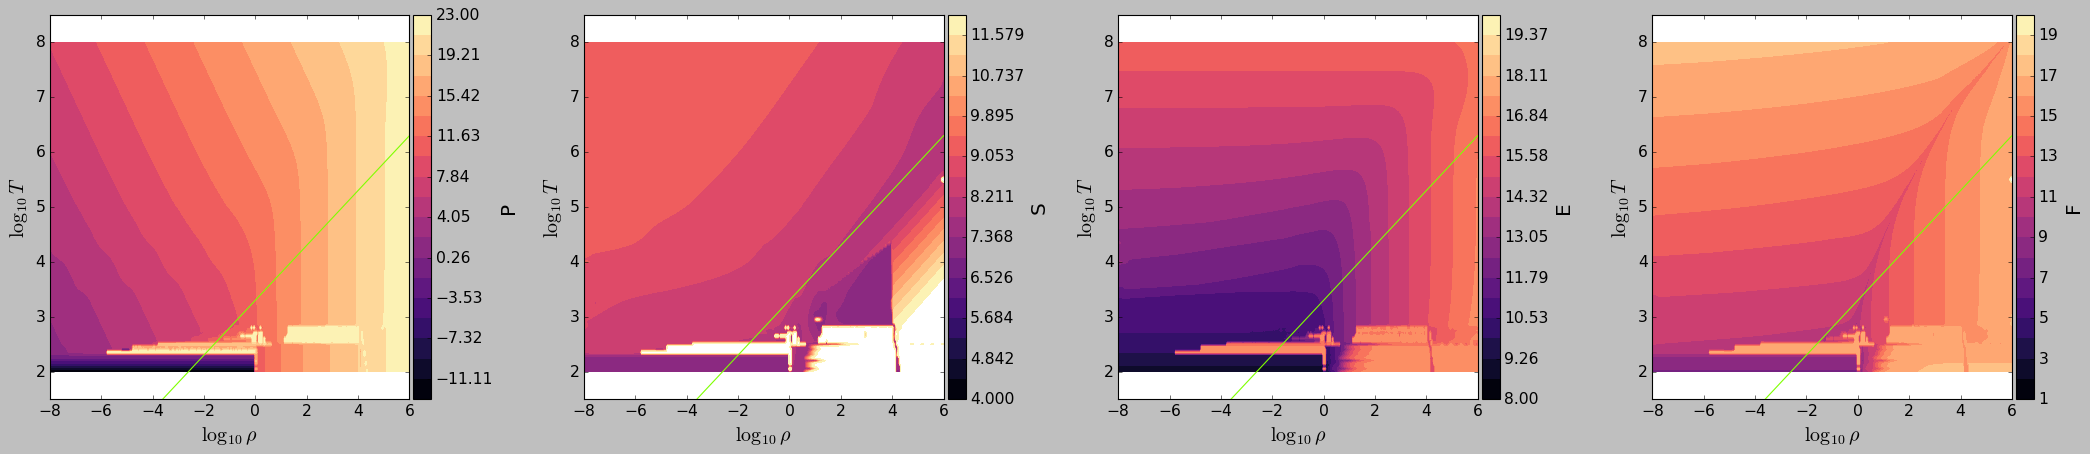

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_70z20x.data
0.2 0.09999999999999987 0.7000000000000001
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
10.459279000759125


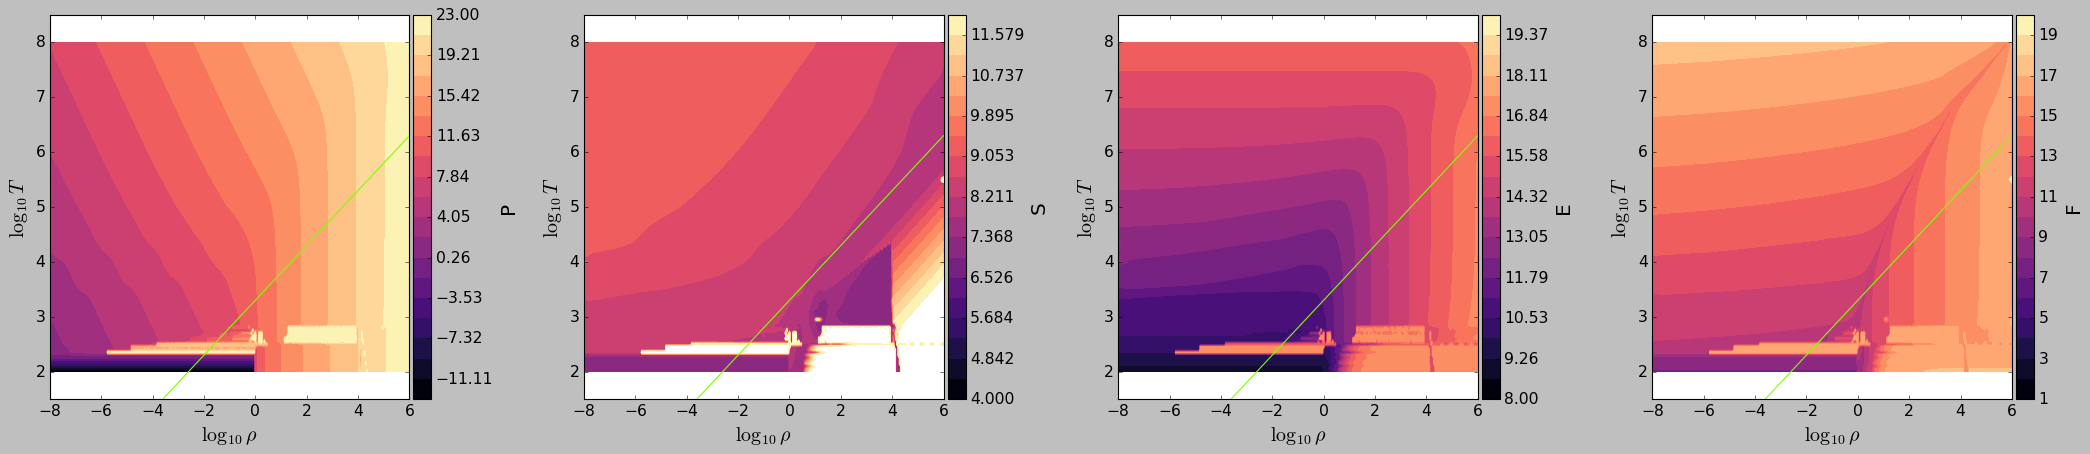

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_80z20x.data
0.2 0.0 0.8
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
6.992236431439718


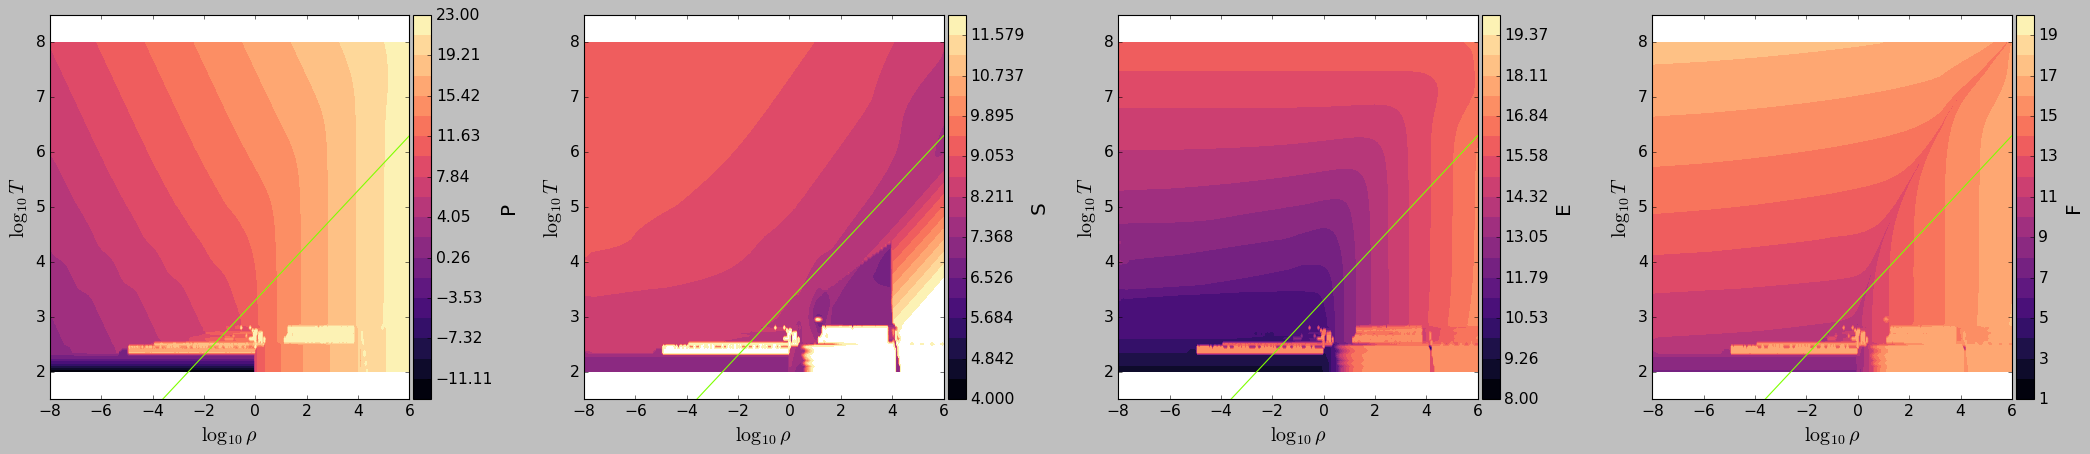

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z30x.data
0.30000000000000004 0.7 0.0
8.88616083463033


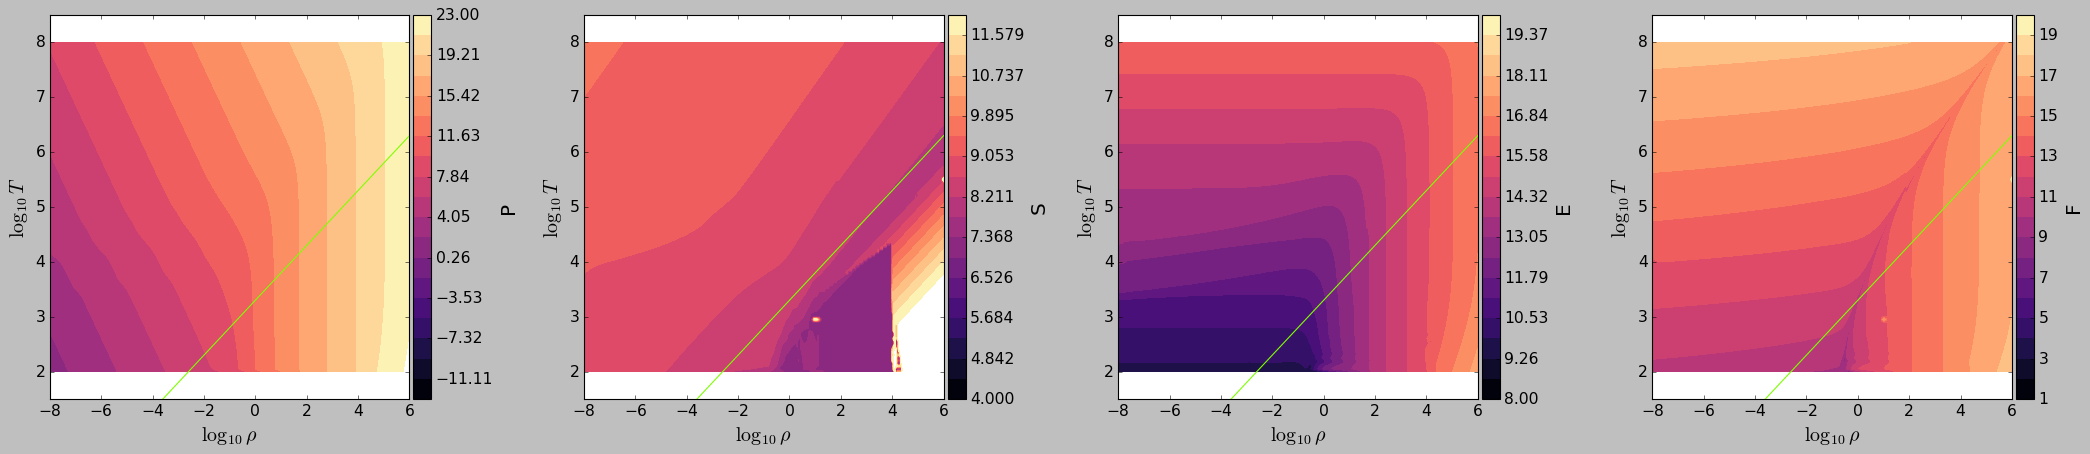

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_10z30x.data
0.30000000000000004 0.6 0.1
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
8.618841365973156


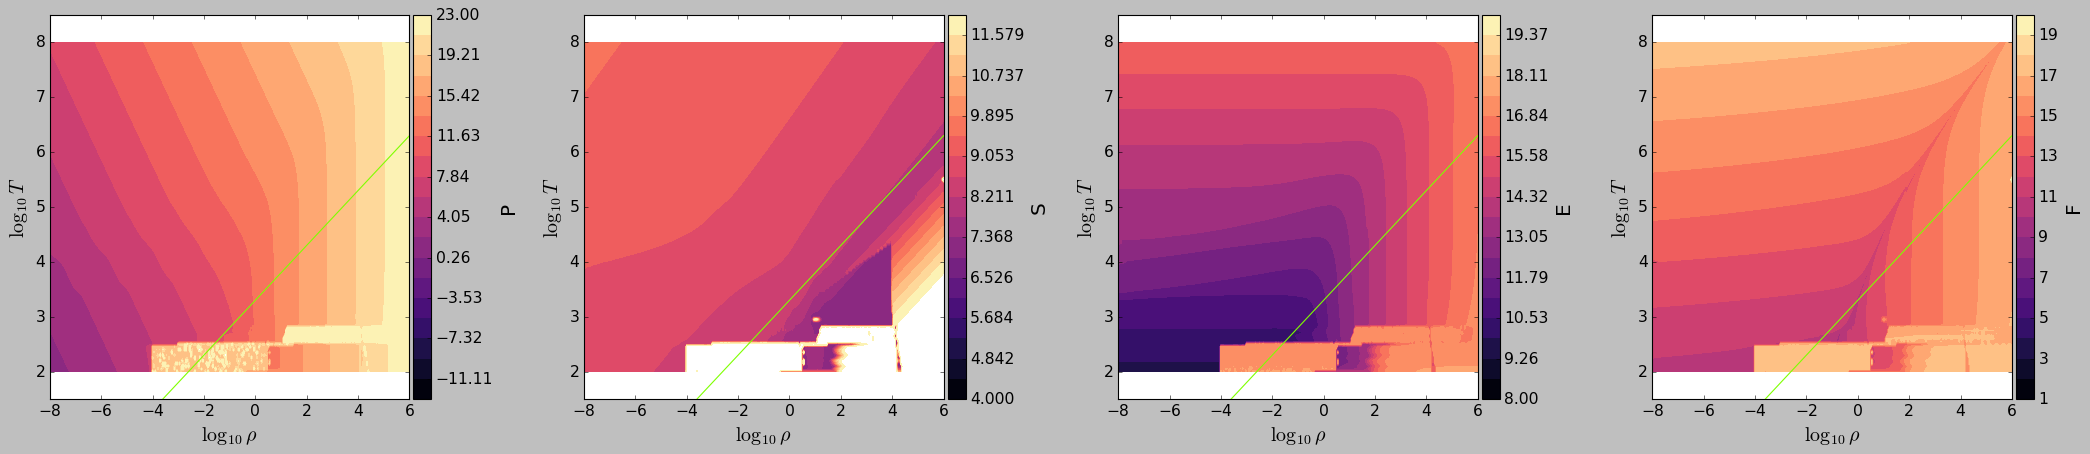

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_20z30x.data
0.30000000000000004 0.5 0.2
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
12.63297598361969


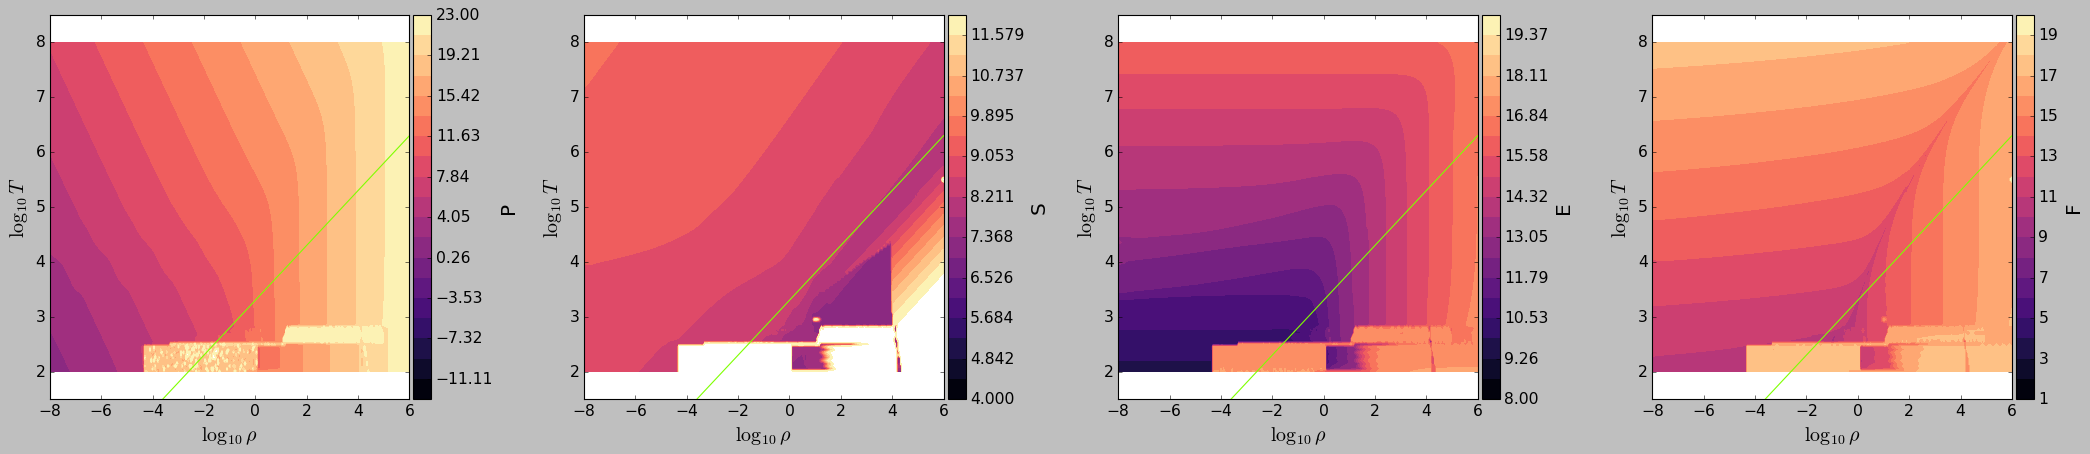

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_30z30x.data
0.30000000000000004 0.3999999999999999 0.30000000000000004
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.579117468992869


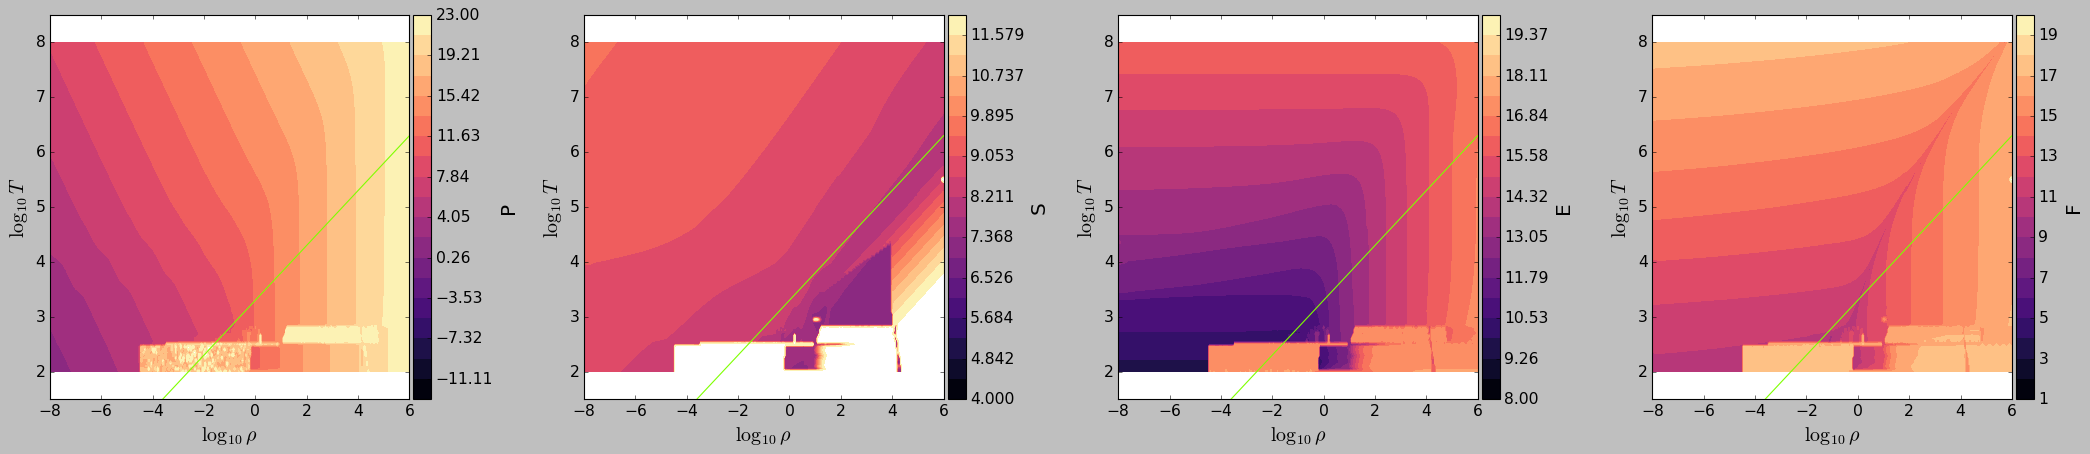

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_40z30x.data
0.30000000000000004 0.29999999999999993 0.4
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
10.321661798159282


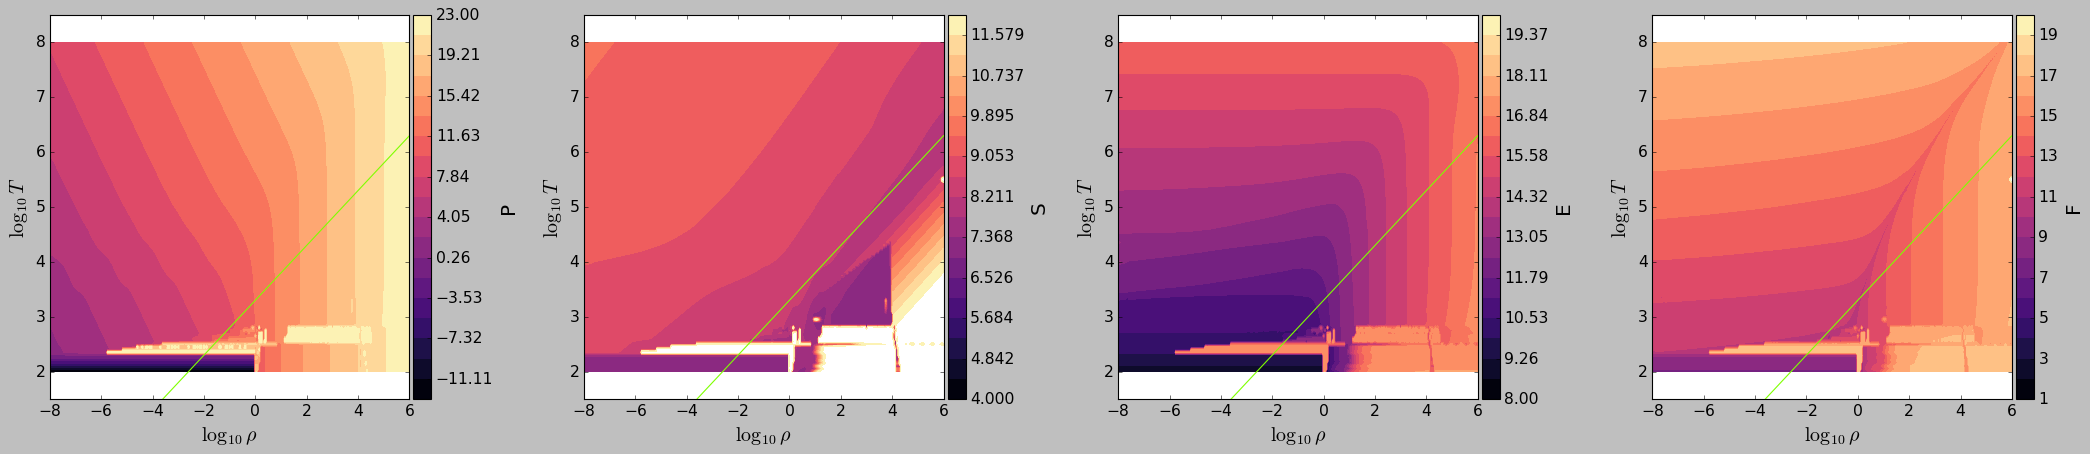

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_50z30x.data
0.30000000000000004 0.19999999999999996 0.5
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
6.653420249621074


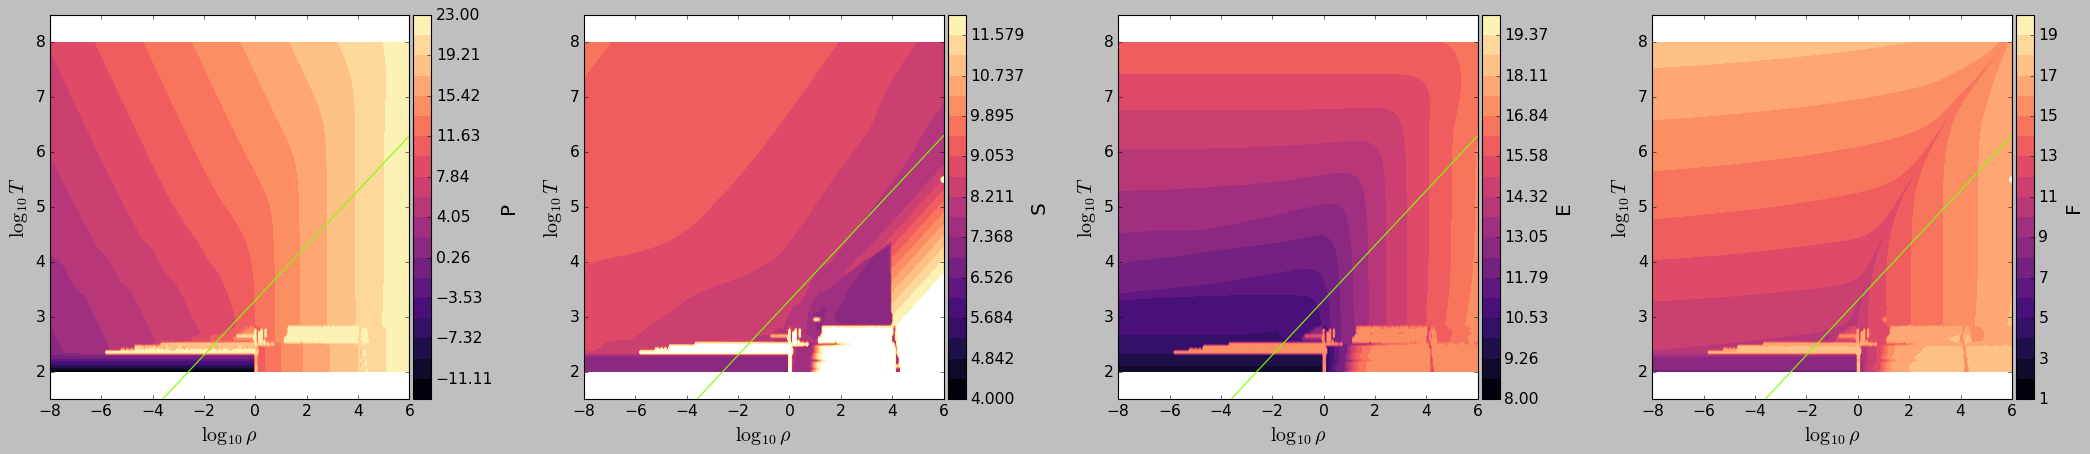

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_60z30x.data
0.30000000000000004 0.09999999999999987 0.6000000000000001
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
9.58853083451589


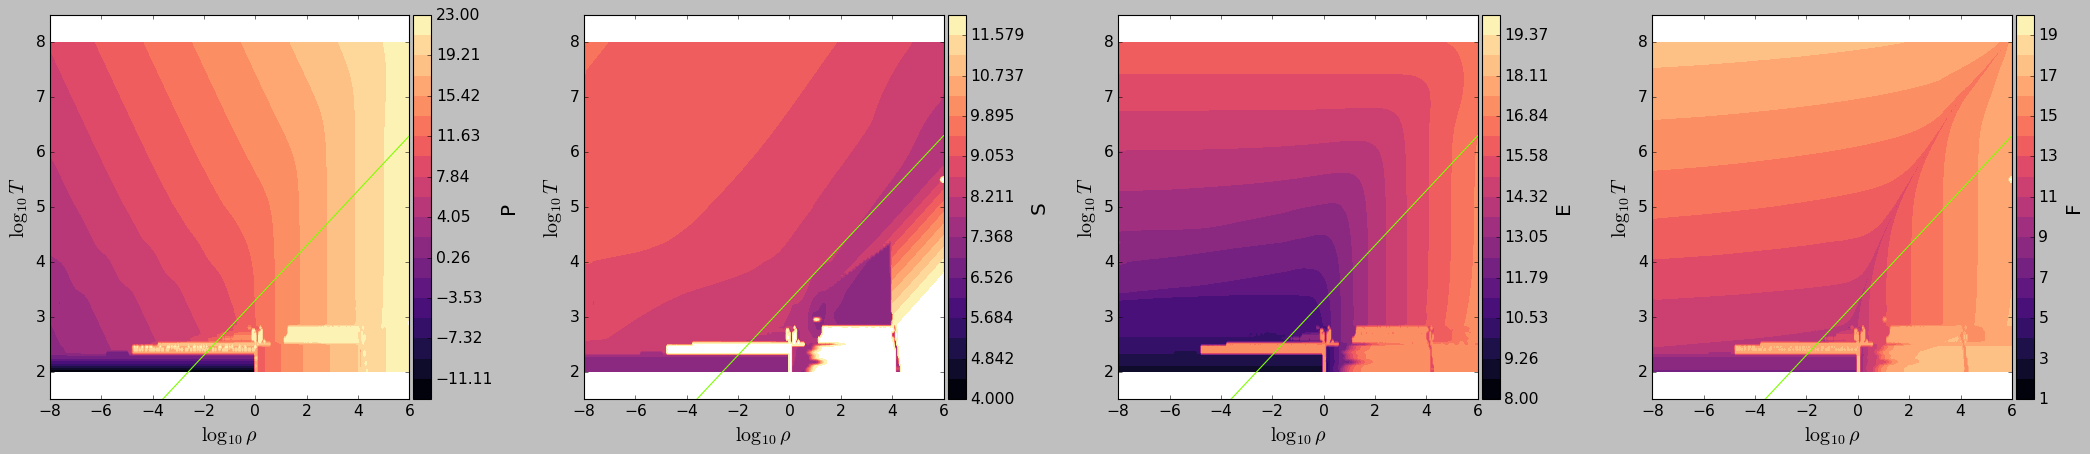

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_70z30x.data
0.30000000000000004 0.0 0.7000000000000001
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.098180913925171


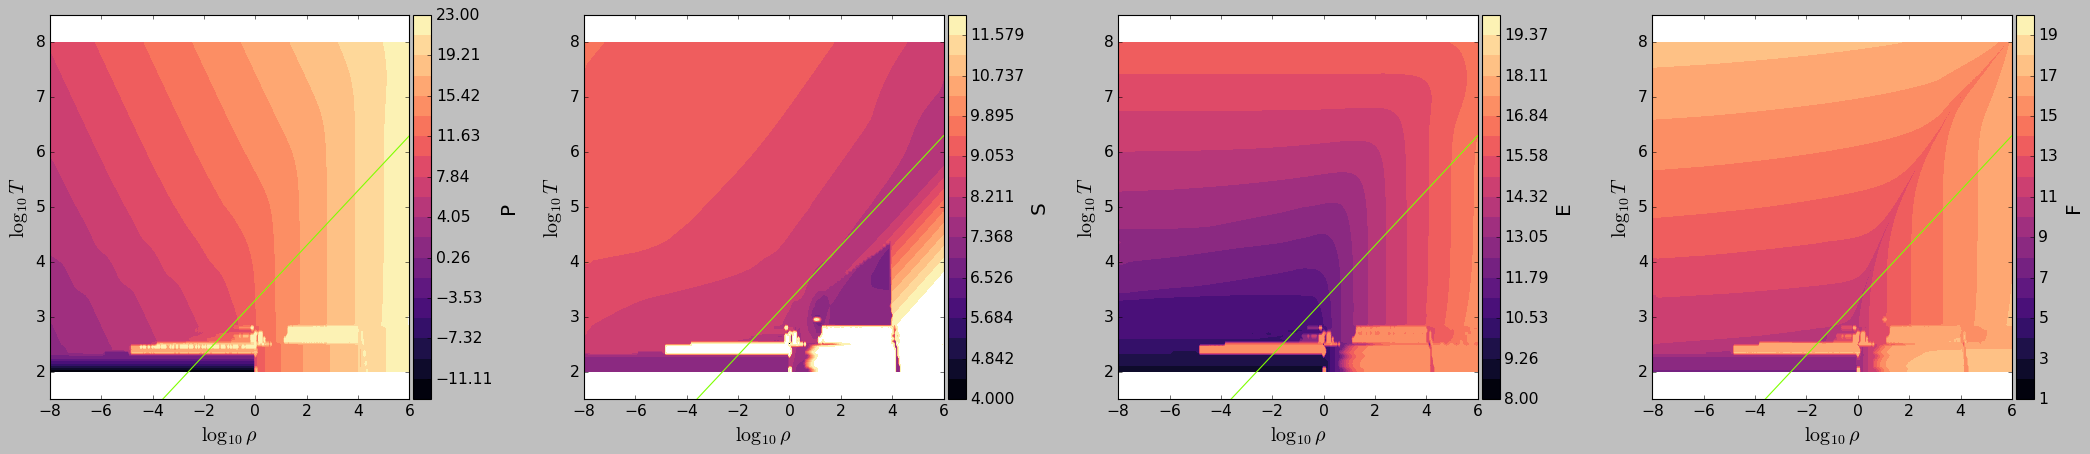

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z40x.data
0.4 0.6 0.0
8.739176015059153


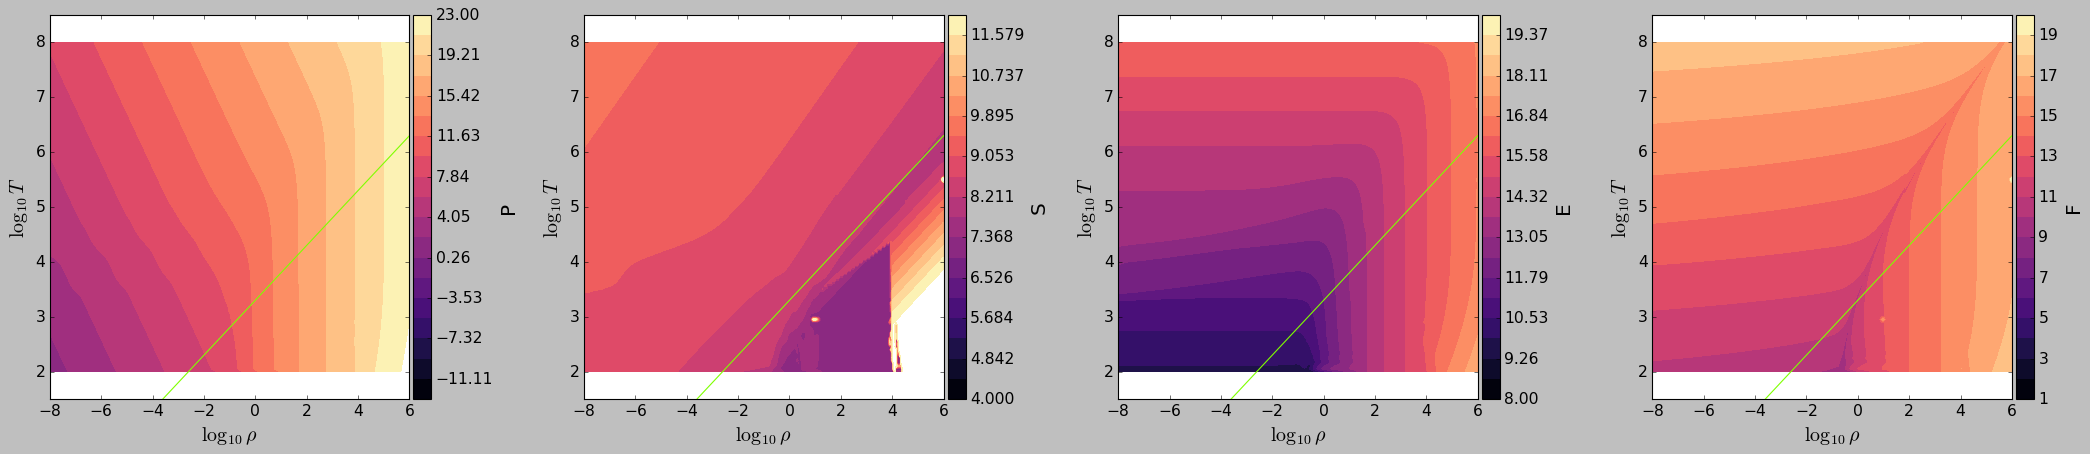

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_10z40x.data
0.4 0.5 0.1
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
9.625908799966176


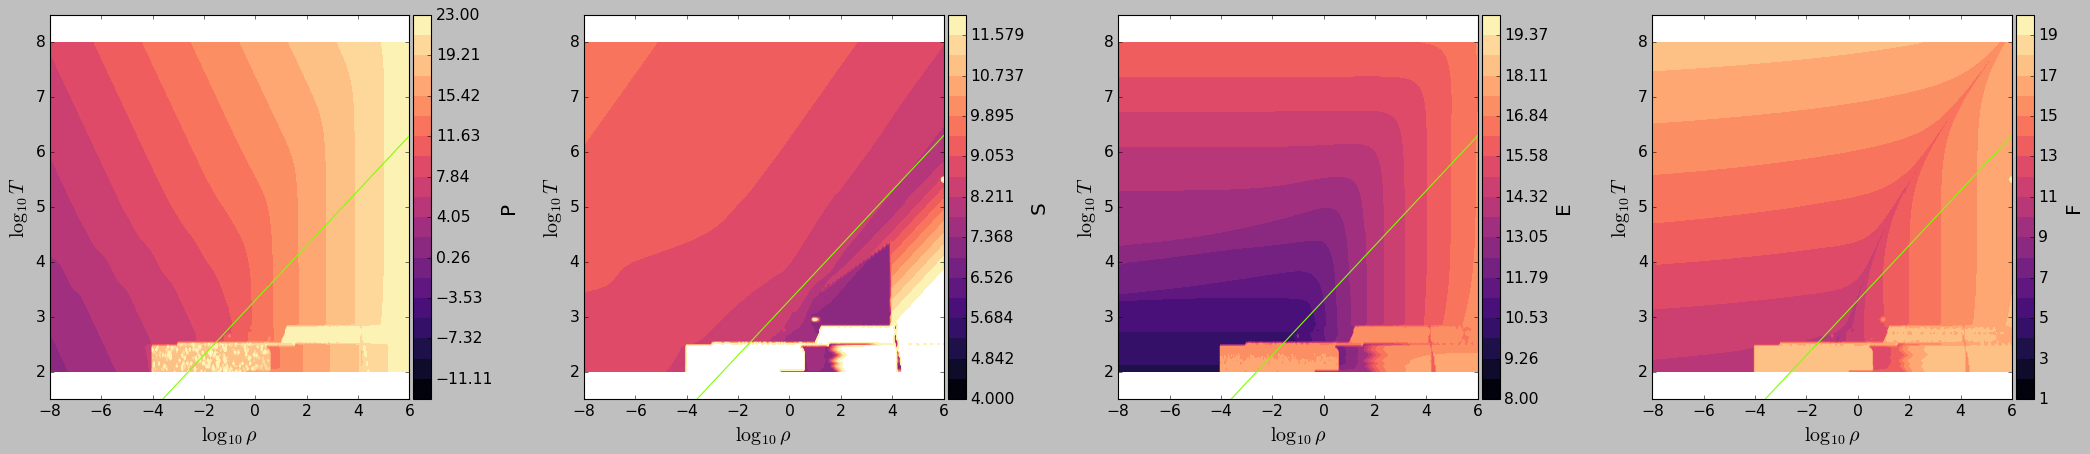

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_20z40x.data
0.4 0.3999999999999999 0.2
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
11.292947550614675


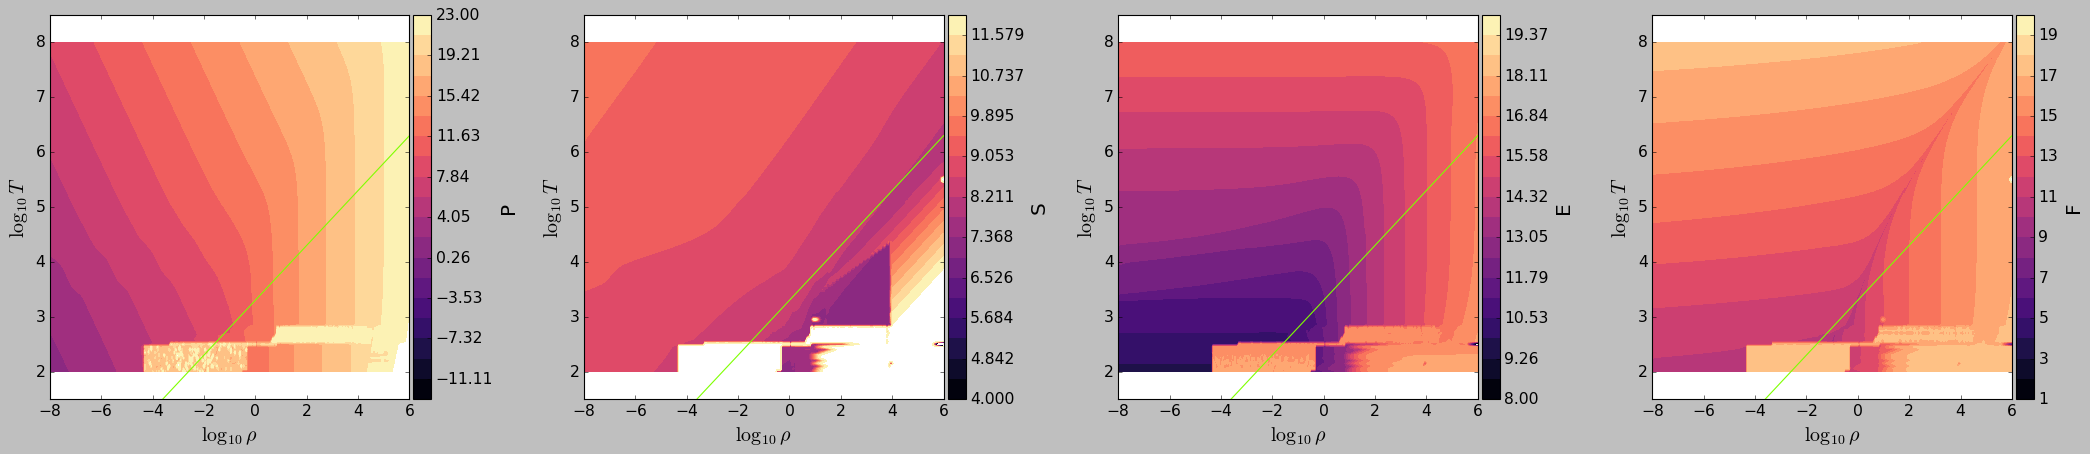

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_30z40x.data
0.4 0.29999999999999993 0.30000000000000004
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.913791386286418


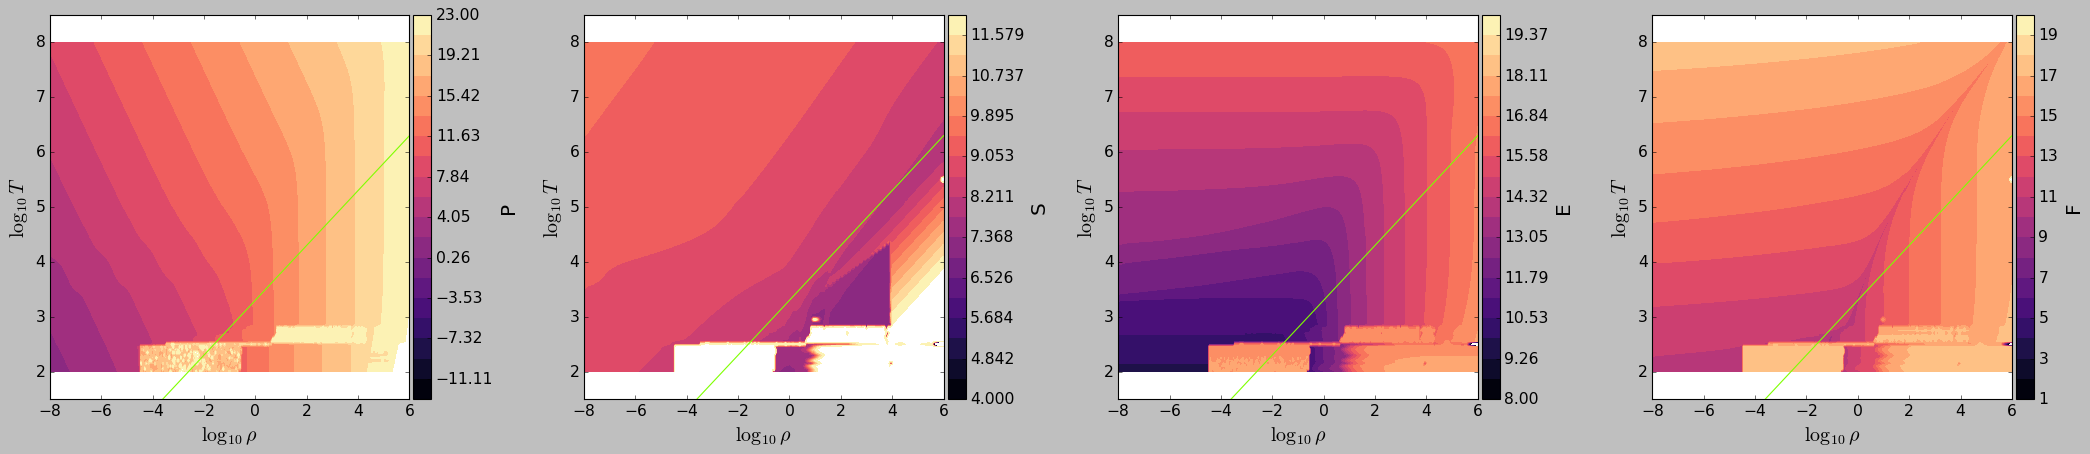

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_40z40x.data
0.4 0.19999999999999996 0.4
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
10.695422013600668


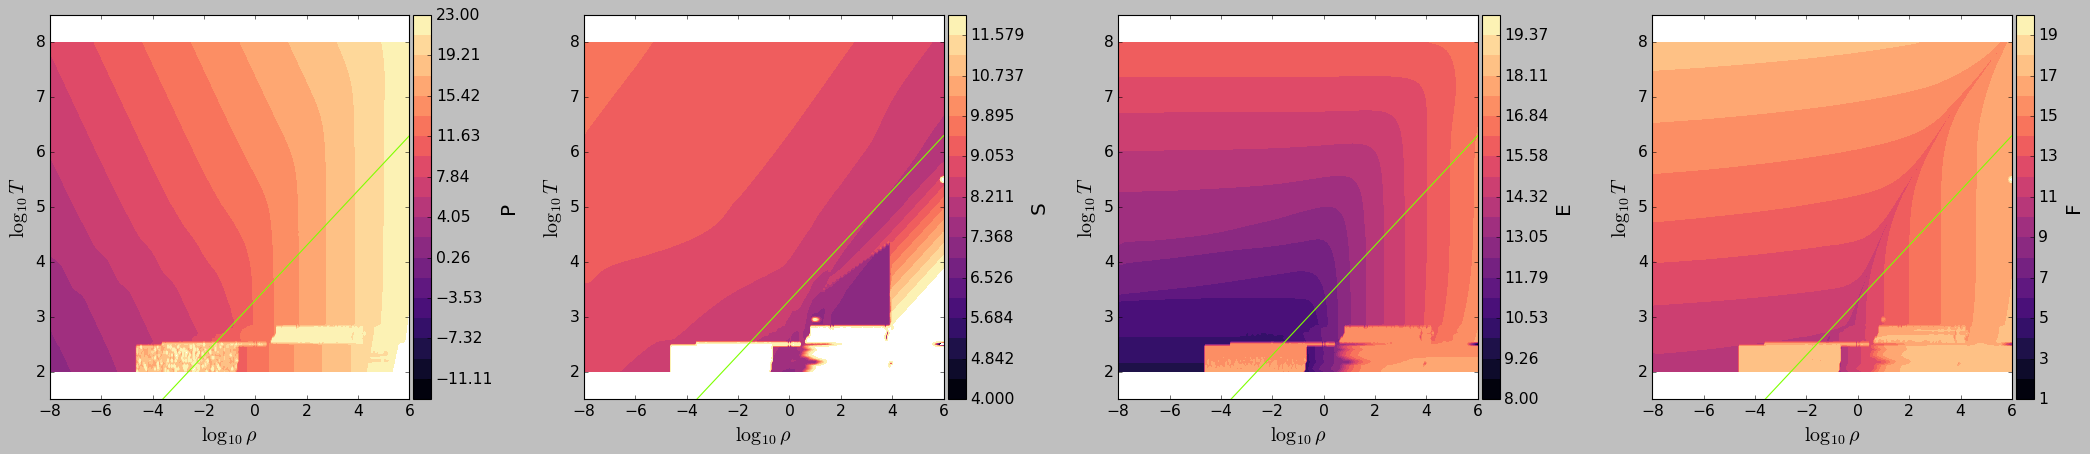

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_50z40x.data
0.4 0.09999999999999998 0.5
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
7.178179121017456


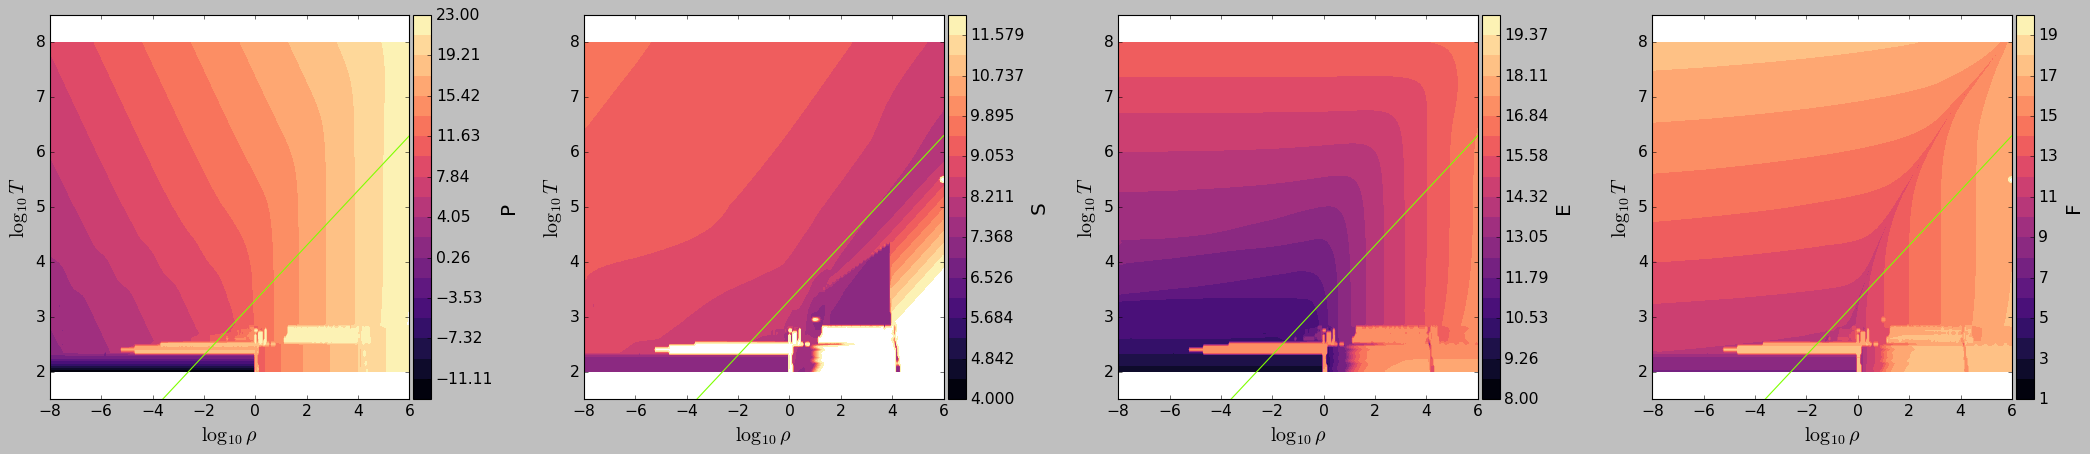

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_60z40x.data
0.4 0.0 0.6000000000000001
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
9.677320853869121


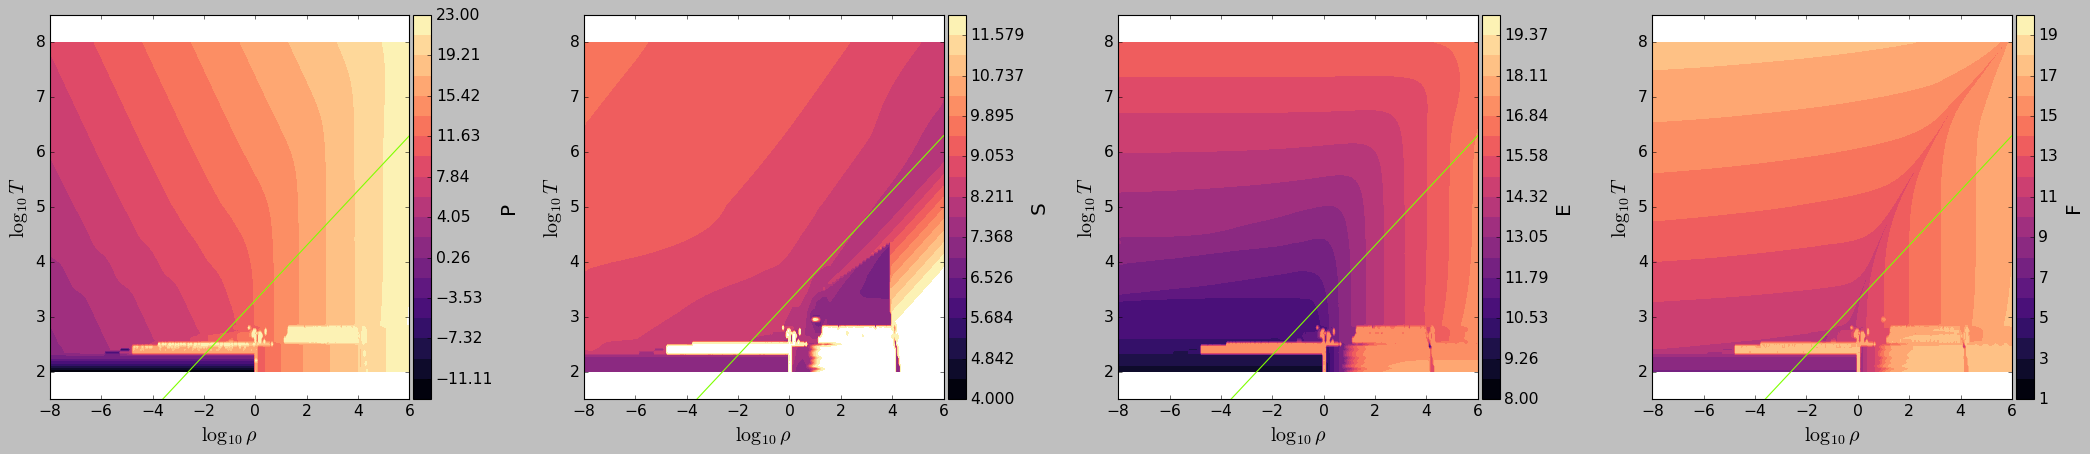

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z50x.data
0.5 0.5 0.0
7.520388054847717


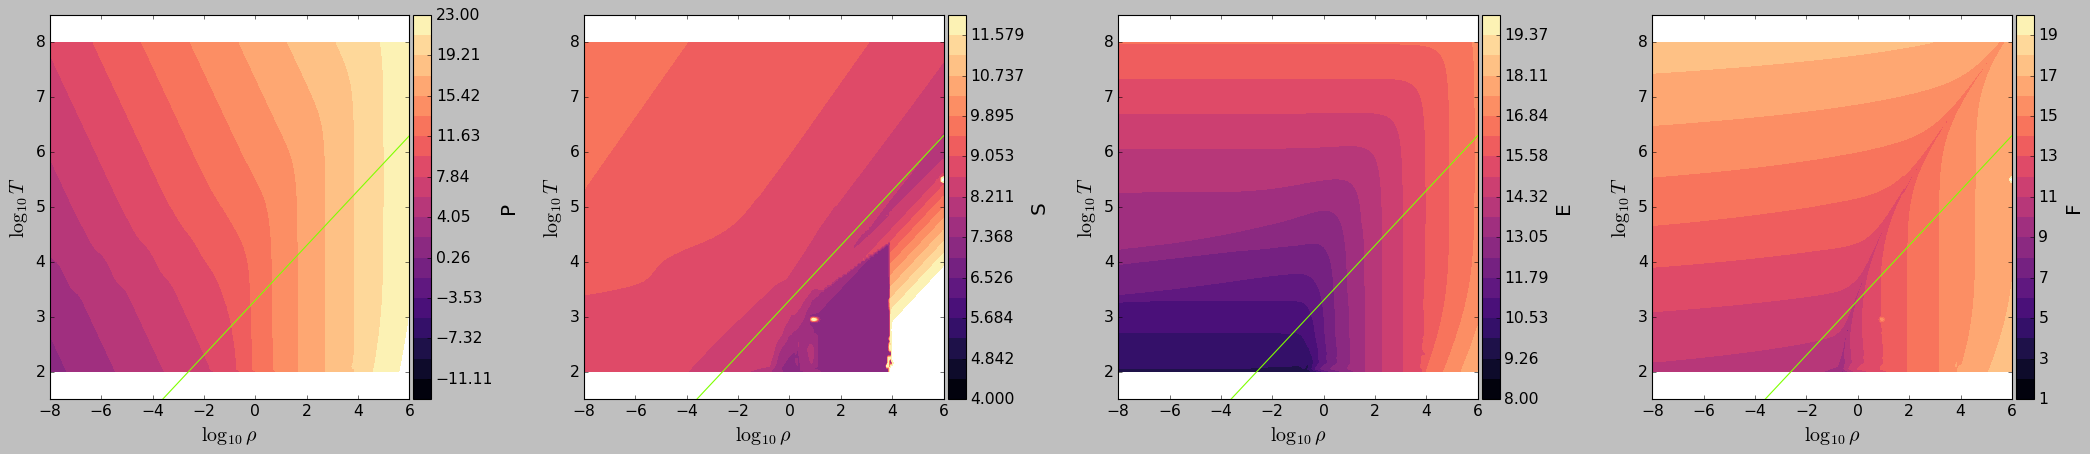

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_10z50x.data
0.5 0.4 0.1
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
11.538988415400187


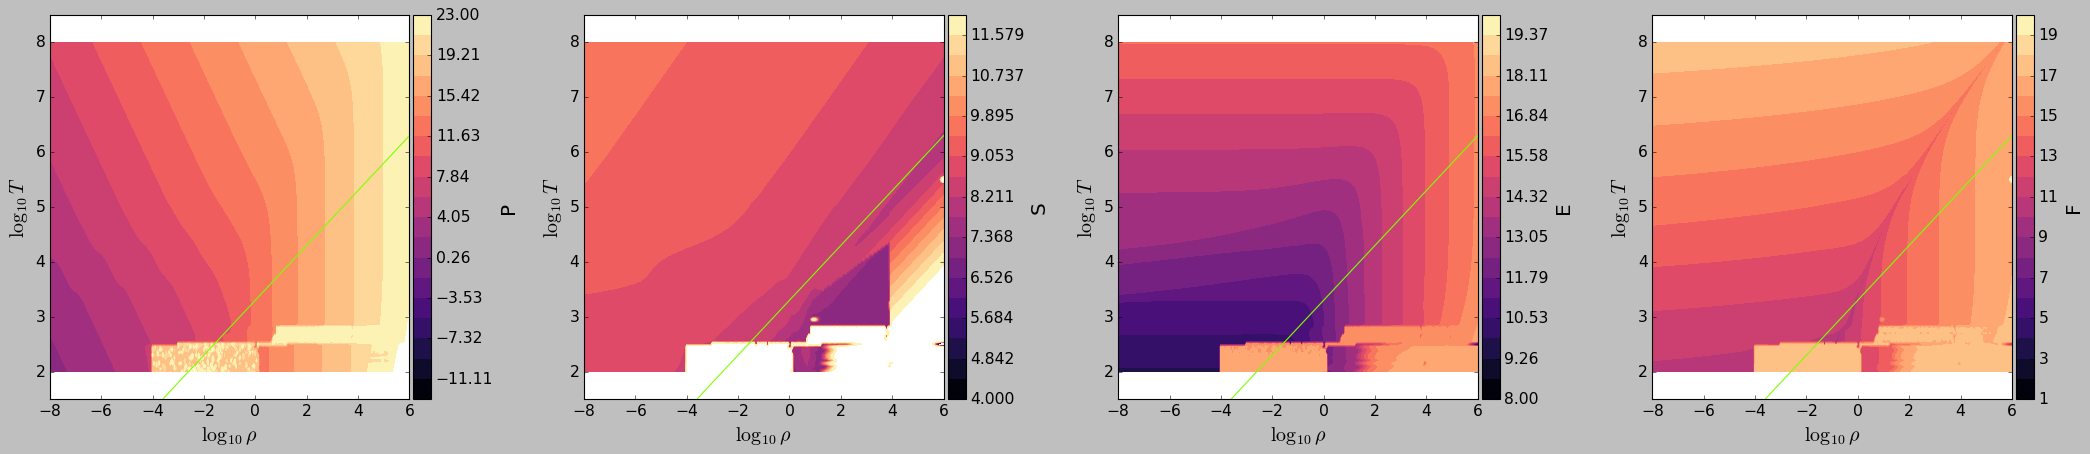

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_20z50x.data
0.5 0.30000000000000004 0.2
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
9.628612220287323


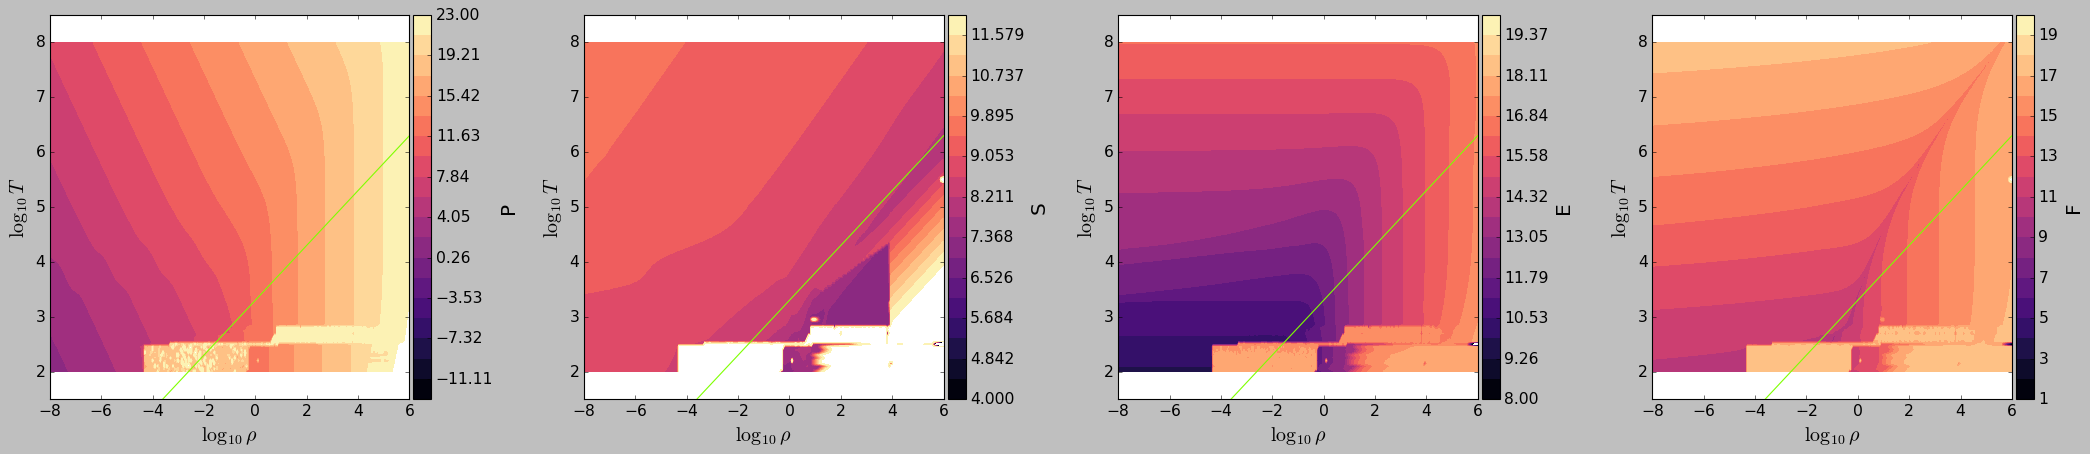

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_30z50x.data
0.5 0.19999999999999996 0.30000000000000004
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
10.81536276737849


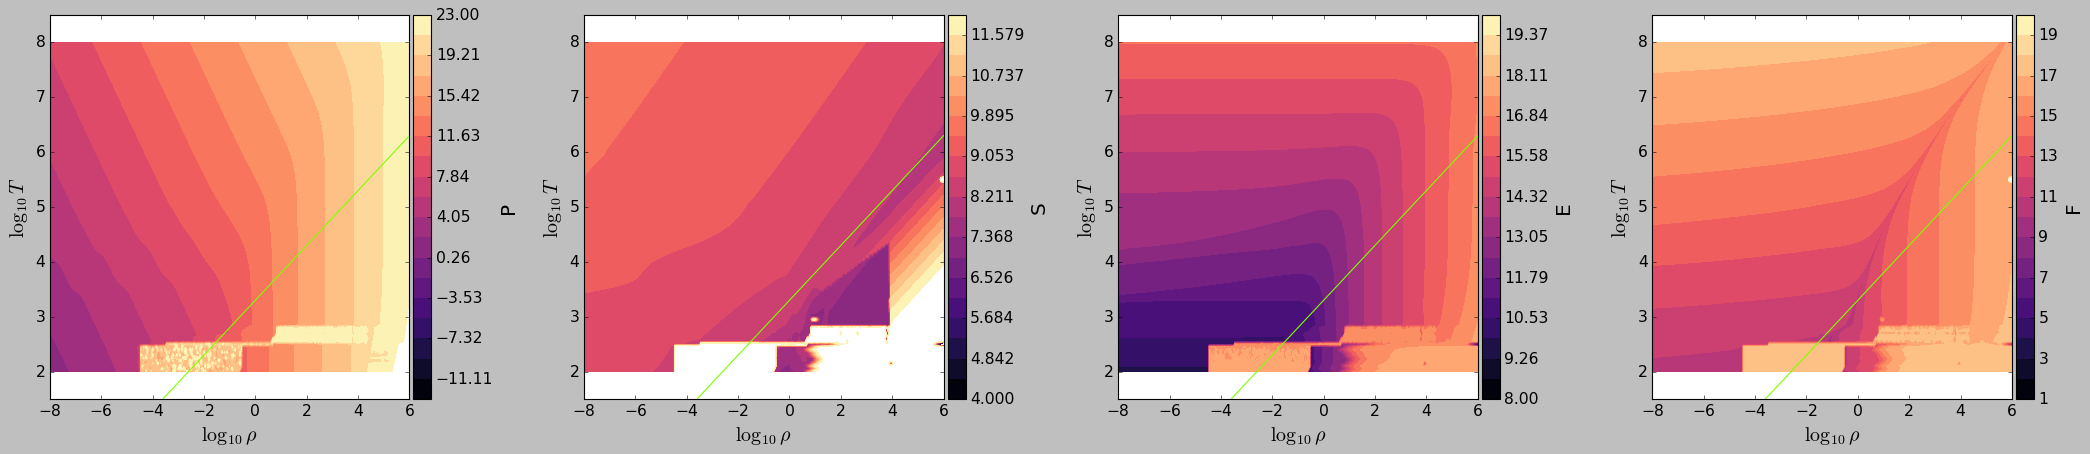

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_40z50x.data
0.5 0.09999999999999998 0.4
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
9.080605288346609


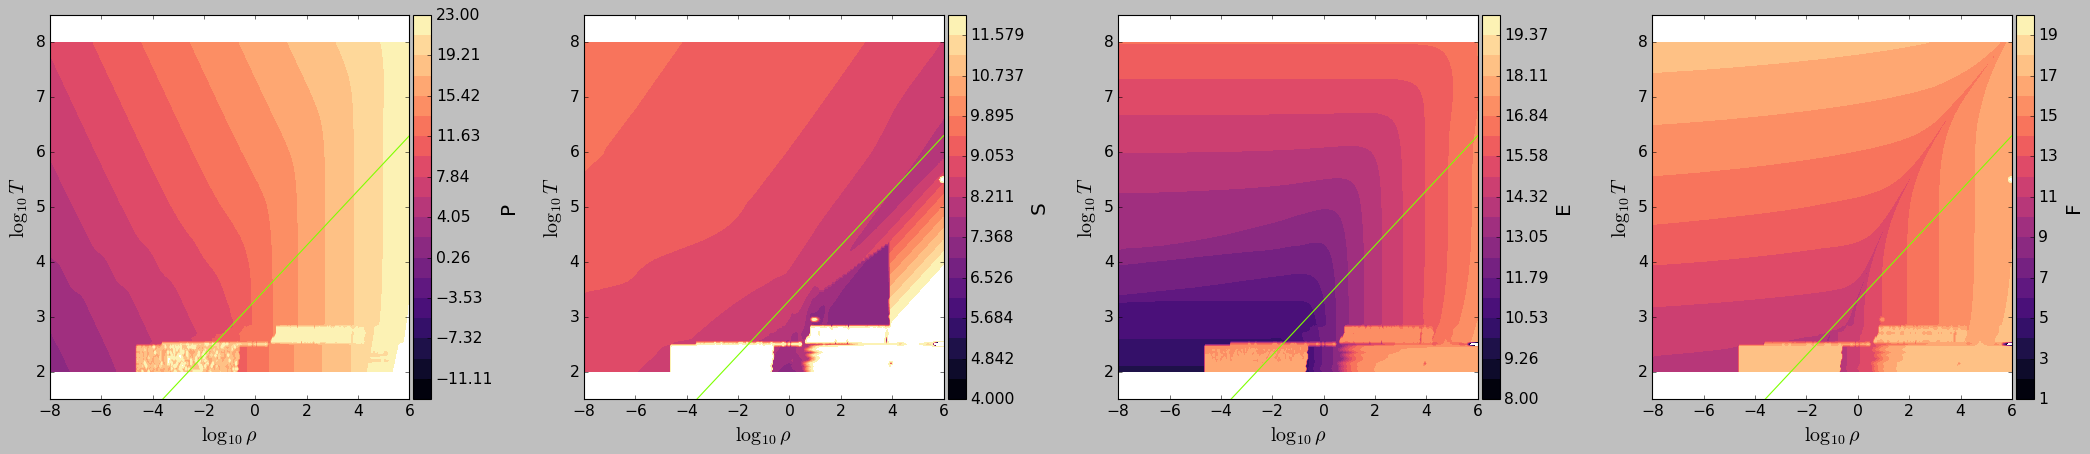

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_50z50x.data
0.5 0.0 0.5
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
10.147639747460683


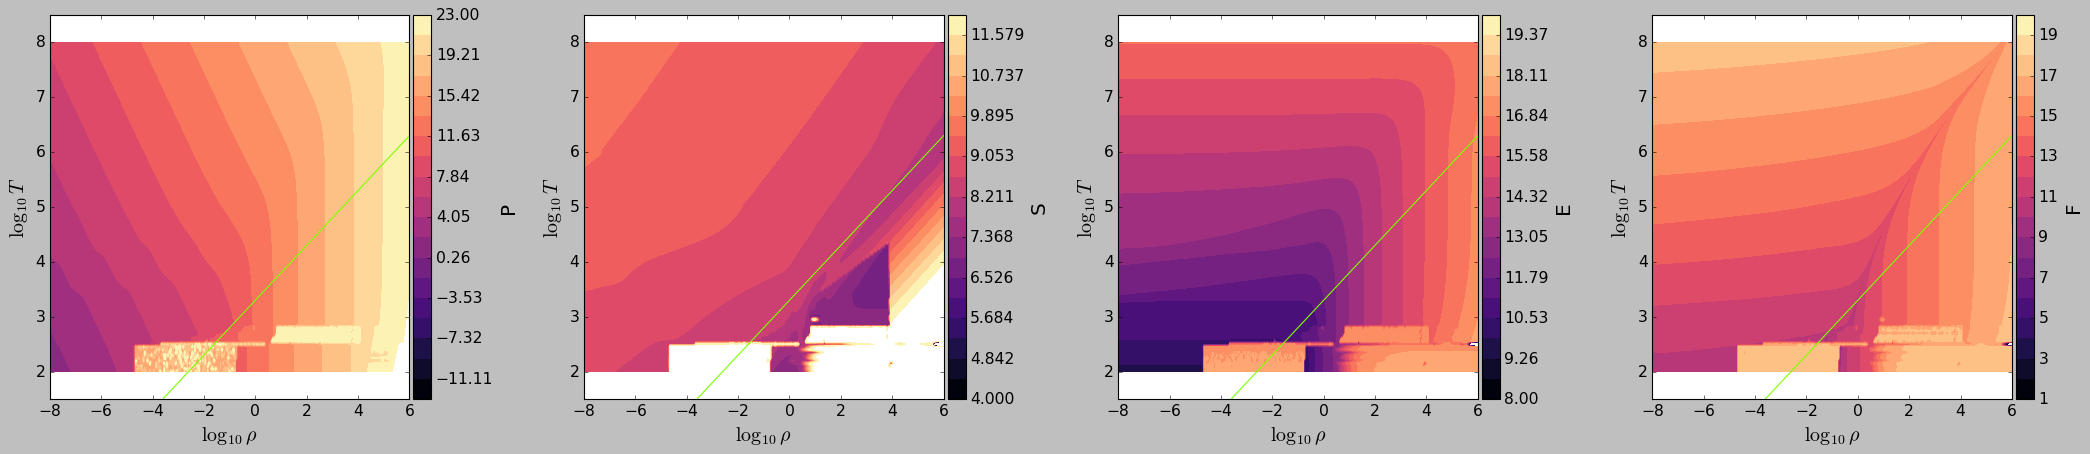

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z60x.data
0.6000000000000001 0.3999999999999999 0.0
6.883526114622752


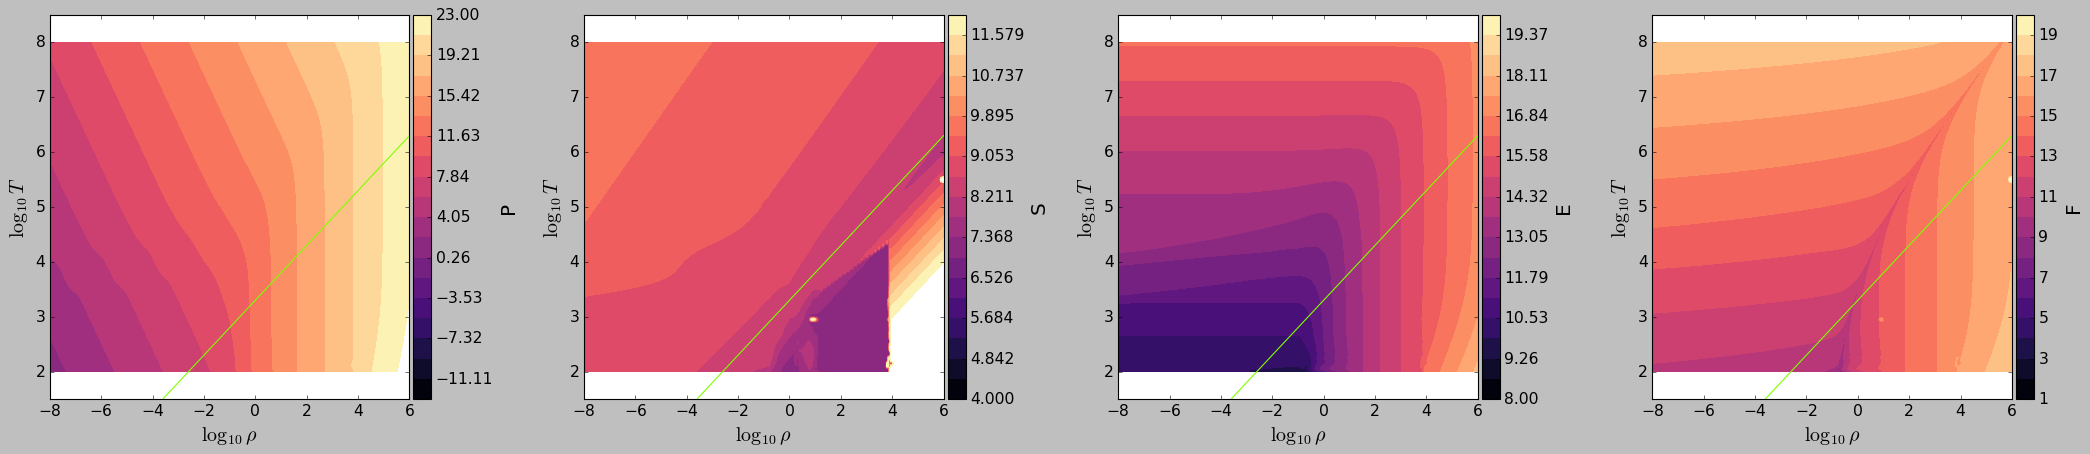

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_10z60x.data
0.6000000000000001 0.29999999999999993 0.1
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
9.05958424806595


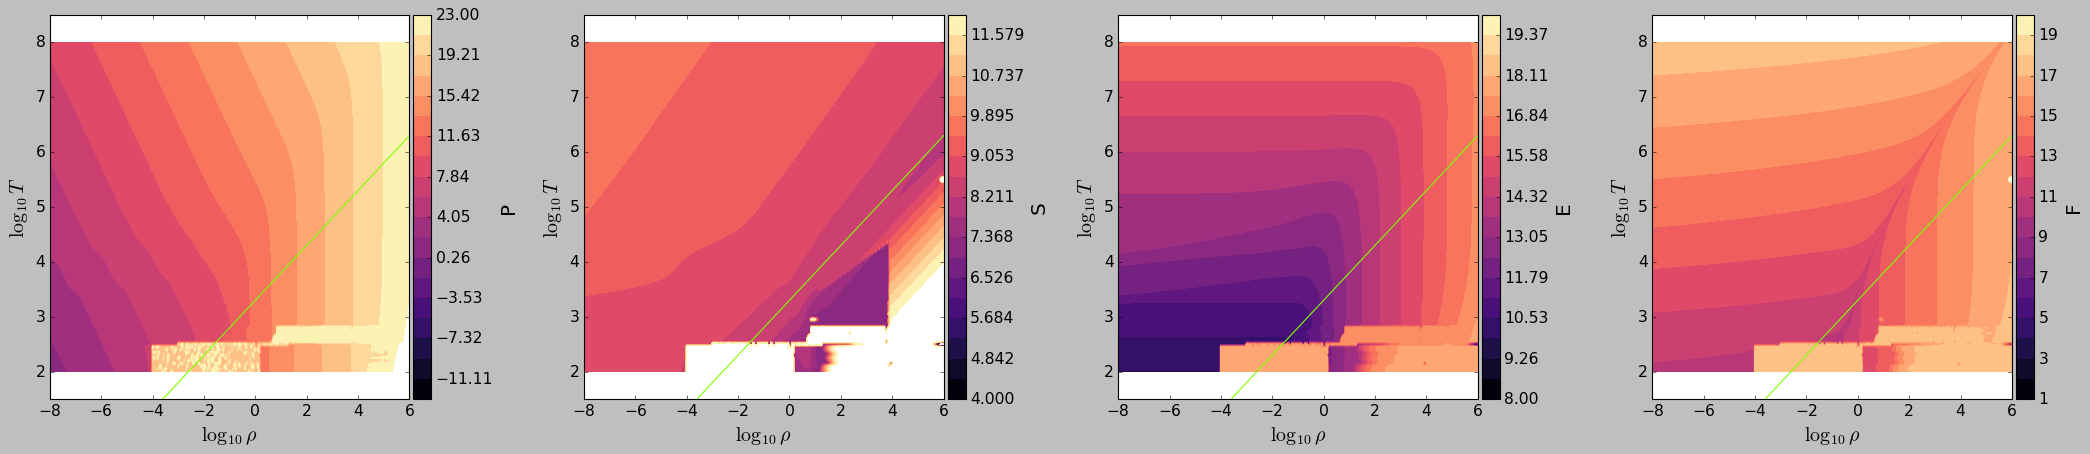

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_20z60x.data
0.6000000000000001 0.19999999999999996 0.2
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
10.253606748580932


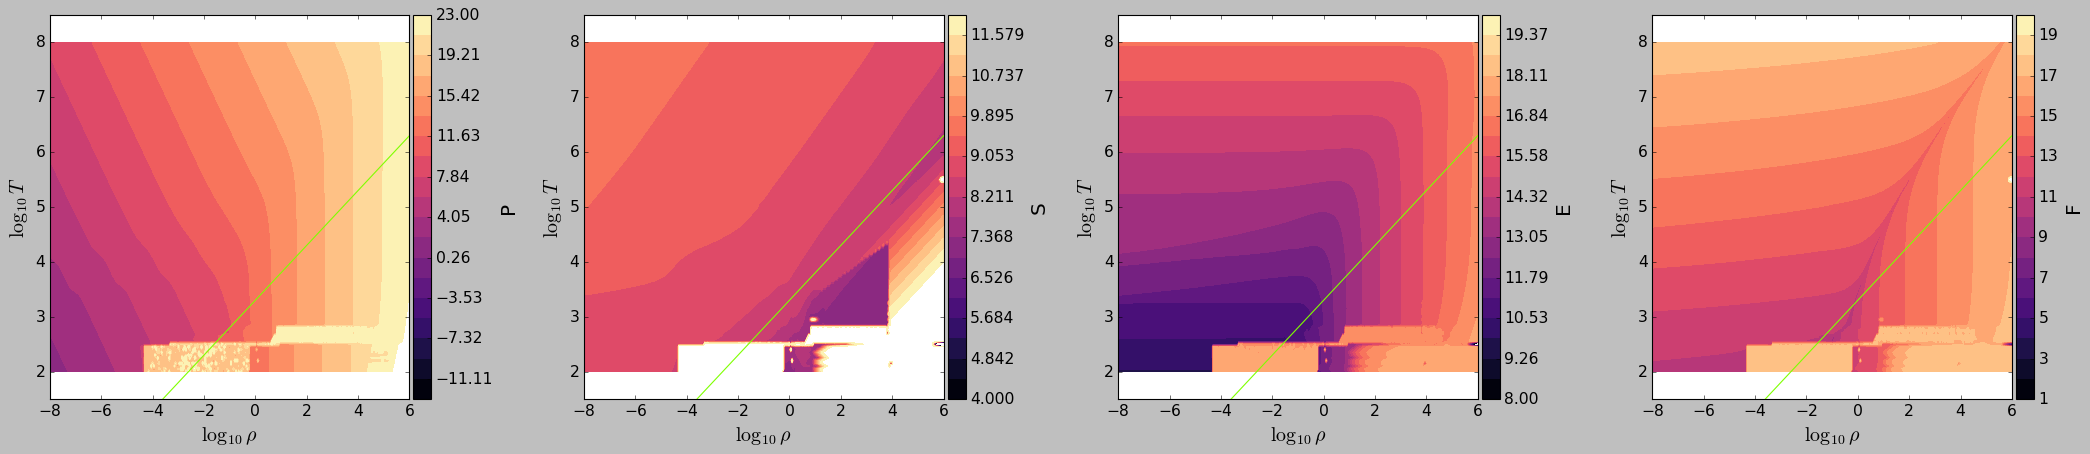

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_30z60x.data
0.6000000000000001 0.09999999999999987 0.30000000000000004
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
10.527578421433766


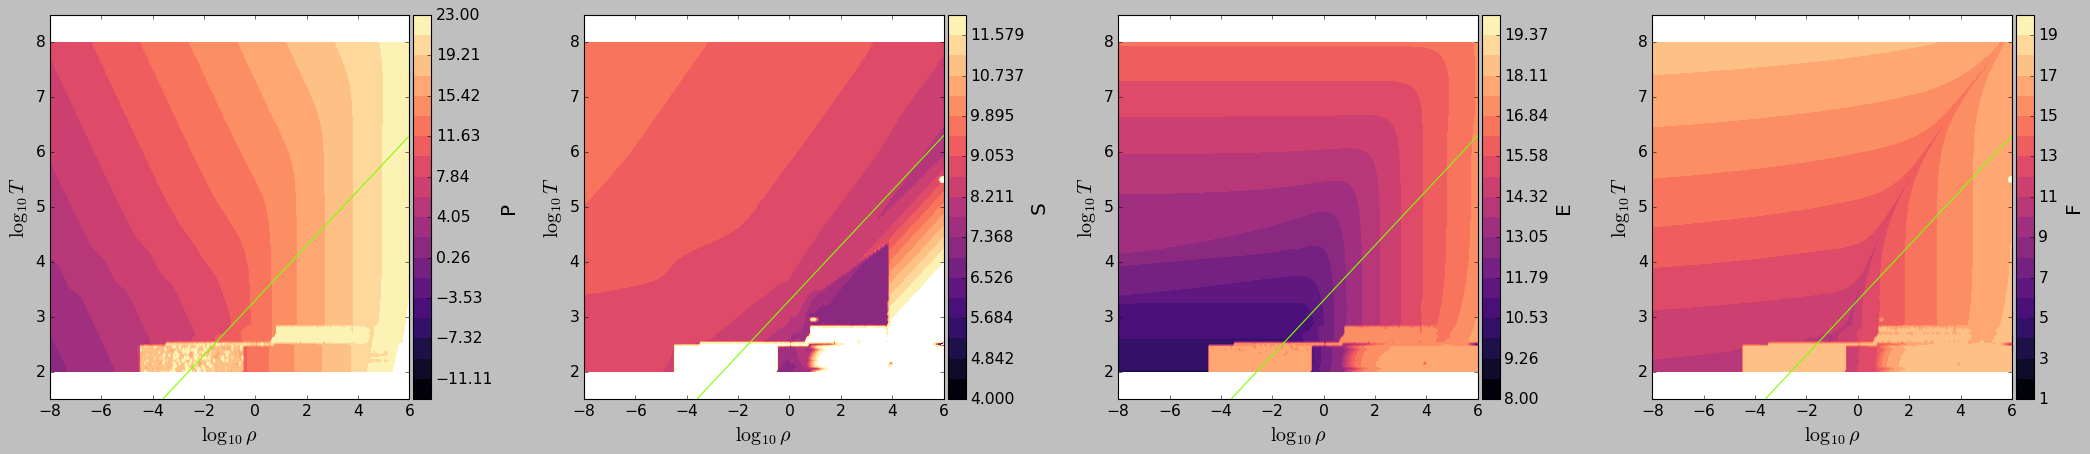

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_40z60x.data
0.6000000000000001 0.0 0.4
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
8.81934895515442


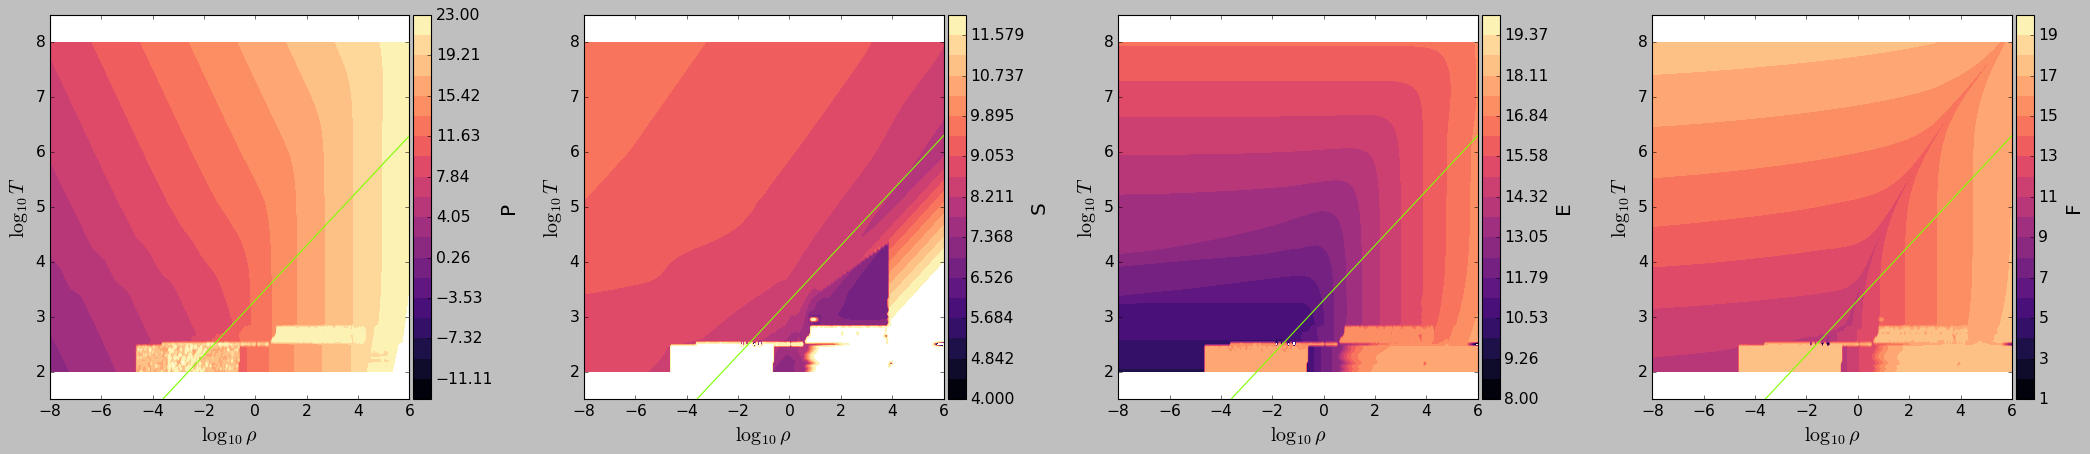

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z70x.data
0.7000000000000001 0.29999999999999993 0.0
3.2906595826148988


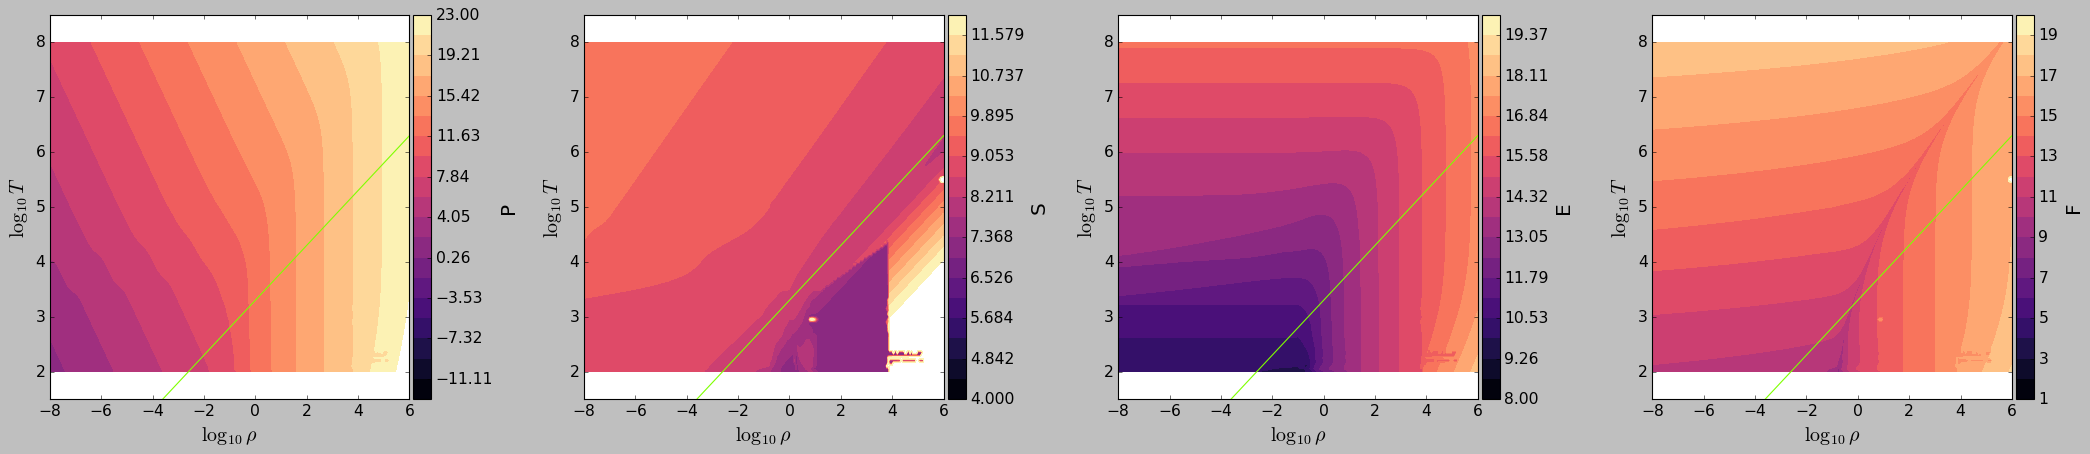

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_10z70x.data
0.7000000000000001 0.19999999999999996 0.1
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
5.4015572985013325


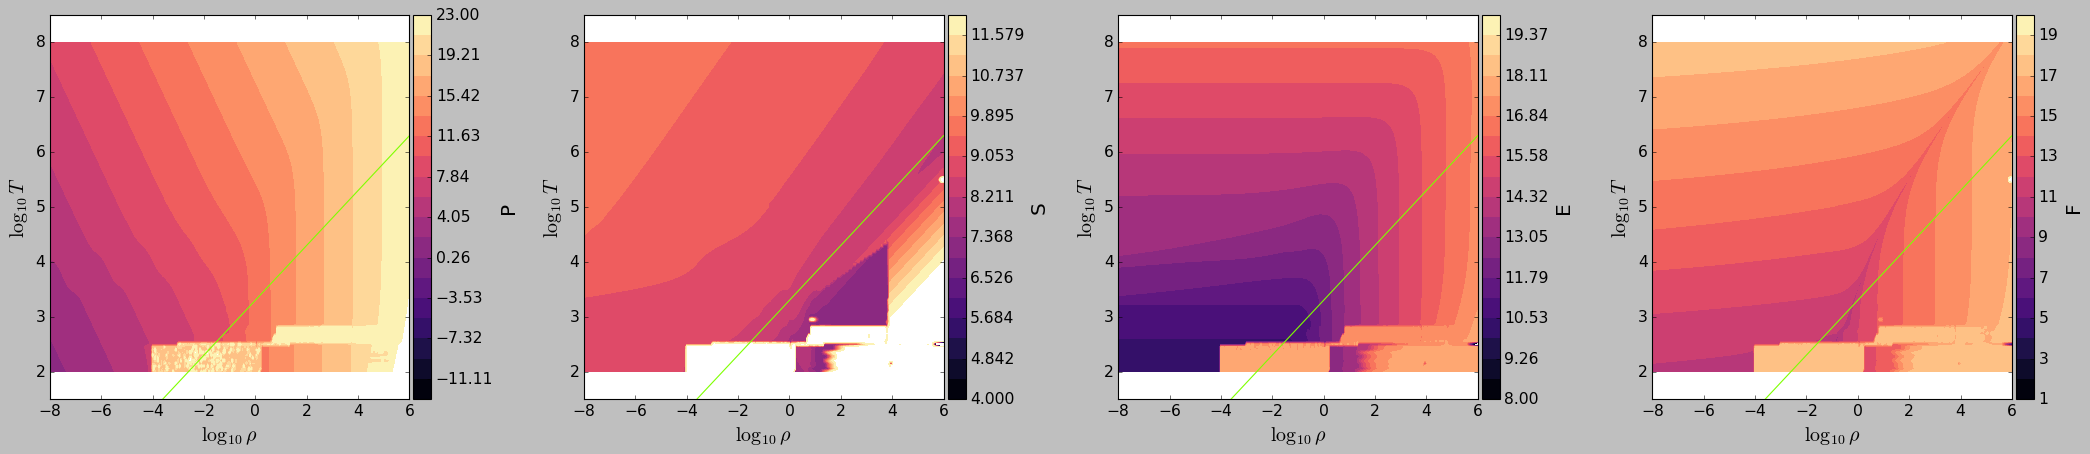

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_20z70x.data
0.7000000000000001 0.09999999999999987 0.2
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
3.298017080624898


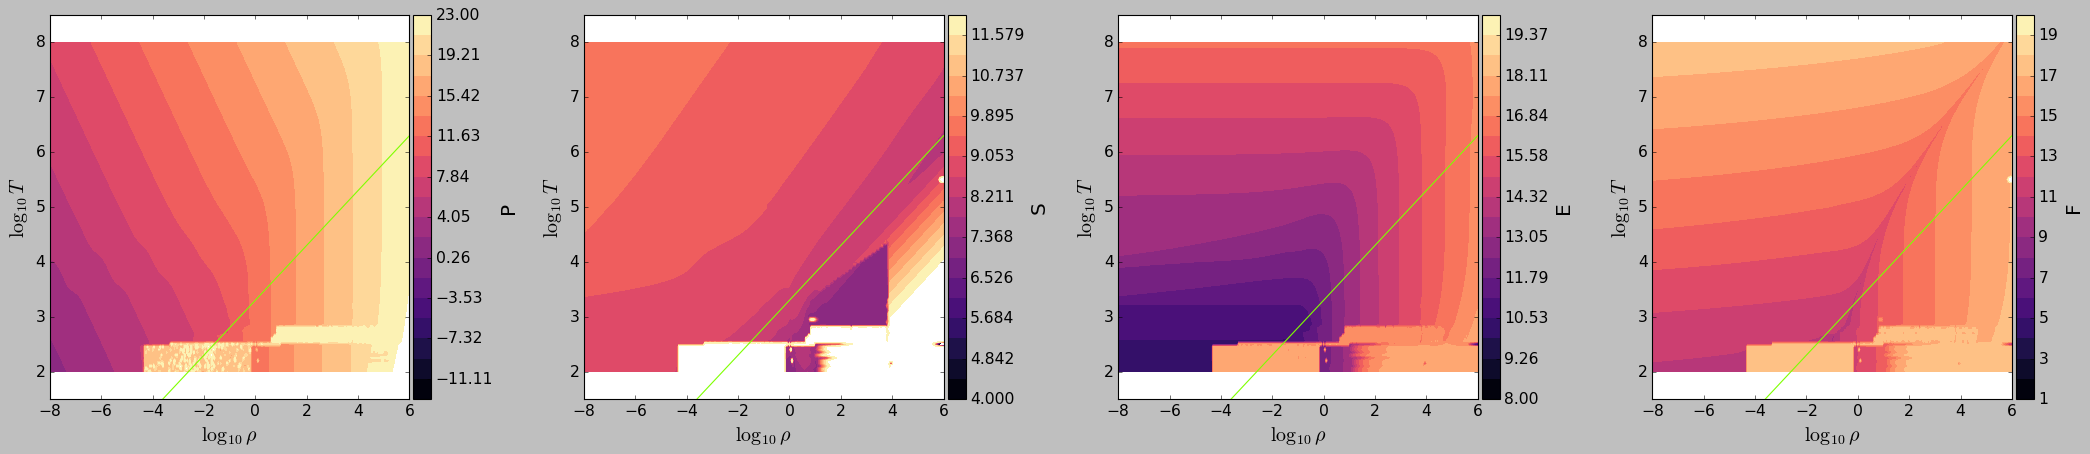

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_30z70x.data
0.7000000000000001 0.0 0.30000000000000004
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
4.438922850290934


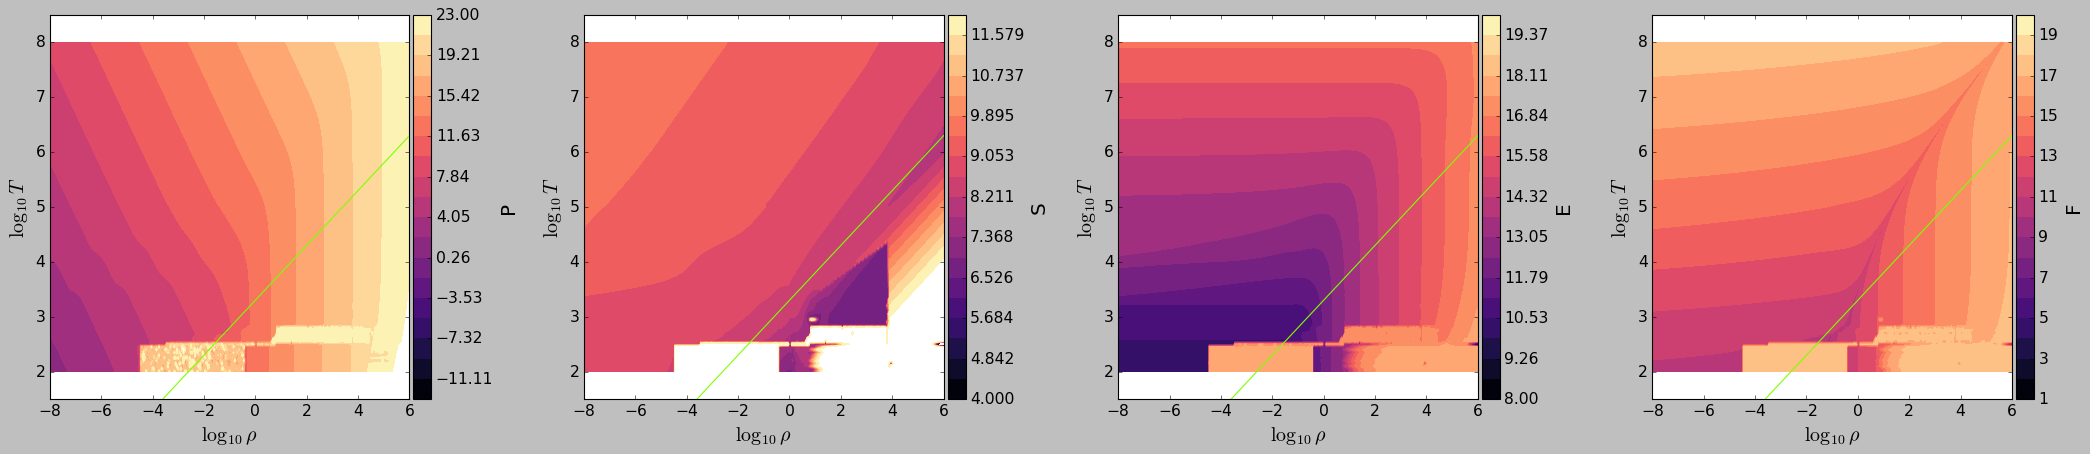

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z80x.data
0.8 0.19999999999999996 0.0
3.133019383748372


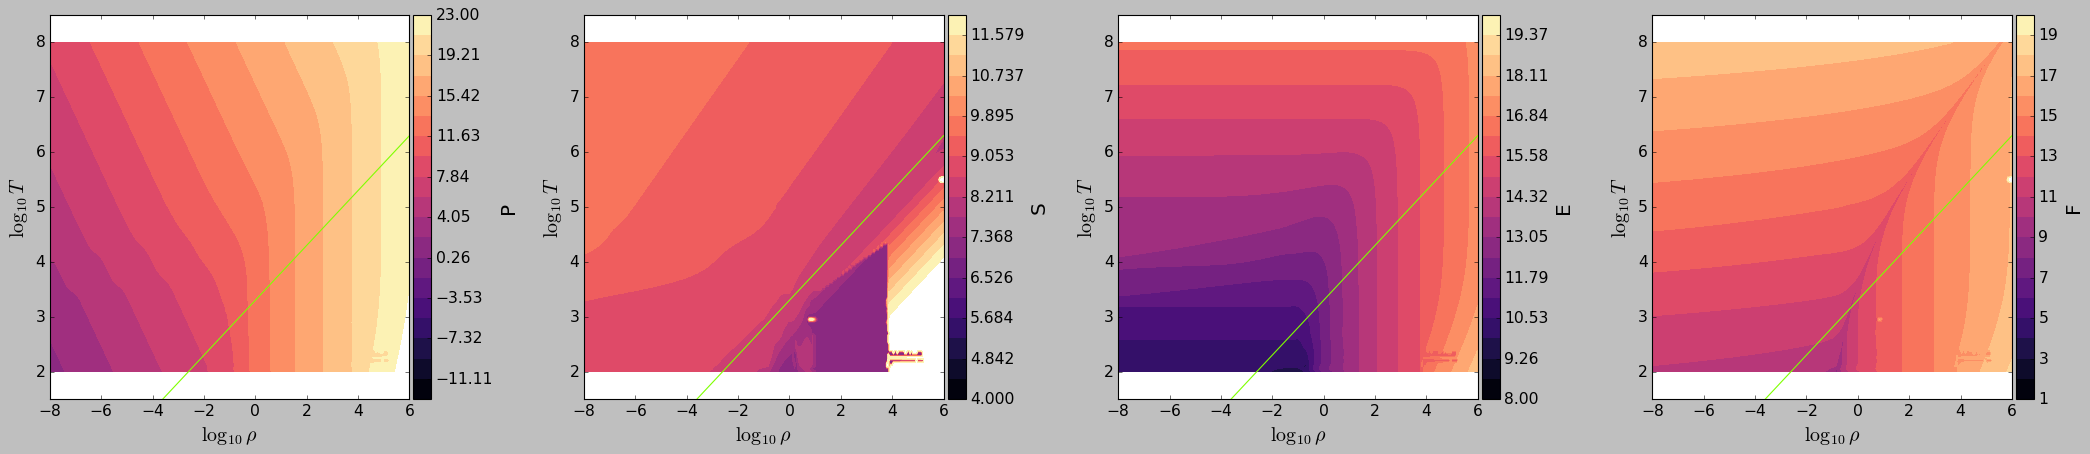

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_10z80x.data
0.8 0.09999999999999998 0.1
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
3.3999863505363463


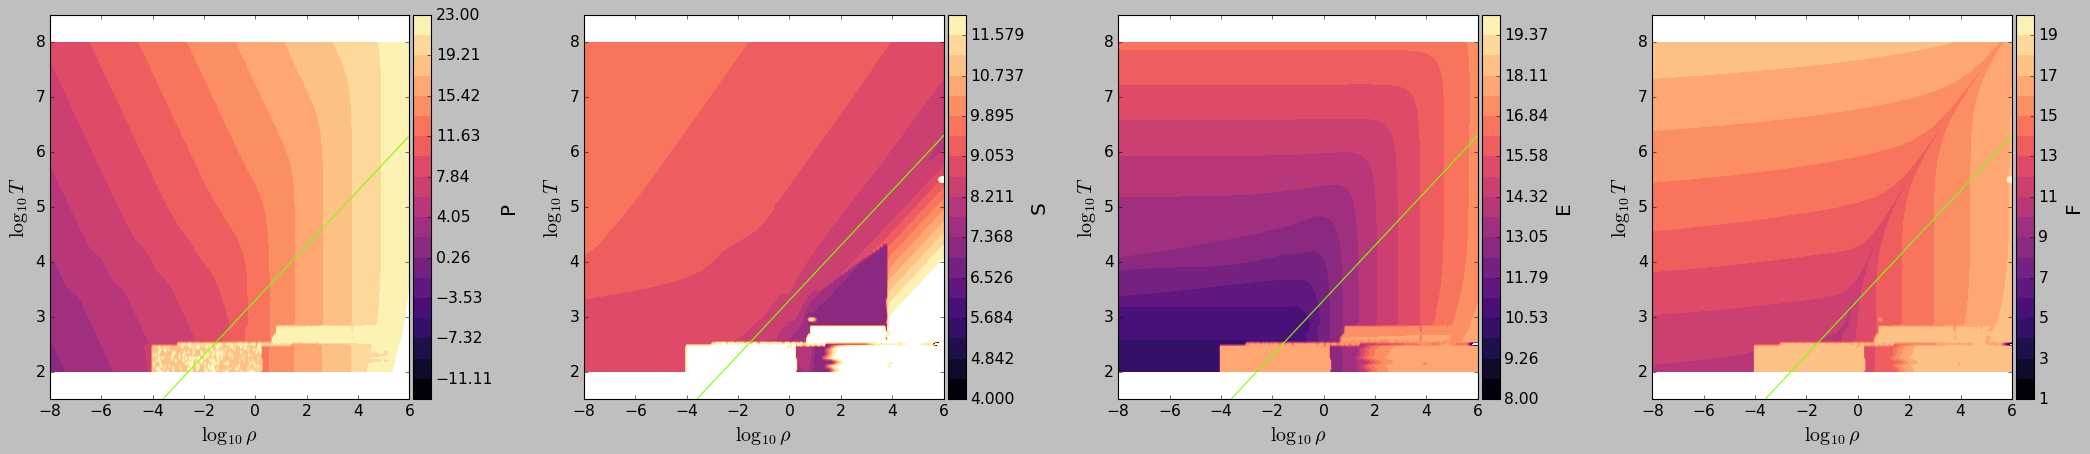

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_20z80x.data
0.8 0.0 0.2
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
5.888672618071238


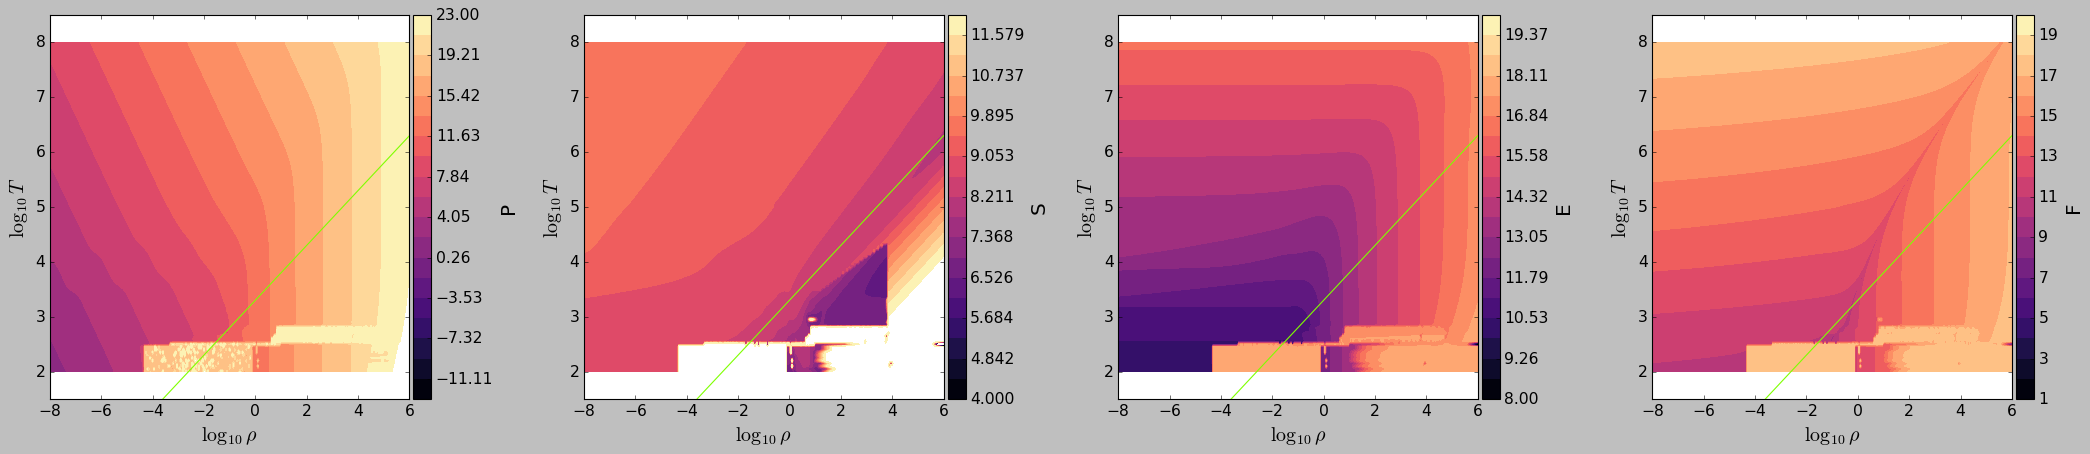

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_00z90x.data
0.9 0.09999999999999998 0.0
2.877691352367401


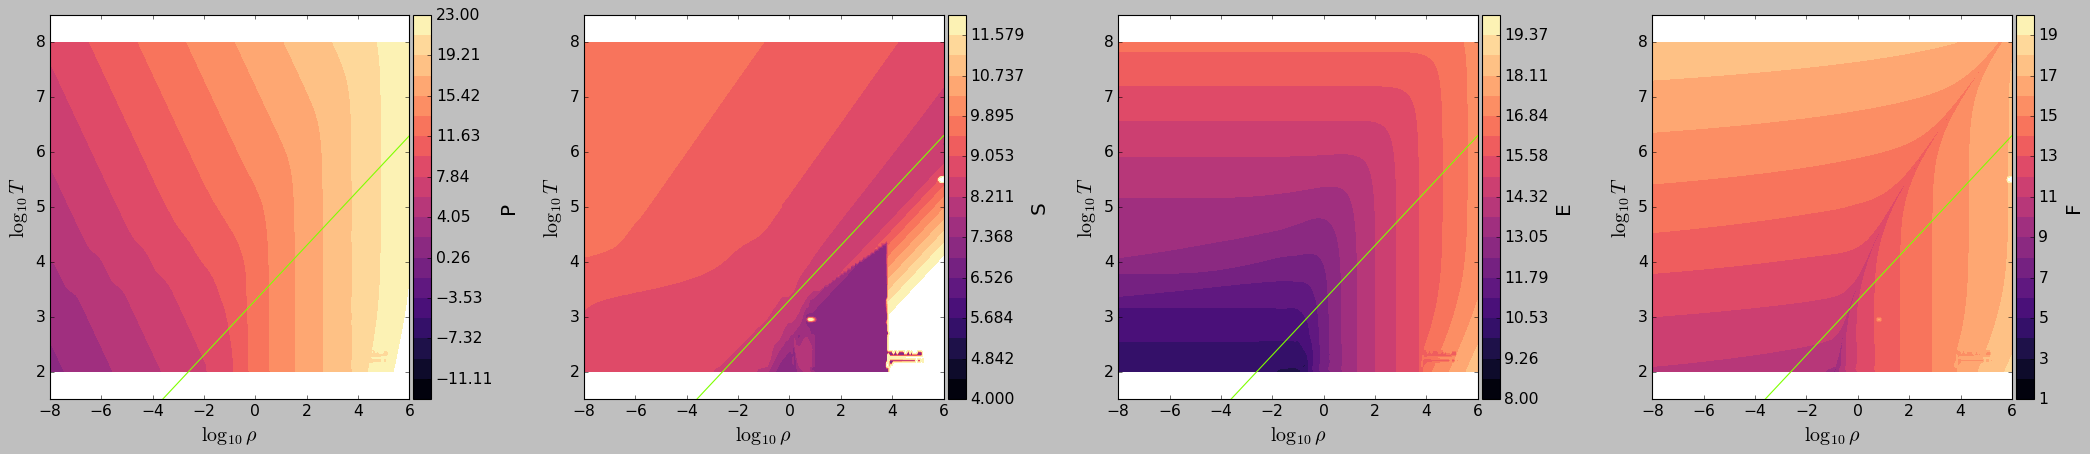

./meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_10z90x.data
0.9 0.0 0.1
[[-13.   -13.   -13.   ... -13.   -13.   -13.  ]
 [-12.95 -12.95 -12.95 ... -12.95 -12.95 -12.95]
 [-12.9  -12.9  -12.9  ... -12.9  -12.9  -12.9 ]
 ...
 [ 22.9   22.9   22.9  ...  22.9   22.9   22.9 ]
 [ 22.95  22.95  22.95 ...  22.95  22.95  22.95]
 [ 23.    23.    23.   ...  23.    23.    23.  ]]
[[ 1.    1.    1.   ...  1.    1.    1.  ]
 [ 1.05  1.05  1.05 ...  1.05  1.05  1.05]
 [ 1.1   1.1   1.1  ...  1.1   1.1   1.1 ]
 ...
 [22.9  22.9  22.9  ... 22.9  22.9  22.9 ]
 [22.95 22.95 22.95 ... 22.95 22.95 22.95]
 [23.   23.   23.   ... 23.   23.   23.  ]]
4.163670349121094


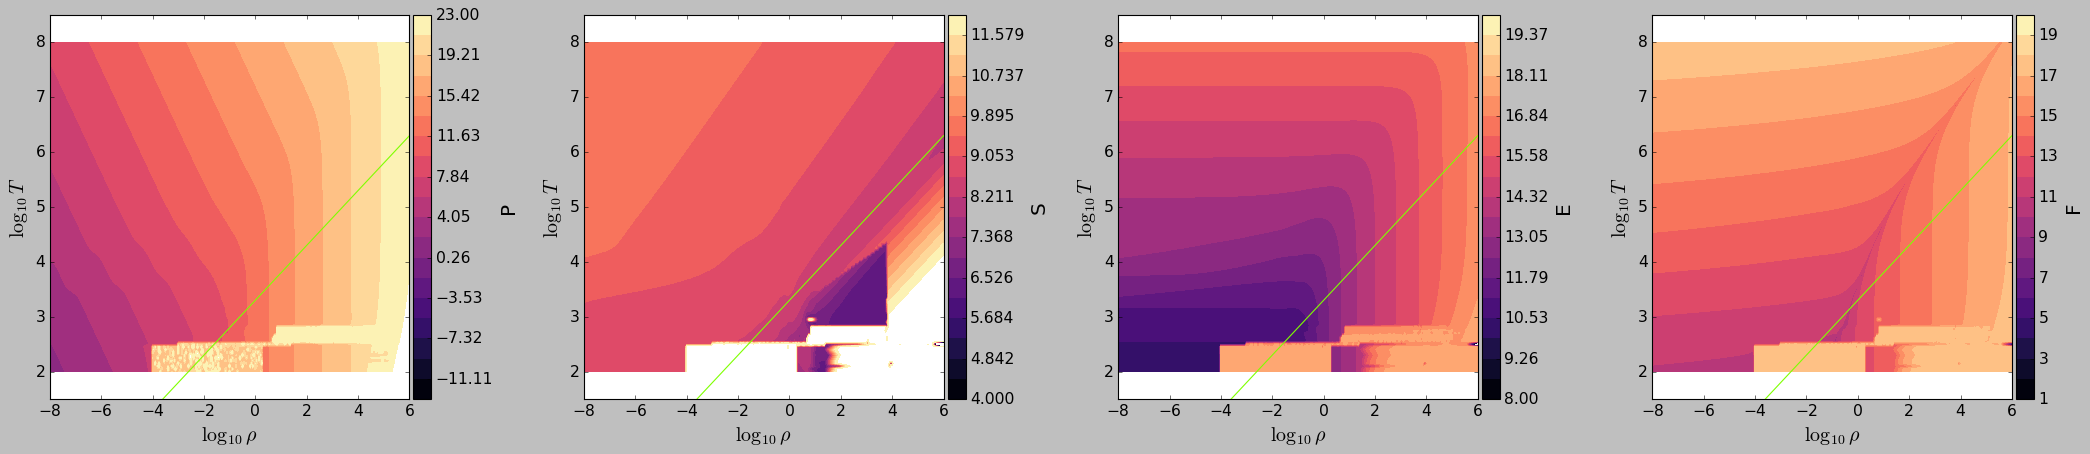

In [25]:
Xarr = np.arange(0.0,1.0,0.1)
Zarr = np.arange(0.0,1.0,0.1)

#Xarr = np.array((0.0, 0.1))
#Zarr = np.array((0.0, 0.1, 1.0))

#Xarr = np.array((0.0,0.01,0.02,0.1,0.2,0.3,0.4,0.5,0.6,0.70,0.71,0.8,0.9))
#Zarr = np.array((0.0,0.01,0.02,0.1,0.2,0.3,0.4,0.5,0.6,0.70,0.71,0.8,0.9))

for i, xi in enumerate(Xarr):
    for k, zi in enumerate(Zarr):

        if (xi + zi) > 1.0:
            continue

        if xi < 1.0:
            xstr = str(xi).split('.')[-1]
            if len(xstr)==1:
                xstr = xstr+'0'
            if len(xstr) > 2:
                xstr = xstr[0:2]
        elif xi == 1.0:
            xstr = '100'

        if zi < 1.0:
            zstr = str(zi).split('.')[-1]
            if len(zstr)==1:
                zstr = zstr+'0'
            if len(zstr) > 2:
                zstr = zstr[0:2]
        elif zi == 1.0:
            zstr = '100'
            
        savefilename = './meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_{0}z{1}x.data'.format(zstr, xstr)
        print(savefilename)

        #if os.path.isfile(savefilename):
        #    print('exists already')
        #    continue

        #else:
        if True:

            yi = 1. - (xi + zi)
    
            print(xi, yi, zi)


            mixed_XYZ = mix_tables(H_PTtable=cd21_H_PT, He_PTtable=cd21_He_PT, Z_PTtable=h2o_PT, X=xi, Y=yi, mu_Z=18.015)
            #print(mixed_XYZ.log10Sgrid)
            mixed_XYZ.log10Sgrid = meos.fill_in_nans(mixed_XYZ.log10Sgrid, mixed_XYZ)
            mixed_XYZ.log10Egrid = meos.fill_in_nans(mixed_XYZ.log10Egrid, mixed_XYZ)

            if zi > 0:
                P_lowlim = -13.
            else:
                P_lowlim = 1.

        
            start = time.time()
            if (xi >= yi) & (xi >= zi):
                mixed_XYZ_rhoT = reinterpolate_mixed_table_to_rhoT(mixed_XYZ,reference_Pgrid=cd21_H.log10Pgrid, P_lowlim=P_lowlim,X=xi, Y=yi)
            elif (yi > xi) & (yi >= zi):
                mixed_XYZ_rhoT = reinterpolate_mixed_table_to_rhoT(mixed_XYZ,reference_Pgrid=cd21_He.log10Pgrid, P_lowlim=P_lowlim,X=xi, Y=yi)
            else:
                mixed_XYZ_rhoT = reinterpolate_mixed_table_to_rhoT(mixed_XYZ,reference_Pgrid=h2o.log10Pgrid,P_lowlim=P_lowlim, X=xi, Y=yi)
            end = time.time()
            print((end-start)/60.)
    
            mixed_XYZ_rhoT.compute_atomic_number()
            mixed_XYZ_rhoT.compute_partials()

            meos.contourf_subplots_with_colorbars(nRow=1, nCol=4, 
                                xs=mixed_XYZ_rhoT.log10rhogrid,
                                ys=mixed_XYZ_rhoT.log10Tgrid,
                                zs=[mixed_XYZ_rhoT.log10Pgrid,mixed_XYZ_rhoT.log10Sgrid,mixed_XYZ_rhoT.log10Egrid,np.log10(np.abs(10**mixed_XYZ_rhoT.log10Egrid - ((10**mixed_XYZ_rhoT.log10Tgrid) * (10**mixed_XYZ_rhoT.log10Sgrid))))],
                                xlims=(-8,6),
                                ylims=(1.5,8.5),
                                zlims=[(-13,23),(4,12),(8,20),(1,20)],
                                levels=20,
                                xlabels=r'$\log_{10}\rho$',
                                ylabels=r'$\log_{10}T$',
                                zlabels=['P','S','E','F'],
                                cmap='magma', vlines=None, hlines=None, otherlines_x=[unphys_x], otherlines_y=[unphys_y], 
                                species='H', plot_interpolation_lines=False, savename=None)
                
        
            MESA_cols_6to16(mixed_XYZ_rhoT, X=Xarr[i],Y=1.-(Xarr[i]+Zarr[k]), mu_Z=18.015)

            mixed_XYZ_rhoT_QT = change_table_coordinates(mixed_XYZ_rhoT,extrapolation_row_idxs=None,extrapolation_col_idxs=None)
               
            write_MESA_table_QT(mixed_XYZ_rhoT_QT, savefilename,version=1, X=xi, Z=zi)
            
        

# CD21 Y = 0.275 table

In [26]:
print(0.275+0.725)

1.0


In [27]:
cd21_Y0275_PT = meos.CMStable("./2021_chabrier+_tables/TABLEEOS_2021_TP_Y0275_v1",units='cgs')

In [28]:
cd21_Y0275_rhoT = reinterpolate_mixed_table_to_rhoT(cd21_Y0275_PT,reference_Pgrid=bln_H.log10Pgrid, P_lowlim=1.,X=0.725, Y=0.275)

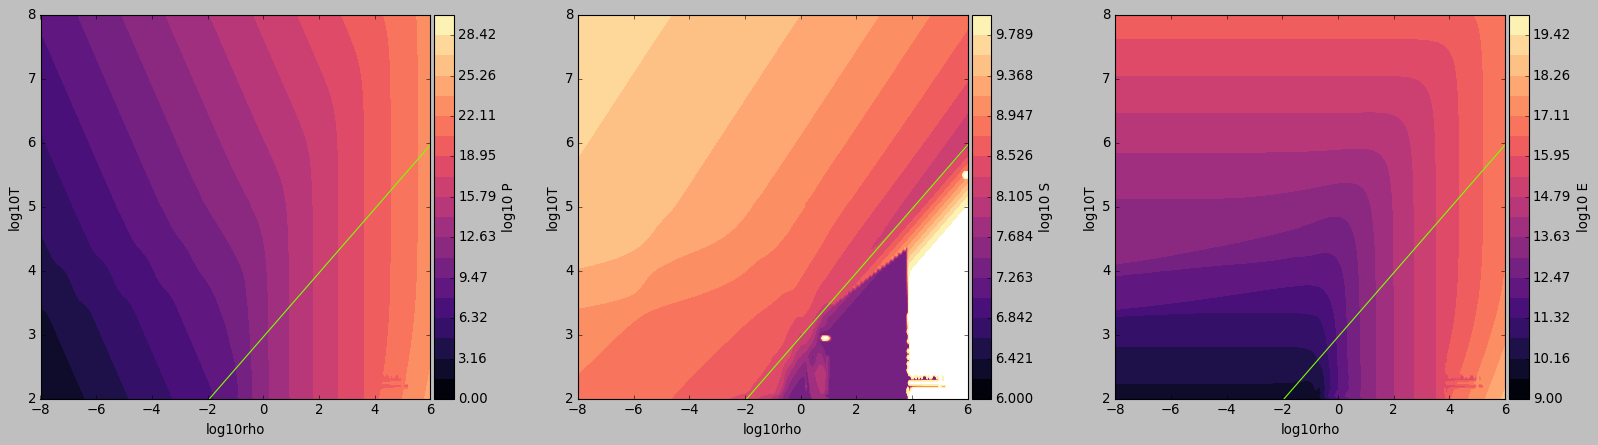

In [29]:
cd21_Y0275_rhoT.compute_atomic_number()

meos.plot_PSE(cd21_Y0275_rhoT,P=10**cd21_Y0275_rhoT.log10Pgrid,S=10**cd21_Y0275_rhoT.log10Sgrid,E=10**cd21_Y0275_rhoT.log10Egrid)


In [30]:
cd21_Y0275_rhoT.compute_partials(species='H')

MESA_cols_6to16(cd21_Y0275_rhoT,X=0.725, Y=0.275,calc_eta=False)

cd21_Y0275_rhoT.log10Qgrid = cd21_Y0275_rhoT.log10rhogrid - 2.*cd21_Y0275_rhoT.log10Tgrid + 12
cd21_Y0275_rhoT = change_table_coordinates(cd21_Y0275_rhoT)

write_MESA_table_QT(cd21_Y0275_rhoT, './meos_MESAformat_CD21+AQUA/mesa-CD21+AQUA_Y0275.data',version=1, X=0.725, Z=0.0)